# Assignment: Predict user conversion based on session data

**Dataset:** Online Shoppers Purchasing Intention Dataset
<br>
**Credits:** Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018)
<br>
**Link to dataset:** https://www.kaggle.com/datasets/henrysue/online-shoppers-intention/data


### Assignment description

An E-commerce company named KokoBananas that sells health and cosmetic products have realised that, in order to stay competitive, they need a better understanding of what constitutes a "good" user experience (UX) on their site. It is assumed that users with a "good" UX converts - so *conversion* is the key metric in this assignment.

Using historical session data, analyse which user behavior leads to conversion. The goal is to create an AI-model, that will, *in real time*, be able to predict whether a user session will convert. The idea is to apply this model on future users in order to quickly determine which user actually become paying customers.

You will present your findings to the company management team. You need to remain object and present both strengths and weaknesses in your predictions. You might even have to report back that it is not possible to use the available data for this prediction. Be mindful of not being too optmistic about your findings - we often fall into the trap of getting swayed by high accuracy - but we always need to criticise this and understand *why* we are getting high accuracy, and if it actually will lead to useful predictions in the future.

The presentation shall be included in the Jupyter Notebook used for analysing the data and training models. The presentation should be understandable for a non-technical person and contain actionable insights. The company management should be helped in making correct decisions based on objective and easy-to-understand results.

### Some initial thoughts on the assignment

- Fun and useful real world application!
- Very open - we are free to use any model we have come across during the course - experimentation nation!
- Will be a good vechile of rehearsing the full course content and applying it throughout.
- It can surely be debated whether conversion is a useful metric for "good" UX. You may have a site that is great at conversion but the users may feel that the UX is awful. "Good" UX can be a very subjective and emotional experience.
- It is a bit vague what the findings will in practice be used for. There is a desire to know in real time which user will convert and at a later stage improve the UX? Will the UX be changed to optimise for conversion? Will Users who are about to drop out of a session without converting be nudged in some way?

### General guidance for the assignment

Remember to keep the code simple and easy to follow. Make use of proper comments, docstrings, typehints etc.
Use markdown cells to, in the simplest terms, motivate your choices.

Since the ambition is to, in real time, be able to identify which users will convert, it is important that the inference time is rapid. So the model we use needs to be quick. Depending on the results of experimenting with models and the data, one outcome might be that it's difficult to get a high performance model that also has good predictions.

This is a binary classification exercise. Use this strategy:
- EDA
- Feature Engineering
- Rehearse all classification models used in the course
- Hypothesize which one/ones might be best
- Try all classification models we have used during the course
- See if your hypothesis held or not with the results
- Compare with the paper written by the authors of the dataset

In [278]:
# packages and methods to import

# Standard data manipulation libraries
import numpy as np
import pandas as pd
from collections import Counter
import time

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Scikit-learn preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn model selection
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate, 
    GridSearchCV
)

# Scikit-learn models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    confusion_matrix, 
    classification_report,
    ConfusionMatrixDisplay
)

# Imbalanced Learn Resampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [279]:
# Read the csv file of session data.
project_data_path =  'project_data.csv'

session_data_df = pd.read_csv(project_data_path)

session_data_df.info()

session_data_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               12330 non-null  int64  
 1   Administrative           12330 non-null  int64  
 2   Administrative_Duration  12330 non-null  float64
 3   Informational            12330 non-null  int64  
 4   Informational_Duration   12330 non-null  float64
 5   ProductRelated           12330 non-null  int64  
 6   ProductRelated_Duration  12330 non-null  float64
 7   BounceRates              12330 non-null  float64
 8   ExitRates                12330 non-null  float64
 9   PageValues               12330 non-null  float64
 10  SpecialDay               12207 non-null  float64
 11  Month                    12330 non-null  object 
 12  OperatingSystems         12330 non-null  int64  
 13  Browser                  12146 non-null  float64
 14  Region                

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,NaN,1.0,1,Returning_Visitor,False,False
1,1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2.0,NaN,2,Returning_Visitor,False,False
2,2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1.0,NaN,3,Returning_Visitor,False,False
3,3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2.0,2.0,4,Returning_Visitor,False,False
4,4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3.0,1.0,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6.0,NaN,1,Returning_Visitor,True,False
12326,12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2.0,1.0,8,Returning_Visitor,True,False
12327,12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2.0,1.0,13,Returning_Visitor,True,False
12328,12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2.0,3.0,11,Returning_Visitor,False,False


A quick glance at the basic info() summary of the dataset and looking at the first and last 5 rows of the dataset tells us:
1. First column: "Unnamed: 0" is an unnecessary extra index column created when we read the csv. This can be dropped immediately
2. A few columns have nans - lets put these in a dict for easy access later.

In [280]:
# Drop the extra index column. Lets use inplace=True since we wont need this column later.
session_data_df.drop('Unnamed: 0', axis=1, inplace=True)

# Use .isna() together with .sum() to find amount of nans in each column
# convert that into a dict with .to_dict()
# use the .items() method so we can loop over the key, value pairs and check where the value is non-zero.
# key value pairs with non-zero values are stored in a columns with nans dict!
columns_with_nans = {key : value for key, value in session_data_df.isna().sum().to_dict().items() if value != 0}

columns_with_nans

{'SpecialDay': 123, 'Browser': 184, 'Region': 246, 'Revenue': 147}

# REUSEABLE ITEMS

Throughout the analysis we need easy access to the descriptions of each feature column, including what the values mean.

We can create a dictionary that contains this information. The descriptions of the features are not that detailed or in some cases, also not clear.

The unit of measurement for time spent within a page category is not given.

Furthermore we can group the feature columns for easier viewing later on. Lets create some lists that will be easy to iterate over.

In [281]:
# Dictionary with all the columns + description of each. The decription in the dict is my interpretation of the source
# documentation which was sparse on column descriptions.
column_descriptions = {
    "Administrative": {
        "description": "Number of page visits within this category",
        "type": "numeric",
        "data_type": "int64"
    },
    "Administrative_Duration": {
        "description": "Time spent within this category",
        "type": "numeric",
        "data_type": "float64"
    },
    "Informational": {
        "description": "Number of page visits within this category",
        "type": "numeric",
        "data_type": "int64"
    },
    "Informational_Duration": {
        "description": "Time spent within this category",
        "type": "numeric",
        "data_type": "float64"
    },
    "ProductRelated": {
        "description": "Number of page visits within this category",
        "type": "numeric",
        "data_type": "int64"
    },
    "ProductRelated_Duration": {
        "description": "Time spent within this category",
        "type": "numeric",
        "data_type": "float64"
    },
    "BounceRates": {
        "description": "Bounce rate of current page",
        "type": "numeric",
        "data_type": "float64"
    },
    "ExitRates": {
        "description": "Exit rate value of current page",
        "type": "numeric",
        "data_type": "float64"
    },
    "PageValues": {
        "description": "Page value of current page",
        "type": "numeric",
        "data_type": "float64"
    },
    "SpecialDay": {
        "description": "Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.",
        "type": "numeric",
        "data_type": "float64"
    },
    "Month": {
        "description": "Month of session",
        "type": "categorical",
        "data_type": "object"
    },
    "Weekend": {
        "description": "Boolean if the session day was in the weekend",
        "type": "categorical",
        "data_type": "object" 
    },
    "OperatingSystems": {
        "description": "Different OS' represented by different integers",
        "type": "categorical",  
        "data_type": "int64"
    },
    "Browser": {
        "description": "Different browsers represented by different integers",
        "type": "categorical",  
        "data_type": "float64" 
    },
    "Region": {
        "description": "Different regions represented by different integers",
        "type": "categorical", 
        "data_type": "float64"  
    },
    "TrafficType": {
        "description": "Different traffic types represented by different integers",
        "type": "categorical",  
        "data_type": "int64"
    },
    "VisitorType": {
        "description": "Different visitor types represented by different categorical values",
        "type": "categorical",
        "data_type": "object"
    },
    "Revenue": {
        "description": "Whether revenue was generated during this session (target variable)",
        "type": "categorical",
        "data_type": "object" 
    }
}

# Lists grouping together columns of similar kind.
column_info_page_views_and_duration_list = ['Administrative', 'Administrative_Duration', 'Informational','Informational_Duration', 'ProductRelated','ProductRelated_Duration']
column_info_google_analytics_list = ['BounceRates','ExitRates','PageValues']
column_info_time_categories_list = ['SpecialDay', 'Month', 'Weekend']
column_info_misc_categories_list = ['OperatingSystems','Browser','Region','TrafficType','VisitorType']

In [282]:
# Code to check that we actually added all columns to our dict
columns_missing_from_description_dict = set(session_data_df.columns) - set(column_descriptions.keys())

print(f"You missed adding these columns to your column description dict: {columns_missing_from_description_dict}.")

You missed adding these columns to your column description dict: set().


In [283]:
# Code to check that we actually added all columns to our dict
columns_missing_from_grouped_columns_list = set(session_data_df.columns) - set(column_info_misc_categories_list) - set(column_info_time_categories_list) - set(column_info_google_analytics_list) - set(column_info_page_views_and_duration_list)

print(f"You missed adding these columns to your grouped column list: {columns_missing_from_grouped_columns_list}. If it's revenue, that's ok since it's our target column.")

You missed adding these columns to your grouped column list: {'Revenue'}. If it's revenue, that's ok since it's our target column.


In [284]:
# Store some initial important values about the dataset that we can use for calculations later

session_df_row_count = len(session_data_df)
print(session_df_row_count)

target_column_before_cleaning = session_data_df['Revenue']

target_true_count_before_cleaning = len(session_data_df.loc[session_data_df['Revenue'] == True])
print(target_true_count_before_cleaning)

target_false_count_before_cleaning = len(session_data_df.loc[session_data_df['Revenue'] == False])
print(target_false_count_before_cleaning)

delimiter_between_prints = '\n\n-----------\n\n'

12330
1880
10303


# FUNCTIONS FOR EDA

In [285]:
# create a function for summarising values in a dataframe

def summarise_df(df: pd.DataFrame,
                column_info_page_views_and_duration_list:list=column_info_page_views_and_duration_list,
                column_info_google_analytics_list:list=column_info_google_analytics_list, 
                column_info_time_categories_list:list=column_info_time_categories_list) -> list:
    
    # Create four empty dicts according the category groups outlined earlier
    # We will in the loops below add summarised values from each column to these dicts.
    column_info_page_views_and_duration_summary = {}
    column_info_google_analytics_summary = {}
    column_info_time_categories_summary = {}
    column_info_misc_categories_summary = {}

    # Iterate over each column in the session DataFrame
    for col in df.columns:

        # The Pandas API types module provides efficient functions for checking datatypes.
        # First lets check if the column contains numerical values.
        if pd.api.types.is_numeric_dtype(df[col]):

            # Next lets check which category grouping it belongs to.
            if col in column_info_page_views_and_duration_list:

                # For numerical regression data we want to know the max, min, mean values and the standard deviation
                column_info_page_views_and_duration_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'max_value' : df[col].max(),
                                    'min_value' : df[col].min(),
                                    'mean_value' : df[col].mean(),
                                    'standard_deviation' : df[col].std()
                                    }
                
            elif col in column_info_google_analytics_list:

                column_info_google_analytics_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'max_value' : df[col].max(),
                                    'min_value' : df[col].min(),
                                    'mean_value' : df[col].mean(),
                                    'standard_deviation' : df[col].std()
                                    }
                
            elif col in column_info_time_categories_list:

                column_info_time_categories_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'max_value' : df[col].max(),
                                    'min_value' : df[col].min(),
                                    'mean_value' : df[col].mean(),
                                    'standard_deviation' : df[col].std()
                                    }
            else:
                # For classification data, numerical or object, we want to know the unique values, their counts (including NaNs!) and top & bottom
                list_of_tuples_of_key_value_pairs_from_value_counts = [(key, int(value)) for key, value in df[col].value_counts(dropna=False).to_dict().items()]
                column_info_misc_categories_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'unique_values' : df[col].unique(),
                                    'value_counts' : list_of_tuples_of_key_value_pairs_from_value_counts,
                                    'top_value' : list_of_tuples_of_key_value_pairs_from_value_counts[0],
                                    'bottom_value' : list_of_tuples_of_key_value_pairs_from_value_counts[-1]
                                    }
        
        else:
            list_of_tuples_of_key_value_pairs_from_value_counts = [(key, int(value)) for key, value in df[col].value_counts(dropna=False).to_dict().items()]
            column_info_misc_categories_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'unique_values' : df[col].unique(),
                                    'value_counts' : list_of_tuples_of_key_value_pairs_from_value_counts,
                                    'top_value' : list_of_tuples_of_key_value_pairs_from_value_counts[0],
                                    'bottom_value' : list_of_tuples_of_key_value_pairs_from_value_counts[-1]
                                    }

    # convert summary dicts into dataframes for better visualisation   
    page_views_and_duration_summary_df = pd.DataFrame(column_info_page_views_and_duration_summary)  
    column_info_google_analytics_summary_df = pd.DataFrame(column_info_google_analytics_summary)
    column_info_time_categories_summary_df = pd.DataFrame(column_info_time_categories_summary)
    column_info_misc_categories_summary_df = pd.DataFrame(column_info_misc_categories_summary)

    summary_dfs_list = [page_views_and_duration_summary_df, column_info_google_analytics_summary_df, column_info_time_categories_summary_df, column_info_misc_categories_summary_df]
    
    # display dataframes with HTML in notebooks using the display method
    for df in summary_dfs_list:

        display(df)
    # display(page_views_and_duration_summary_df)
    # display(column_info_google_analytics_summary_df)
    # display(column_info_time_categories_summary_df)
    # display(column_info_misc_categories_summary_df)

    return summary_dfs_list

In [286]:
# Function for plotting data for the purpose of EDA

def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2, 
                    features_to_plot=None, log_transform=False, plot_type='boxplot'):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(16, 5))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
    n_cols : int, optional (default=2)
        Number of columns in the subplot grid
    features_to_plot : list or None, optional (default=None)
        List of feature names to plot. If None, all features will be plotted.
    log_transform : bool, optional (default=False)
        Whether to apply log transformation to numeric features
    plot_type : str, optional (default='boxplot')
        Type of plot for the right side. Options: 'boxplot', 'scatter', 'strip', 'violin'
        
    Returns:
    --------
    None. Displays plots.
    """
    
    # Validate plot_type
    valid_plot_types = ['boxplot', 'scatter', 'strip', 'violin']
    if plot_type not in valid_plot_types:
        print(f"Warning: Invalid plot_type '{plot_type}'. Using 'boxplot' instead.")
        print(f"Valid options are: {valid_plot_types}")
        plot_type = 'boxplot'
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Pre-compute transformations and statistics for numeric features
    transformed_data = {}
    transform_labels = {}
    feature_stats = {}
    
    for feature in numeric_features:
        min_val = df[feature].min()
        max_val = df[feature].max()
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        
        feature_stats[feature] = {
            'min': min_val,
            'max': max_val,
            'mean': mean_val,
            'median': median_val
        }
        
        if log_transform and min_val > 0:
            transformed_data[feature] = np.log1p(df[feature])
            transform_labels[feature] = "Log-transformed "
            
            # Also compute log-transformed statistics
            feature_stats[feature].update({
                'log_min': np.log1p(min_val),
                'log_max': np.log1p(max_val),
                'log_mean': transformed_data[feature].mean(),
                'log_median': transformed_data[feature].median()
            })
        else:
            transformed_data[feature] = df[feature]
            transform_labels[feature] = ""
    
# Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Use pre-computed transformed data
        plot_data = transformed_data[feature].dropna()
        transform_label = transform_labels[feature]
        
        # Left plot: Simple histogram with mean and median lines
        sns.histplot(plot_data, bins=30, kde=False, ax=axes[0])
        
        # Add mean and median lines [code remains the same]
        
        # Right plot: Based on plot_type
        if transform_label:  # If we applied a log transform
            # Create a temporary dataframe with the log-transformed data
            temp_df = pd.DataFrame({
                feature: transformed_data[feature],
                revenue_col: df[revenue_col]
            })
            
            if plot_type == 'boxplot':
                sns.boxplot(x=revenue_col, y=feature, data=temp_df, ax=axes[1])
            elif plot_type == 'scatter':
                # For scatter plots, jitter the x values slightly for better visibility
                x_jitter = np.random.normal(0, 0.05, size=len(temp_df))
                axes[1].scatter(
                    temp_df[revenue_col].astype(int) + x_jitter, 
                    temp_df[feature], 
                    alpha=0.5
                )
                axes[1].set_xticks([0, 1])
                axes[1].set_xticklabels(['False', 'True'])
            elif plot_type == 'strip':
                sns.stripplot(x=revenue_col, y=feature, data=temp_df, jitter=True, ax=axes[1])
            elif plot_type == 'violin':
                sns.violinplot(x=revenue_col, y=feature, data=temp_df, ax=axes[1])
                
            axes[1].set_ylabel(f'Log({feature}+1)')
        else:
            if plot_type == 'boxplot':
                sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
            elif plot_type == 'scatter':
                # For scatter plots, jitter the x values slightly for better visibility
                x_jitter = np.random.normal(0, 0.05, size=len(df))
                axes[1].scatter(
                    df[revenue_col].astype(int) + x_jitter, 
                    df[feature], 
                    alpha=0.5
                )
                axes[1].set_xticks([0, 1])
                axes[1].set_xticklabels(['False', 'True'])
            elif plot_type == 'strip':
                sns.stripplot(x=revenue_col, y=feature, data=df, jitter=True, ax=axes[1])
            elif plot_type == 'violin':
                sns.violinplot(x=revenue_col, y=feature, data=df, ax=axes[1])
                
            axes[1].set_ylabel(feature)
        
        # Add mean and median annotations based on plot type
        if plot_type in ['boxplot', 'violin']:
            # Add the annotations as before for boxplots and violin plots
            for i, rev_val in enumerate([False, True]):
                # [Annotation code remains the same]
                
                # Add horizontal lines for boxplots and violin plots
                group_data = df[df[revenue_col] == rev_val][feature].dropna()
            
                if len(group_data) > 0:
                    group_mean = group_data.mean()
                    group_median = group_data.median()
                    
                    # Get y-axis limits to position annotations
                    ymin, ymax = axes[1].get_ylim()
                    
                    # Position at the top right of each box
                    box_width = 0.4  # Default box width in seaborn
                    annotation_x = i + box_width/2 + 0.1
                    annotation_y = ymax - (ymax - ymin) * 0.1  # Position near the top
                    
                    # Create a single box with both mean and median
                    annotation_text = f"mean: {group_mean:.2f}\nmedian: {group_median:.2f}"
                    
                    # Add the combined annotation box
                    axes[1].text(
                        annotation_x, annotation_y,
                        annotation_text,
                        ha='left', va='top',
                        bbox=dict(facecolor='white', alpha=0.85, boxstyle='round,pad=0.3', edgecolor='gray'),
                        color='black'
                    )
                    
                    # Add horizontal lines
                    if transform_label:  # If log-transformed
                        plotted_mean = np.log1p(group_mean)
                        plotted_median = np.log1p(group_median)
                    else:
                        plotted_mean = group_mean
                        plotted_median = group_median
                        
                    axes[1].hlines(
                        y=plotted_mean, 
                        xmin=i-box_width/2, 
                        xmax=i+box_width/2,
                        colors='red', 
                        linestyles='dashed', 
                        linewidth=2,
                        zorder=3
                    )
                    
                    axes[1].hlines(
                        y=plotted_median, 
                        xmin=i-box_width/2, 
                        xmax=i+box_width/2,
                        colors='green', 
                        linestyles='dashed', 
                        linewidth=2,
                        zorder=3
                    )
        else:  # For scatter and strip plots
            # Add horizontal lines for the overall mean and median
            for i, rev_val in enumerate([False, True]):
                group_data = df[df[revenue_col] == rev_val][feature].dropna()
                
                if len(group_data) > 0:
                    group_mean = group_data.mean()
                    group_median = group_data.median()
                    
                    if transform_label:  # If log-transformed
                        plotted_mean = np.log1p(group_mean)
                        plotted_median = np.log1p(group_median)
                    else:
                        plotted_mean = group_mean
                        plotted_median = group_median
                    
                    # Add horizontal lines at mean and median
                    axes[1].axhline(y=plotted_mean, xmin=i/2, xmax=(i+1)/2,
                                   color='red', linestyle='--', linewidth=1.5,
                                   label=f'Mean ({rev_val}): {group_mean:.2f}')
                    
                    axes[1].axhline(y=plotted_median, xmin=i/2, xmax=(i+1)/2,
                                   color='green', linestyle='--', linewidth=1.5,
                                   label=f'Median ({rev_val}): {group_median:.2f}')
            
            # Add a legend for scatter and strip plots
            handles, labels = axes[1].get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            axes[1].legend(by_label.values(), by_label.keys(), loc='best')
                
        axes[1].set_title(f'{feature} by {revenue_col}')
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Count plot with all categories
        order = df[feature].value_counts().index
        sns.countplot(y=feature, data=df, order=order, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Right plot: Stacked bar chart by Revenue showing comparison to overall conversion rate
        crosstab = pd.crosstab(df[feature], df[revenue_col], normalize='index')
        
        # Simplified handling - just use the boolean values directly
        # Create the plot with colors
        colors = {True: 'gold', False: 'steelblue'}
        try:
            # Try to put True first if it exists
            if True in crosstab.columns:
                ordered_columns = [True, False]
                ordered_columns = [col for col in ordered_columns if col in crosstab.columns]
                crosstab = crosstab[ordered_columns]
            
            crosstab.plot(kind='barh', stacked=True, ax=axes[1], 
                         color=[colors.get(col, 'gray') for col in crosstab.columns])
        except:
            # Fallback if something goes wrong
            crosstab.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
        
        # Calculate overall proportion of True in the dataset
        overall_true_proportion = df[revenue_col].mean()
        
        # Add a reference line for the overall proportion at 0.85 instead of 0.15
        # This makes it easier to compare with the True portion
        axes[1].axvline(x=0.85, color='red', linestyle='--', linewidth=1.5,
                        label=f'Overall True: {overall_true_proportion:.2f}')
        
        axes[1].legend(loc='lower right')
        axes[1].set_title(f'Conversion Rate by {feature} vs. Overall Rate')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout()
        plt.show()
    
    # Function to show basic stats before plotting
    def plot_feature(feature):
        print(f"\n{'='*40}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Use pre-computed statistics
            stats = feature_stats[feature]
            
            # Print statistics with the requested format
            print("Basic Statistics:")
            print(f" Min      Max        Mean      Median")
            print(f" {stats['min']} {stats['max']} {stats['mean']} {stats['median']}")
            
            # If we have log-transformed stats, print them too
            if 'log_min' in stats:
                print("Log-transformed Statistics (log(x+1)):")
                print(f" Min         Max         Mean        Median")
                print(f" {stats['log_min']:.6f} {stats['log_max']:.6f} {stats['log_mean']:.6f} {stats['log_median']:.6f}")
            
            plot_numeric_feature(feature)
        else:
            # Print only top categories
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each feature
    # If features_to_plot is provided, use only those features, otherwise use all
    if features_to_plot is not None:
        # Validate the features exist in the dataset
        invalid_features = [f for f in features_to_plot if f not in df.columns]
        if invalid_features:
            print(f"Warning: The following features were not found in the dataset: {invalid_features}")
        
        # Filter to only include valid features
        valid_features = [f for f in features_to_plot if f in df.columns and f != revenue_col]
        
        # Further separate into numeric and categorical based on our earlier classification
        plot_numeric = [f for f in valid_features if f in numeric_features]
        plot_categorical = [f for f in valid_features if f in categorical_features]
        
        # Plot them in order
        for feature in plot_numeric + plot_categorical:
            plot_feature(feature)
    else:
        # Plot all features as before
        for feature in numeric_features + categorical_features:
            plot_feature(feature)

In [287]:
def analyze_unusual_value(main_df, column_name, unusual_value):
    """
    Analyzes an unusual value in a specific column and creates visualization comparing conversion rates.
    
    Parameters:
    -----------
    main_df : pandas.DataFrame
        The main DataFrame containing all data
    column_name : str
        Name of the column containing the unusual value
    unusual_value : str or any value
        The unusual value being analyzed
        
    Returns:
    --------
    None. Prints analysis and displays visualization.
    """
    # Print what we're analyzing using the function parameters
    print(f"Analyzing '{unusual_value}' in {column_name} column...")
    
    # Create filtered DataFrame based on parameters
    filtered_df = main_df[main_df[column_name] == unusual_value]
    
    # Count total rows in both dataframes
    unusual_count = len(filtered_df)
    total_count = len(main_df)
    
    # Calculate ratio
    unusual_ratio = unusual_count / total_count
    
    # Count converted rows 
    unusual_converted = (filtered_df['Revenue'] == True).sum()
    total_converted = (main_df['Revenue'] == True).sum()
    
    # Calculate conversion rate within unusual value dataset
    unusual_conversion_rate = unusual_converted / unusual_count if unusual_count > 0 else 0
    
    # Calculate conversion rate in overall dataset
    overall_conversion_rate = total_converted / total_count
    
    # Calculate what portion of all conversions are in the unusual dataset
    converted_ratio = unusual_converted / total_converted if total_converted > 0 else 0
    
    # Print the results
    print(f"\n{unusual_value} in {column_name} Analysis:")
    print(f"Total rows with {unusual_value}: {unusual_count} rows ({unusual_ratio:.2%} of all data)")
    
    print(f"\nConversion Analysis:")
    print(f"Converted rows in {unusual_value} subset: {unusual_converted} ({unusual_conversion_rate:.2%} conversion rate within subset)")
    print(f"Overall conversion rate: {overall_conversion_rate:.2%}")
    print(f"Portion of all conversions: {unusual_converted}/{total_converted} ({converted_ratio:.2%} of all conversions)")
    
    # Create stacked bar chart comparing conversion rates
    labels = ['Overall Dataset', f'{unusual_value} Subset']
    converted = [overall_conversion_rate, unusual_conversion_rate]
    not_converted = [1 - overall_conversion_rate, 1 - unusual_conversion_rate]
    
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.bar(labels, not_converted, width, label='Not Converted')
    ax.bar(labels, converted, width, bottom=not_converted, label='Converted')
    
    ax.set_ylabel('Proportion')
    ax.set_title(f'Conversion Rate Comparison: {unusual_value} in {column_name}')
    ax.legend(loc='upper right')
    
    # Add text annotations with exact percentages
    for i, v in enumerate(converted):
        ax.text(i, not_converted[i] + v/2, f'{v:.1%}', 
                ha='center', va='center', fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()

# Initial EDA - End the data assymetry . . 

In [288]:
# Lets use our summary function to get some insights into each column.
summary_dfs_list = summarise_df(session_data_df)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,27,989493.0,24,2549.375,705,63973.52223
min_value,-10,0.0,0,0.0,0,0.0
mean_value,2.2382,1269.776004,0.503569,34.472398,31.731468,1194.74622
standard_deviation,3.409269,34071.46693,1.270156,140.749294,44.475503,1913.669288


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.098952,0.2,361.763742
min_value,-0.49868,0.0,0.0
mean_value,0.044239,0.043073,5.889258
standard_deviation,0.239735,0.048597,18.568437


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.06126
standard_deviation,0.19865


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Oct, June, Jul, Aug, Nov...","[1, 2, 4, 3, 7, 6, 8, 5]","[nan, 2.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 10.0,...","[1.0, nan, 2.0, 3.0, 4.0, 9.0, 5.0, 6.0, 7.0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, nan, True]"
value_counts,"[(May, 3196), (Nov, 2998), (Mar, 1907), (Dec, ...","[(2, 6601), (1, 2585), (3, 2555), (4, 478), (8...","[(2.0, 7835), (1.0, 2424), (4.0, 725), (5.0, 4...","[(1.0, 4695), (3.0, 2345), (4.0, 1157), (2.0, ...","[(2, 3913), (1, 2451), (3, 2052), (4, 1069), (...","[(Returning_Visitor, 10551), (New_Visitor, 169...","[(False, 9273), (True, 2868), (Name:Zara, 189)]","[(False, 10303), (True, 1880), (nan, 147)]"
top_value,"(May, 3196)","(2, 6601)","(2.0, 7835)","(1.0, 4695)","(2, 3913)","(Returning_Visitor, 10551)","(False, 9273)","(False, 10303)"
bottom_value,"(Sept, 89)","(5, 6)","(9.0, 1)","(nan, 246)","(17, 1)","(Other, 85)","(Name:Zara, 189)","(nan, 147)"


### Page views and duration categories analysis:

Insights:

1. Administrative has negative values - this isn't possible as we're dealing with page views.
2. In all three cases the standard deviation is *higher* than the mean value - this suggests that total time spent in each page type bucket seems to vary a lot across different users, and/or we might have outliers adding noise.

Call to action:
1. Investigate rows with negative values - should these rows be removed or should they be replace with 0? If time spent is 0, page views should be 0?
2. Find outliers in time spent and investigate whether they should be removed.
3. Consider feature engineering -> for each sample, divide duration with pageviews. Perhaps time spent on each page is relevant.

### Google Analytics categories analysis:

Insights:

1. BounceRates has negative values - this isn't possible with a percentage.
2. BounceRates has values over 1 - this isn't possible with a percentage.
3. In all three cases the standard deviation is *higher* than the mean value - this suggests that behaviour seems to vary a lot across different users

Call to action:
1. Investigate rows with negative values - should these rows be remove or should be replace with 0?
2. Investigate rows with values over 1 - should they be removed?
3. Find outliers and investigate whether they should be removed.

### SpecialDay categories analysis:

Insights:

1. The standard deviation is *higher* than the mean value - this suggests that behaviour seems to vary a lot across different users, and/or we might have outliers adding noise.

Call to action:
1. Find outliers and investigate whether they should be removed.

### Misc categories analysis:
Contents of cells in the misc category df become truncated. We need to look into these, lets print all of the values in un-truncated form

In [289]:
# Extract misc df from list of dfs
misc_columns_df = summary_dfs_list[-1]

# Loop over columns in df and print unique values
print('Each column has the following unique values:', end=delimiter_between_prints)
for col in misc_columns_df.columns:

    print(col, misc_columns_df[col].loc['unique_values'])

print(end=delimiter_between_prints)

# Calculate ratio of converted rows to get a sense of how balanced our data is
print(f'Ratio of True values in Revenue column: {round(len(session_data_df[session_data_df["Revenue"] == True])/len(session_data_df), 4)}', end=delimiter_between_prints)

# We could see that we had at least one odd class in our mont column, 'Turc', lets count how many classes we have. We expect 12.
print(f"We have {len(misc_columns_df['Month'].loc['unique_values'])} unique classes in the Month column.")

Each column has the following unique values:

-----------

Month ['Feb' 'Mar' 'May' 'Turc' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Sept'
 'Dec']
OperatingSystems [1 2 4 3 7 6 8 5]
Browser [nan  2.  1.  3.  4.  5.  6.  7. 10.  8.  9. 12. 13. 11.]
Region [ 1. nan  2.  3.  4.  9.  5.  6.  7.  8.]
TrafficType [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]
VisitorType ['Returning_Visitor' 'New_Visitor' 'Other']
Weekend ['False' 'True' 'Name:Zara']
Revenue [False nan True]


-----------

Ratio of True values in Revenue column: 0.1525

-----------

We have 12 unique classes in the Month column.


### Misc categories analysis:

Insights:

1. Month: while containing 12 classes as one might expect, January and April are missing. "Instead" we have "Sep" and "Sept" - are rows with these lables both belonging to September or could one of them actually be January or April but mislabled?
2. Month: Furthermore, we have a class called "Turc", could this be January or April that has been mislabled?
3. Browser: Contains nans
4. Region: Contains nans
5. VisitorType: "Other" is an odd class for visitor type - the documentation gives no clues to what it could be.
6. Weekend: Contains a class called "Name:Zara" which shouldn't appear in a column of boolean values.
7. Revenue: Imbalanced data set: only 15% of rows have True in the revenue column.

Call to action:
1. Month: Investigate Sep, Sept and Turc - are they January and April in disguise or erroneous samples?
2. Browser: Find nans and investigate removal or replacement
3. Region: Find nans and investigate removal or replacement
4. VisitorType: Find other and investigate keeping, removal or replacement
5. Weekend: Find "Name:Zara" and investigate removal or replacement
6. Revenue: Consider who to approach the issue of imbalance.

# We gotta stay positive . . .

Lets look up those negative values! They are very strange. We will start with the negative values in the Administrative column.

In [290]:
# create a mask to filter out negative values in the Administrative column
admin_neg_values_filter = session_data_df['Administrative'] < 0

# apply the filter in our dataframe and save in a new dataframe
admin_neg_values_df = session_data_df[admin_neg_values_filter]

# have a quick glance at our new dataframe using the .info() method
admin_neg_values_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123 entries, 143 to 12133
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           123 non-null    int64  
 1   Administrative_Duration  123 non-null    float64
 2   Informational            123 non-null    int64  
 3   Informational_Duration   123 non-null    float64
 4   ProductRelated           123 non-null    int64  
 5   ProductRelated_Duration  123 non-null    float64
 6   BounceRates              123 non-null    float64
 7   ExitRates                123 non-null    float64
 8   PageValues               123 non-null    float64
 9   SpecialDay               119 non-null    float64
 10  Month                    123 non-null    object 
 11  OperatingSystems         123 non-null    int64  
 12  Browser                  122 non-null    float64
 13  Region                   120 non-null    float64
 14  TrafficType              12

In [291]:
# In the rows with negative admin values, how many rows convert?
print(admin_neg_values_df['Revenue'].value_counts(), end=delimiter_between_prints)

admin_neg_values_df_target_true_count = len(admin_neg_values_df.loc[admin_neg_values_df['Revenue'] == True])
print(f'Ratio converted rows with neg value in admin vs total converted rows: {round(admin_neg_values_df_target_true_count/target_true_count_before_cleaning, 4)}', end=delimiter_between_prints)

admin_neg_values_df_row_count = len(admin_neg_values_df)
print(f'Ratio rows with neg value in admin vs total rows: {round(admin_neg_values_df_row_count/session_df_row_count, 4)}')

Revenue
False    106
True      16
Name: count, dtype: int64

-----------

Ratio converted rows with neg value in admin vs total converted rows: 0.0085

-----------

Ratio rows with neg value in admin vs total rows: 0.01


Insights:

1. 122 rows with negative values in Administrative column. <1% of total amount of rows.
2. Of these, 16 rows are sessions where convertion happened, which is <1% of all converted sessions.

Call to action:
1. If we assume the negative values became negative by accident, and make them positive, will they we representive of other rows?

In [292]:
# Let's look into the summaries of all the negative rows
summarise_df(admin_neg_values_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,-1,1028.833333,9,1779.166667,338,13265.35595
min_value,-10,0.0,0,0.0,1,0.0
mean_value,-5.642276,68.211843,0.536585,63.774797,31.113821,1120.042206
standard_deviation,2.716465,150.812857,1.338538,261.488216,45.460161,1802.345859


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.80952,0.2,120.587914
min_value,-0.38211,0.003226,0.0
mean_value,0.066005,0.047877,4.659112
standard_deviation,0.268121,0.055342,16.330311


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.112605
standard_deviation,0.261208


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, Turc, May, June, Oct, Aug, Jul, Nov...","[2, 1, 3, 8]","[2.0, nan, 1.0, 4.0, 6.0, 5.0, 10.0, 8.0]","[2.0, 1.0, nan, 4.0, 3.0, 7.0, 6.0, 9.0, 5.0, ...","[3, 1, 9, 8, 2, 10, 6, 7, 13, 4, 20, 5, 11]","[Returning_Visitor, New_Visitor]","[False, True, Name:Zara]","[False, True, nan]"
value_counts,"[(May, 34), (Nov, 30), (Mar, 27), (Dec, 13), (...","[(2, 63), (1, 35), (3, 24), (8, 1)]","[(2.0, 75), (1.0, 30), (4.0, 8), (5.0, 4), (8....","[(1.0, 52), (3.0, 22), (2.0, 12), (4.0, 11), (...","[(2, 37), (1, 23), (3, 21), (13, 9), (4, 8), (...","[(Returning_Visitor, 106), (New_Visitor, 17)]","[(False, 103), (True, 19), (Name:Zara, 1)]","[(False, 106), (True, 16), (nan, 1)]"
top_value,"(May, 34)","(2, 63)","(2.0, 75)","(1.0, 52)","(2, 37)","(Returning_Visitor, 106)","(False, 103)","(False, 106)"
bottom_value,"(Sep, 1)","(8, 1)","(10.0, 1)","(8.0, 2)","(5, 1)","(New_Visitor, 17)","(Name:Zara, 1)","(nan, 1)"


When we look at summaries of each column in the negative values dataframe, theres nothing that stands out. There is decent diversity of values in each column. While there are only 4 classes of OperatingSystems in this subset, there isn't just ONE - which would really standout. We need another metric of comparison.

Let's compare the mean value of duration per pageview for the rows where we have non-negative values for administrative with the mean value of duration per pageview for the rows with negative values for administrative.

Finding the mean of the non-negative rows.

In [293]:
# Create df for non-negative rows. We will call these positive for ease. But they include zeros.
admin_pos_values_df = session_data_df[~ admin_neg_values_filter].copy()

# Create a new column that divides duration with page views
admin_pos_values_df.loc[:, 'Duration per page view'] = admin_pos_values_df['Administrative_Duration'] / admin_pos_values_df['Administrative']
# Check if we got any infinities
admin_pos_values_df.loc[admin_pos_values_df['Duration per page view'] == np.inf]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Duration per page view
6434,0,971707.0,0,0.0,9,249.410000,0.022222,0.005128,0.0,0.0,Nov,1,2.0,1.0,4,Returning_Visitor,False,False,inf
8641,0,965480.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Dec,3,2.0,7.0,1,Returning_Visitor,False,False,inf
8979,0,984643.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Nov,1,1.0,1.0,1,Other,False,False,inf
9375,0,985147.0,0,0.0,42,2239.363889,0.020000,0.035455,0.0,0.0,Dec,3,2.0,7.0,2,Returning_Visitor,False,False,inf
9948,0,973917.0,0,0.0,3,0.000000,0.200000,0.200000,0.0,0.0,Nov,2,7.0,2.0,1,Returning_Visitor,False,False,inf


In [294]:
# Lets replace infinities with nan.
admin_pos_values_df.loc[admin_pos_values_df['Duration per page view'] == np.inf, 'Duration per page view'] = None

# Remove rows with Nans resulting from zero division issues. We only want to compare rows with a real ratio.
admin_pos_values_nans_removed_series = admin_pos_values_df['Duration per page view'].dropna()

admin_pos_values_mean = round(admin_pos_values_nans_removed_series.mean(), 4)
print(admin_pos_values_mean)

529.3628


In [295]:
# Save the ids of rows with negative admin values to we can use them later
rows_with_neg_admin_values_ids = admin_neg_values_df.loc[admin_neg_values_df['Administrative'] < 0, 'Administrative'].index

In [296]:
# Multiply all negative values by -1 to make them positive.
admin_neg_values_df.loc[:, 'Administrative'] = admin_neg_values_df['Administrative'] * -1

# Check that it worked - this should result in an empty df
admin_neg_values_df[admin_neg_values_df['Administrative'] < 0]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue


In [297]:
admin_neg_values_df.loc[:, 'Duration per page view'] = admin_neg_values_df['Administrative_Duration'] / admin_neg_values_df['Administrative']

admin_neg_values_mean = round(admin_neg_values_df['Duration per page view'].mean(), 4)

C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_9148\4125605021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  admin_neg_values_df.loc[:, 'Duration per page view'] = admin_neg_values_df['Administrative_Duration'] / admin_neg_values_df['Administrative']


In [298]:
print(f'The ratio of the mean of negative value rows vs positive value rows is: {round(admin_pos_values_mean / admin_neg_values_mean, 4)})')

The ratio of the mean of negative value rows vs positive value rows is: 34.977)


The mean value of the rows with negative values is 35 times smaller than the mean value of the rows with positve values. While this COULD be normal, its a large enough difference for us to want to remove the negative values from the dataset all together. They are small part of data set - its more pragmatic to remove them than replace their values.

In [299]:
session_data_df.drop(index=rows_with_neg_admin_values_ids, inplace=True)

summarise_df(session_data_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,27,989493.0,24,2549.375,705,63973.52223
min_value,0,0.0,0,0.0,0,0.0
mean_value,2.317605,1281.883188,0.503236,34.177142,31.737691,1195.498951
standard_deviation,3.321804,34242.488,1.269502,138.988592,44.46733,1914.812818


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.098952,0.2,361.763742
min_value,-0.49868,0.0,0.0
mean_value,0.04402,0.043024,5.901653
standard_deviation,0.239434,0.048524,18.589792


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.060754
standard_deviation,0.197884


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Oct, June, Jul, Aug, Nov...","[1, 2, 4, 3, 7, 6, 8, 5]","[nan, 2.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 10.0,...","[1.0, nan, 2.0, 3.0, 4.0, 9.0, 5.0, 6.0, 7.0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 9, 13, 14...","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, nan, True]"
value_counts,"[(May, 3162), (Nov, 2968), (Mar, 1880), (Dec, ...","[(2, 6538), (1, 2550), (3, 2531), (4, 478), (8...","[(2.0, 7760), (1.0, 2394), (4.0, 717), (5.0, 4...","[(1.0, 4643), (3.0, 2323), (4.0, 1146), (2.0, ...","[(2, 3876), (1, 2428), (3, 2031), (4, 1061), (...","[(Returning_Visitor, 10445), (New_Visitor, 167...","[(False, 9170), (True, 2849), (Name:Zara, 188)]","[(False, 10197), (True, 1864), (nan, 146)]"
top_value,"(May, 3162)","(2, 6538)","(2.0, 7760)","(1.0, 4643)","(2, 3876)","(Returning_Visitor, 10445)","(False, 9170)","(False, 10197)"
bottom_value,"(Sept, 89)","(5, 6)","(9.0, 1)","(nan, 243)","(17, 1)","(Other, 85)","(Name:Zara, 188)","(nan, 146)"


# I didn't mean to bring you more negative values . . .

Lets deal with the negative values in the *bouncerate* column now.

In [300]:
# create a mask to filter out negative values in the BounceRate column
bouncerate_neg_values_filter = session_data_df['BounceRates'] < 0

# apply the filter in our dataframe and save in a new dataframe
bouncerate_neg_values_df = session_data_df[bouncerate_neg_values_filter]

# have a quick glance at our new dataframe using the .info() method
bouncerate_neg_values_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 362 entries, 15 to 12291
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           362 non-null    int64  
 1   Administrative_Duration  362 non-null    float64
 2   Informational            362 non-null    int64  
 3   Informational_Duration   362 non-null    float64
 4   ProductRelated           362 non-null    int64  
 5   ProductRelated_Duration  362 non-null    float64
 6   BounceRates              362 non-null    float64
 7   ExitRates                362 non-null    float64
 8   PageValues               362 non-null    float64
 9   SpecialDay               361 non-null    float64
 10  Month                    362 non-null    object 
 11  OperatingSystems         362 non-null    int64  
 12  Browser                  359 non-null    float64
 13  Region                   355 non-null    float64
 14  TrafficType              362

In [301]:
# In the rows with negative admin values, how many rows convert?
print(bouncerate_neg_values_df['Revenue'].value_counts(), end=delimiter_between_prints)

bouncerate_neg_values_df_target_true_count = len(bouncerate_neg_values_df.loc[bouncerate_neg_values_df['Revenue'] == True])
print(f'Ratio converted rows with neg value in admin vs total converted rows: {round(bouncerate_neg_values_df_target_true_count/target_true_count_before_cleaning, 4)}', end=delimiter_between_prints)

bouncerate_neg_values_df_row_count = len(bouncerate_neg_values_df)
print(f'Ratio rows with neg value in admin vs total rows: {round(bouncerate_neg_values_df_row_count/session_df_row_count, 4)}')

Revenue
False    304
True      52
Name: count, dtype: int64

-----------

Ratio converted rows with neg value in admin vs total converted rows: 0.0277

-----------

Ratio rows with neg value in admin vs total rows: 0.0294


In [302]:
# Let's look into the summaries of all the negative rows

summarise_df(bouncerate_neg_values_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,19,1427.025,7,1236.2,330,11208.35506
min_value,0,0.0,0,0.0,1,0.0
mean_value,2.256906,79.697607,0.502762,27.129061,29.831492,1197.049939
standard_deviation,3.180231,175.057546,1.107138,111.587652,37.443243,1582.676806


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,-0.100528,0.2,270.784693
min_value,-0.49868,0.0,0.0
mean_value,-0.304287,0.047003,6.422095
standard_deviation,0.117641,0.0538,20.092126


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.05097
standard_deviation,0.18335


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, Turc, May, Oct, Jul, Aug, Sep, June...","[1, 2, 3, 4, 8]","[1.0, 2.0, 5.0, nan, 4.0, 6.0, 3.0, 10.0, 12.0...","[9.0, nan, 4.0, 1.0, 5.0, 2.0, 3.0, 8.0, 6.0, ...","[3, 1, 4, 11, 2, 13, 10, 7, 6, 8, 5, 20]","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, True, nan]"
value_counts,"[(May, 91), (Nov, 88), (Mar, 65), (Dec, 49), (...","[(2, 217), (1, 70), (3, 62), (4, 10), (8, 3)]","[(2.0, 228), (1.0, 66), (4.0, 34), (5.0, 15), ...","[(1.0, 143), (3.0, 60), (4.0, 32), (2.0, 28), ...","[(2, 123), (1, 74), (3, 55), (4, 42), (13, 20)...","[(Returning_Visitor, 315), (New_Visitor, 43), ...","[(False, 270), (True, 85), (Name:Zara, 7)]","[(False, 304), (True, 52), (nan, 6)]"
top_value,"(May, 91)","(2, 217)","(2.0, 228)","(1.0, 143)","(2, 123)","(Returning_Visitor, 315)","(False, 270)","(False, 304)"
bottom_value,"(Sept, 1)","(8, 3)","(12.0, 1)","(nan, 7)","(7, 1)","(Other, 4)","(Name:Zara, 7)","(nan, 6)"


Insights:

1. 362 rows with negative values in BounceRate column. <3% of total amount of rows.
2. Of these, 52 rows are sessions where convertion happened, which is <3% of all converted sessions.

When we look at summaries of each column in the negative values dataframe, theres nothing that stands out. There is decent diversity of values in each column.

Nothing conclusive to be drawn from this. Let's move on for now . . . 

# The higher we bounce the better . . . or?

Lets dig into our other anomaly within bounce rates - values *higher* than one - which is also not possible.

In [303]:
# create a mask to filter out negative values in the BounceRate column
bouncerate_greater_than_one_filter = session_data_df['BounceRates'] > 1

# apply the filter in our dataframe and save in a new dataframe
bouncerate_greater_than_one_df = session_data_df[bouncerate_greater_than_one_filter]

# have a quick glance at our new dataframe using the .info() method
bouncerate_greater_than_one_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 10 to 12287
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           243 non-null    int64  
 1   Administrative_Duration  243 non-null    float64
 2   Informational            243 non-null    int64  
 3   Informational_Duration   243 non-null    float64
 4   ProductRelated           243 non-null    int64  
 5   ProductRelated_Duration  243 non-null    float64
 6   BounceRates              243 non-null    float64
 7   ExitRates                243 non-null    float64
 8   PageValues               243 non-null    float64
 9   SpecialDay               240 non-null    float64
 10  Month                    243 non-null    object 
 11  OperatingSystems         243 non-null    int64  
 12  Browser                  237 non-null    float64
 13  Region                   236 non-null    float64
 14  TrafficType              243

In [304]:
# In the rows with negative admin values, how many rows convert?
print(bouncerate_greater_than_one_df['Revenue'].value_counts(), end=delimiter_between_prints)

bouncerate_greater_than_one_df_target_true_count = len(bouncerate_greater_than_one_df.loc[bouncerate_greater_than_one_df['Revenue'] == True])
print(f'Ratio converted rows with values greater than one vs total converted rows: {round(bouncerate_greater_than_one_df_target_true_count/target_true_count_before_cleaning, 4)}', end=delimiter_between_prints)

bouncerate_greater_than_on_df_row_count = len(bouncerate_greater_than_one_df)
print(f'Ratio rows with values greater than one vs total rows: {round(bouncerate_greater_than_on_df_row_count/session_df_row_count, 4)}')

summarise_df(bouncerate_greater_than_one_df);

Revenue
False    197
True      43
Name: count, dtype: int64

-----------

Ratio converted rows with values greater than one vs total converted rows: 0.0229

-----------

Ratio rows with values greater than one vs total rows: 0.0197


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,22,1951.279141,10,547.75,281,15454.43857
min_value,0,0.0,0,0.0,0,0.0
mean_value,2.855967,90.529426,0.600823,25.304287,35.728395,1340.240094
standard_deviation,3.970948,187.857945,1.494176,80.744109,42.978376,2045.018833


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.098952,0.2,360.953384
min_value,1.203167,0.0,0.0
mean_value,1.616966,0.043211,9.819838
standard_deviation,0.266549,0.052993,33.77989


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.069167
standard_deviation,0.21966


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Jul, Aug, Nov, Oct, Sep,...","[1, 2, 3, 4, 8, 6]","[1.0, 4.0, 2.0, 7.0, 6.0, 5.0, nan, 10.0, 13.0...","[3.0, 1.0, 5.0, 8.0, 4.0, 7.0, 2.0, 9.0, 6.0, ...","[3, 2, 1, 4, 10, 8, 9, 13, 5, 6, 15, 20, 11]","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, True, nan]"
value_counts,"[(Nov, 66), (May, 58), (Mar, 39), (Dec, 33), (...","[(2, 126), (1, 56), (3, 46), (4, 11), (8, 3), ...","[(2.0, 144), (1.0, 53), (4.0, 16), (5.0, 11), ...","[(1.0, 82), (3.0, 51), (4.0, 28), (7.0, 19), (...","[(2, 88), (1, 46), (3, 36), (4, 18), (13, 14),...","[(Returning_Visitor, 206), (New_Visitor, 34), ...","[(False, 184), (True, 55), (Name:Zara, 4)]","[(False, 197), (True, 43), (nan, 3)]"
top_value,"(Nov, 66)","(2, 126)","(2.0, 144)","(1.0, 82)","(2, 88)","(Returning_Visitor, 206)","(False, 184)","(False, 197)"
bottom_value,"(Sept, 3)","(6, 1)","(7.0, 1)","(5.0, 4)","(15, 1)","(Other, 3)","(Name:Zara, 4)","(nan, 3)"


Insights:

1. 243 rows with values higher than one in BounceRate column. <2% of total amount of rows.
2. Of these, 52 rows are sessions where convertion happened, which is just over 2% of all converted sessions.

When we look at summaries of each column in the negative values dataframe, theres nothing that stands out. There is decent diversity of values in each column.

Nothing conclusive to be drawn from this.

We need a new approach, lets look at negative values *and* values higher than one, togeher, grouped as *invalid values*.

In order to be able to make a decision about these rows, we need a more complete picture, as the percentages are now getting bigger, especially considering that our dataset is unbalanced.

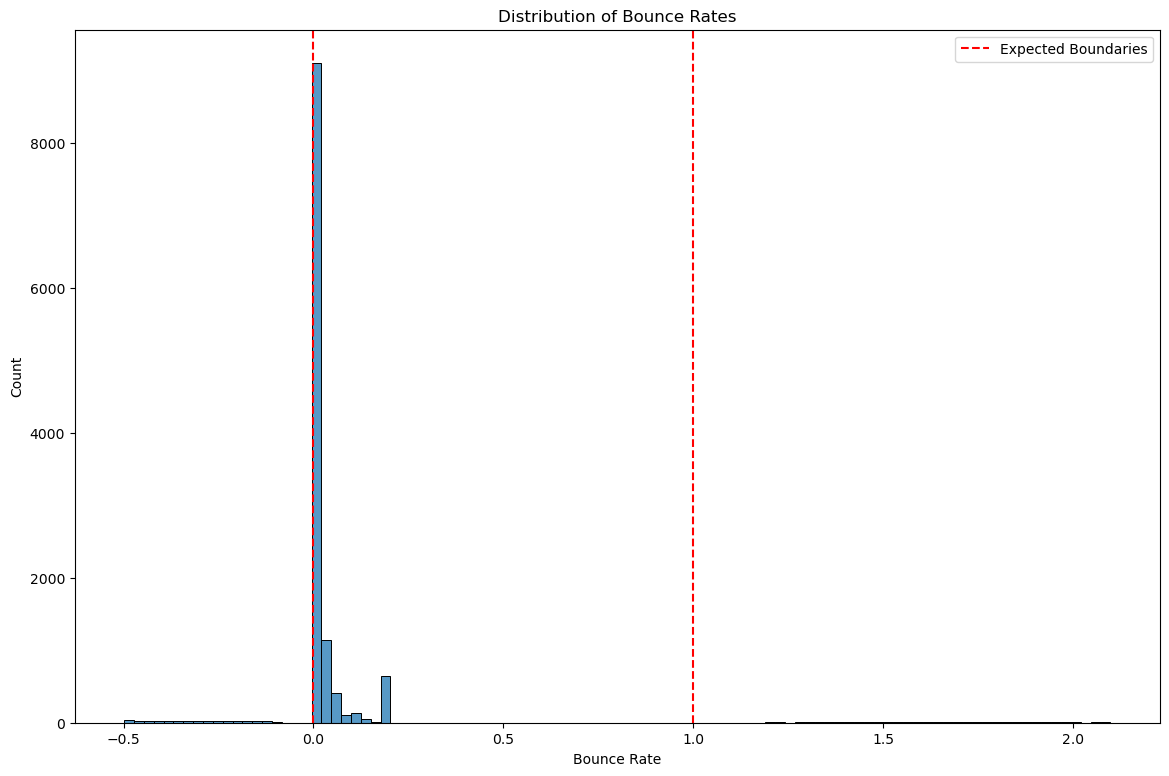

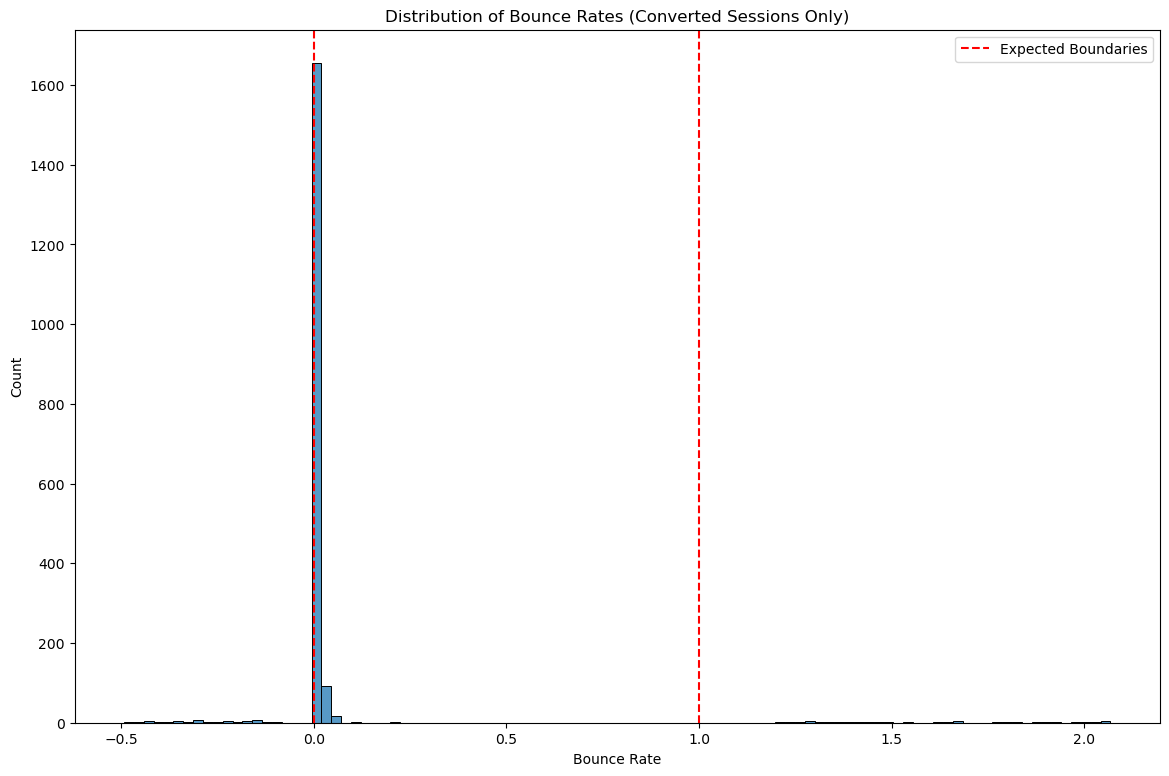


Bounce Rates Distribution:
Valid range (0-1): 11602 rows (95.04%)
Invalid range (<0, >1): 605 rows (4.96%)
Negative values: 362 rows (2.97%)
Values above 1: 243 rows (1.99%)

Bounce Rates Distribution among Converted Sessions:
Valid range (0-1): 1769 converted rows (94.90%)
Invalid range (<0, >1): 95 converted rows (5.10%)
Negative values: 52 converted rows (2.79%)
Values above 1: 43 converted rows (2.31%)

Conversion rates by bounce rate group:
Valid range (0-1): 15.43%
Invalid range (<0, >1): 15.94%
Negative values: 14.61%
Values above 1: 17.92%


In [305]:
# Plot basic histogram
plt.figure(figsize=(14, 9))
sns.histplot(session_data_df['BounceRates'], bins=100)
plt.title('Distribution of Bounce Rates')
plt.xlabel('Bounce Rate')
plt.axvline(x=0, color='r', linestyle='--', label='Expected Boundaries')
plt.axvline(x=1, color='r', linestyle='--')
plt.legend()
plt.show()

# Plot histogram for converted sessions only
plt.figure(figsize=(14, 9))
converted_filter = session_data_df['Revenue'] == True
sns.histplot(session_data_df.loc[converted_filter, 'BounceRates'], bins=100)
plt.title('Distribution of Bounce Rates (Converted Sessions Only)')
plt.xlabel('Bounce Rate')
plt.axvline(x=0, color='r', linestyle='--', label='Expected Boundaries')
plt.axvline(x=1, color='r', linestyle='--')
plt.legend()
plt.show()

# Count values in different ranges
valid_filter = (session_data_df['BounceRates'] >= 0) & (session_data_df['BounceRates'] <= 1)
negative_filter = session_data_df['BounceRates'] < 0
above_one_filter = session_data_df['BounceRates'] > 1
# count rows in each grouping
valid_count = valid_filter.sum()
negative_count = negative_filter.sum()
above_one_count = above_one_filter.sum()
invalid_count = negative_count + above_one_count
total_count = len(session_data_df['BounceRates'])
#  count converted rows in each grouping
valid_converted = (session_data_df.loc[valid_filter, 'Revenue'] == True).sum()
negative_converted = (session_data_df.loc[negative_filter, 'Revenue'] == True).sum()
above_one_converted = (session_data_df.loc[above_one_filter, 'Revenue'] == True).sum()
invalid_converted = negative_converted + above_one_converted
total_converted = (session_data_df['Revenue'] == True).sum()
# Print counts and ratios per row overall
print("\nBounce Rates Distribution:")
print(f"Valid range (0-1): {valid_count} rows ({valid_count/total_count:.2%})")
print(f"Invalid range (<0, >1): {invalid_count} rows ({invalid_count/total_count:.2%})")
print(f"Negative values: {negative_count} rows ({negative_count/total_count:.2%})")  
print(f"Values above 1: {above_one_count} rows ({above_one_count/total_count:.2%})")
# Print counts and ratios per converted rows
print("\nBounce Rates Distribution among Converted Sessions:")
print(f"Valid range (0-1): {valid_converted} converted rows ({valid_converted/total_converted:.2%})")
print(f"Invalid range (<0, >1): {invalid_converted} converted rows ({invalid_converted/total_converted:.2%})")
print(f"Negative values: {negative_converted} converted rows ({negative_converted/total_converted:.2%})")
print(f"Values above 1: {above_one_converted} converted rows ({above_one_converted/total_converted:.2%})")
# Look at conversion rates for each group
if 'Revenue' in session_data_df.columns:
    valid_conversion = session_data_df.loc[valid_filter, 'Revenue'].mean()
    invalid_conversion = session_data_df.loc[~valid_filter, 'Revenue'].mean() if invalid_count > 0 else np.nan
    negative_conversion = session_data_df.loc[negative_filter, 'Revenue'].mean() if negative_count > 0 else np.nan
    above_one_conversion = session_data_df.loc[above_one_filter, 'Revenue'].mean() if above_one_count > 0 else np.nan
   
    print("\nConversion rates by bounce rate group:")
    print(f"Valid range (0-1): {valid_conversion:.2%}")
    print(f"Invalid range (<0, >1): {invalid_conversion:.2%}")
    print(f"Negative values: {negative_conversion:.2%}")
    print(f"Values above 1: {above_one_conversion:.2%}")

### Invalid bounce rates final analysis:

Insights:

1. While a very large majority of rows fall within the valid range for bounce rates, a significant portion falls outside of the range. The fact that we have a unbalanced dataset makes this even more problematic.
2. A whooping 5% of converted rows fall in the invalid bounce rate range. If we were to remove these, we would loose a lot of rows that would help train our models to predict when users convert.

Call-to-action:
1. Do not remove these because of invalid bounce rates.
2. Let's instead do some feature engineering and create a feature, 'Bounce Rate type', which categorises classes into three classes: 'Valid', 'Negative', 'Greater than one'. Even if the bounce rates are invalid, they might provide insights that can help the model predict better. Lets also save these in a seperate dataframe so we can compare.

**But** before we do this feature engineering, lets do more EDA, there might be more rows we want to drop, and we want to do that before creating different dataframes to avoid human error later on.

# From hero to zero . . .

During the analysis of the negative values I noticed that we have rows where **Page views > 0 *and* duration = 0**.

While it intuitively feels like the page views with 0 duration are errors, it could be that there are technical quirks that cause this to happen. And that these are legitimate samples.

It quite hard to make judgemnt calls without a domain expert or the people who gave us the data. However my research on the topic suggests that these could be legit user sessions where:
- The user entered a page without interacting with it and then bounced. This generates a zero value for duration in Google analytics
- The website analytics isn't configured in a way that captures those visits correctly

Lets checkout those zero duration sessions further, by category:

In [306]:
admin_duration_zero_filter = session_data_df['Administrative_Duration'] == 0
info_duration_zero_filter = session_data_df['Informational_Duration'] == 0
product_duration_zero_filter = session_data_df['ProductRelated_Duration'] == 0

admin_duration_zero_df = session_data_df[admin_duration_zero_filter]
info_duration_zero_df = session_data_df[info_duration_zero_filter]
product_duration_zero_df = session_data_df[product_duration_zero_filter]

In [307]:
summarise_df(admin_duration_zero_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,2,0.0,16,1830.5,423,17086.23424
min_value,0,0.0,0,0.0,0,0.0
mean_value,0.023826,0.0,0.157182,9.718231,18.079534,678.120513
standard_deviation,0.156951,0.0,0.655832,74.167666,24.840707,1052.797722


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.088658,0.2,360.953384
min_value,-0.498331,0.0,0.0
mean_value,0.055233,0.065138,3.442421
standard_deviation,0.233136,0.06039,16.201453


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.085299
standard_deviation,0.230488


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Oct, June, Aug, Jul, Nov...","[1, 2, 4, 3, 7, 6, 8, 5]","[nan, 2.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 10.0,...","[1.0, nan, 2.0, 3.0, 4.0, 5.0, 9.0, 6.0, 7.0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 10, 9, 13, 14...","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, nan, True]"
value_counts,"[(May, 1683), (Nov, 1371), (Mar, 984), (Dec, 8...","[(2, 3074), (1, 1233), (3, 1220), (4, 243), (8...","[(2.0, 3575), (1.0, 1190), (4.0, 383), (5.0, 2...","[(1.0, 2259), (3.0, 1087), (4.0, 540), (2.0, 5...","[(2, 1434), (1, 1372), (3, 1184), (4, 464), (1...","[(Returning_Visitor, 5277), (New_Visitor, 506)...","[(False, 4487), (True, 1261), (Name:Zara, 86)]","[(False, 5231), (True, 537), (nan, 66)]"
top_value,"(May, 1683)","(2, 3074)","(2.0, 3575)","(1.0, 2259)","(2, 1434)","(Returning_Visitor, 5277)","(False, 4487)","(False, 5231)"
bottom_value,"(Sept, 18)","(7, 3)","(11.0, 4)","(nan, 122)","(17, 1)","(Other, 51)","(Name:Zara, 86)","(nan, 66)"


In [308]:
admin_duration_zero_df['Administrative'].value_counts()

Administrative
0    5699
1     131
2       4
Name: count, dtype: int64

### Administrative_Duration = 0 Analysis

Insights:

1. Most zero duration rows also have 0 page views. This makes intuitive sense and is fine.
2. About 130 rows have 1 page view - which could be explained by the fact that a user maybe have entered a page, not interacting in it and then bounced which would result in a zero in duration
3. A very small number (4) of rows have *2* page views, but still with 0 duration. This seems intuitively odd but could be down to some technical reason that I am not aware of. Given the small amount I did not research it extensively at this time.

Call to action:

Nothing. Keep rows as is.

In [309]:
summarise_df(info_duration_zero_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,23,985308.0,2,0.0,534,18504.12621
min_value,0,0.0,0,0.0,0,0.0
mean_value,1.714722,1250.154733,0.023705,0.0,24.247736,882.509164
standard_deviation,2.688329,34089.131176,0.158042,0.0,32.214691,1261.152802


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.098952,0.2,361.763742
min_value,-0.49868,0.0,0.0
mean_value,0.046113,0.047944,5.323137
standard_deviation,0.235497,0.052325,18.515752


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.065537
standard_deviation,0.204578


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Oct, June, Jul, Aug, Nov...","[1, 2, 4, 3, 7, 6, 5, 8]","[nan, 2.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 10.0,...","[1.0, nan, 2.0, 3.0, 4.0, 9.0, 5.0, 6.0, 7.0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 9, 13, 14...","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, nan, True]"
value_counts,"[(May, 2590), (Nov, 2271), (Mar, 1572), (Dec, ...","[(2, 5231), (1, 2078), (3, 2023), (4, 402), (8...","[(2.0, 6144), (1.0, 1961), (4.0, 604), (5.0, 3...","[(1.0, 3703), (3.0, 1873), (4.0, 915), (2.0, 9...","[(2, 2852), (1, 2057), (3, 1777), (4, 835), (1...","[(Returning_Visitor, 8323), (New_Visitor, 1427...","[(False, 7495), (True, 2195), (Name:Zara, 139)]","[(False, 8400), (True, 1314), (nan, 115)]"
top_value,"(May, 2590)","(2, 5231)","(2.0, 6144)","(1.0, 3703)","(2, 2852)","(Returning_Visitor, 8323)","(False, 7495)","(False, 8400)"
bottom_value,"(Sept, 72)","(5, 5)","(9.0, 1)","(nan, 187)","(17, 1)","(Other, 79)","(Name:Zara, 139)","(nan, 115)"


In [310]:
info_duration_zero_df['Informational'].value_counts()

Informational
0    9605
1     215
2       9
Name: count, dtype: int64

### Informational_Duration = 0 Analysis

Insights:

1. Most zero duration rows also have 0 page views. This makes intuitive sense and is fine.
2. 211 rows have 1 page view - which could be explained by the fact that a user maybe have entered a page, not interacting in it and then bounced which would result in a zero in duration
3. A very small number (9) of rows have *2* page views, but still with 0 duration. This seems intuitively odd but could be down to some technical reason that I am not aware of. Given the small amount I did not research it extensively at this time.

Call to action:

Nothing. Keep rows as is.

In [311]:
summarise_df(product_duration_zero_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,4,984643.0,3,56.0,13,0.0
min_value,0,0.0,0,0.0,0,0.0
mean_value,0.079301,3932.909207,0.028226,0.266465,1.342742,0.0
standard_deviation,0.360053,61810.724499,0.227359,3.203975,1.123349,0.0


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.057441,0.2,0.0
min_value,-0.490189,0.022222,0.0
mean_value,0.208683,0.193325,0.0
standard_deviation,0.269554,0.028118,0.0


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.063772
standard_deviation,0.196998


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Jul, Oct, Nov, Sep, June...","[1, 4, 2, 3, 6, 8, 7]","[nan, 1.0, 4.0, 2.0, 3.0, 6.0, 5.0, 8.0, 10.0,...","[1.0, nan, 3.0, 4.0, 5.0, 2.0, 7.0, 8.0, 6.0, ...","[1, 3, 5, 2, 4, 11, 10, 8, 9, 6, 13, 15, 18, 1...","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, nan, True]"
value_counts,"[(May, 210), (Nov, 160), (Mar, 136), (Dec, 106...","[(2, 297), (1, 216), (3, 196), (4, 17), (8, 14...","[(2.0, 417), (1.0, 197), (4.0, 38), (5.0, 22),...","[(1.0, 281), (3.0, 135), (2.0, 67), (4.0, 66),...","[(1, 235), (3, 190), (13, 84), (2, 68), (4, 37...","[(Returning_Visitor, 685), (New_Visitor, 42), ...","[(False, 599), (True, 135), (Name:Zara, 10)]","[(False, 725), (True, 13), (nan, 6)]"
top_value,"(May, 210)","(2, 297)","(2.0, 417)","(1.0, 281)","(1, 235)","(Returning_Visitor, 685)","(False, 599)","(False, 725)"
bottom_value,"(Sept, 2)","(7, 1)","(7.0, 4)","(5.0, 19)","(19, 1)","(Other, 17)","(Name:Zara, 10)","(nan, 6)"


In [312]:
product_duration_zero_df['ProductRelated'].value_counts()

ProductRelated
1     545
2     101
0      38
3      34
4      11
5       7
9       2
6       2
13      1
10      1
11      1
7       1
Name: count, dtype: int64

### ProductRelated_Duration = 0 Analysis

Insights:

This is a more complicated picture: While the majority of zero duration session in this category is 0 or 1 sessions - there are over 100 sessions with 2 or more page views with zero duration. This is harder to understand intuitively. However since the number is still quite low, and this could be easily explainable behaviour for a domain expert, I will leave it in for now.

I will just make a quick summary of all columns for this particular subset and see if I can, at a glance, see anything that sticks out.

In [313]:
product_duration_zero_product_above_one_df = product_duration_zero_df[product_duration_zero_df['ProductRelated'] > 1]

summarise_df(product_duration_zero_product_above_one_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,2,973917.0,1,0.0,13,0.0
min_value,0,0.0,0,0.0,2,0.0
mean_value,0.037267,6049.824845,0.006211,0.0,2.819876,0.0
standard_deviation,0.247189,76755.360798,0.078811,0.0,1.684073,0.0


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.979375,0.2,0.0
min_value,-0.448298,0.1,0.0
mean_value,0.207873,0.196736,0.0
standard_deviation,0.265306,0.015445,0.0


,SpecialDay
data_type,float64
max_value,0.8
min_value,0.0
mean_value,0.1
standard_deviation,0.235257


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, June, Jul, Sep, Aug, Nov...","[3, 2, 1]","[3.0, 2.0, 1.0, 5.0, 8.0, 4.0, nan, 6.0, 10.0,...","[1.0, 3.0, 6.0, 2.0, 4.0, 8.0, 7.0, 5.0, 9.0, ...","[3, 1, 10, 13, 6, 4, 11, 5, 2, 20, 15, 8]","[Returning_Visitor, New_Visitor]","[False, True, Name:Zara]","[False, True]"
value_counts,"[(May, 51), (Nov, 39), (Mar, 25), (Dec, 11), (...","[(3, 58), (2, 55), (1, 48)]","[(2.0, 104), (1.0, 36), (8.0, 6), (5.0, 4), (n...","[(1.0, 59), (3.0, 27), (2.0, 21), (6.0, 16), (...","[(1, 54), (3, 41), (13, 36), (4, 8), (6, 7), (...","[(Returning_Visitor, 157), (New_Visitor, 4)]","[(False, 134), (True, 25), (Name:Zara, 2)]","[(False, 160), (True, 1)]"
top_value,"(May, 51)","(3, 58)","(2.0, 104)","(1.0, 59)","(1, 54)","(Returning_Visitor, 157)","(False, 134)","(False, 160)"
bottom_value,"(Sep, 1)","(1, 48)","(10.0, 1)","(nan, 4)","(8, 1)","(New_Visitor, 4)","(Name:Zara, 2)","(True, 1)"


In [314]:
product_duration_zero_product_one_and_zero_df = product_duration_zero_df[product_duration_zero_df['ProductRelated'] <= 1]

summarise_df(product_duration_zero_product_one_and_zero_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,4,984643.0,3,56.0,1,0.0
min_value,0,0.0,0,0.0,0,0.0
mean_value,0.090909,3348.306432,0.034305,0.340051,0.93482,0.0
standard_deviation,0.38481,57063.566791,0.253206,3.616649,0.247055,0.0


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.057441,0.2,0.0
min_value,-0.490189,0.022222,0.0
mean_value,0.208907,0.192384,0.0
standard_deviation,0.27094,0.030654,0.0


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.053726
standard_deviation,0.183969


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Jul, Oct, Nov, Sep, Aug,...","[1, 4, 2, 3, 6, 8, 7]","[nan, 1.0, 4.0, 2.0, 6.0, 3.0, 5.0, 8.0, 10.0,...","[1.0, nan, 3.0, 4.0, 5.0, 2.0, 7.0, 8.0, 9.0, ...","[1, 3, 5, 2, 4, 11, 10, 8, 9, 6, 13, 15, 18, 1...","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, nan, True]"
value_counts,"[(May, 159), (Nov, 121), (Mar, 111), (Dec, 95)...","[(2, 242), (1, 168), (3, 138), (4, 17), (8, 14...","[(2.0, 313), (1.0, 161), (4.0, 36), (5.0, 18),...","[(1.0, 222), (3.0, 108), (4.0, 52), (2.0, 46),...","[(1, 181), (3, 149), (2, 66), (13, 48), (4, 29...","[(Returning_Visitor, 528), (New_Visitor, 38), ...","[(False, 465), (True, 110), (Name:Zara, 8)]","[(False, 565), (True, 12), (nan, 6)]"
top_value,"(May, 159)","(2, 242)","(2.0, 313)","(1.0, 222)","(1, 181)","(Returning_Visitor, 528)","(False, 465)","(False, 565)"
bottom_value,"(Sept, 2)","(7, 1)","(7.0, 2)","(5.0, 15)","(19, 1)","(Other, 17)","(Name:Zara, 8)","(nan, 6)"


### ProductRelated_Duration = 0 Final Analysis

Nothing sticks out. Lets keep the rows and keep going. It is again quite a small amount of rows, and there could be technical reason that are beyond my expertise. I need to check this with a domain expert.

# Far, far way in the land of Outlierandia

Lets do some plots to see if we can get a clear view of which features have outliers we need to do deal with


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0 27 2.317604653067912 1.0


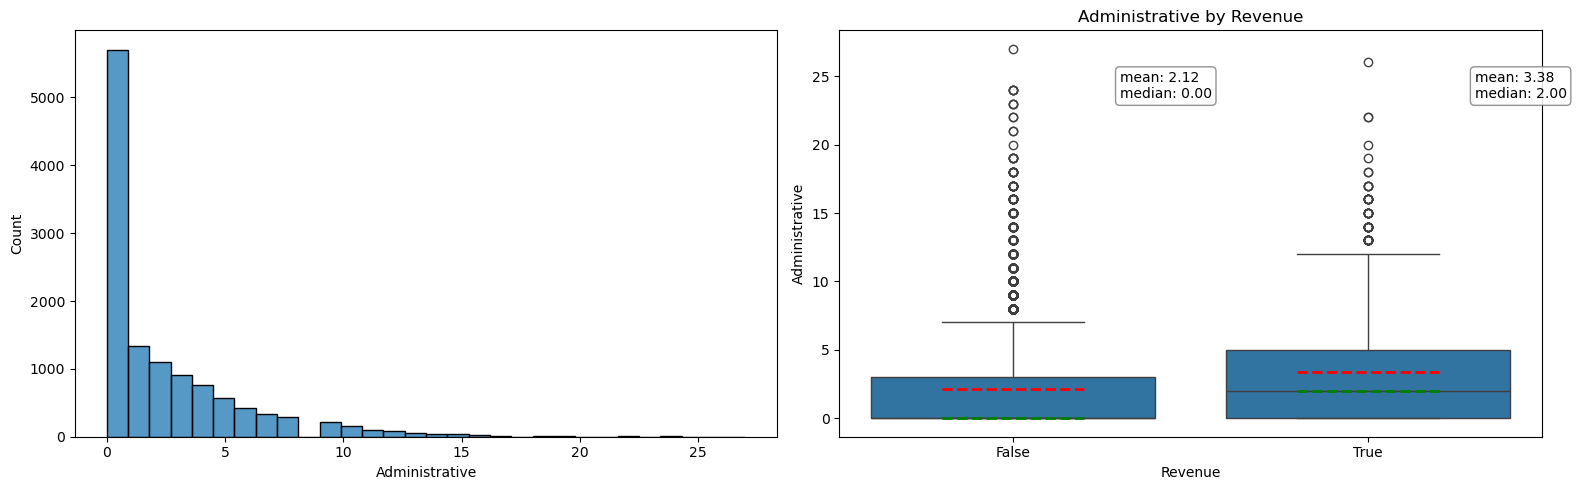


Feature: Administrative_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0.0 989493.0 1281.8831878956378 8.0


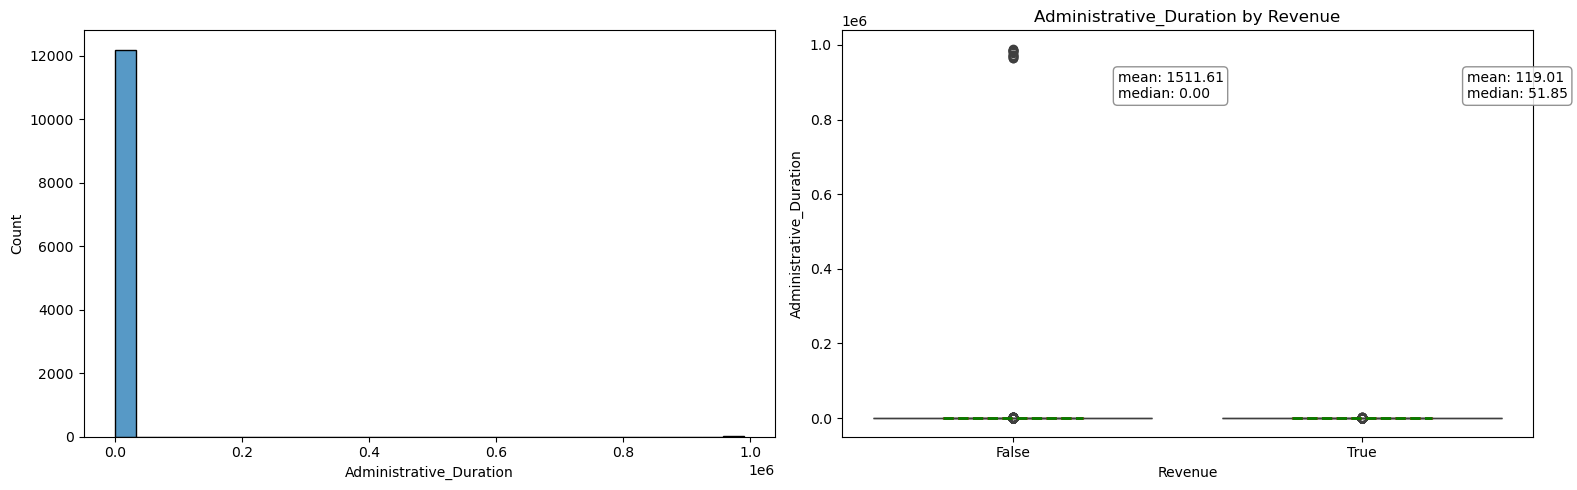


Feature: Informational
Description: Number of page visits within this category
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0 24 0.5032358482837717 0.0


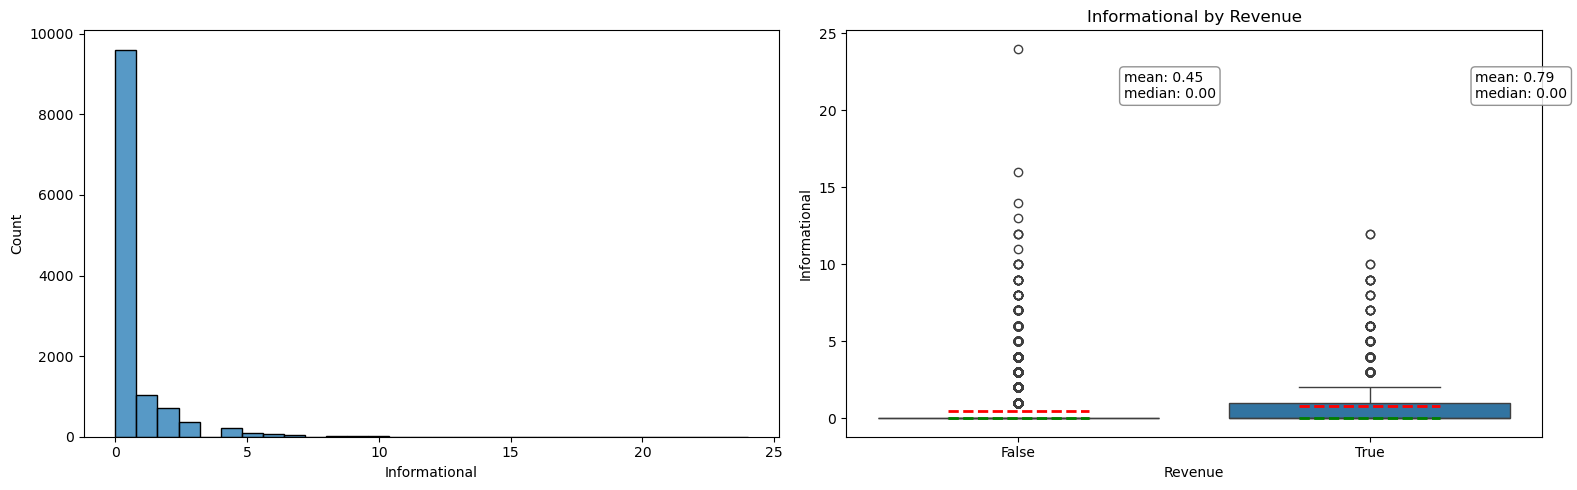


Feature: Informational_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0.0 2549.375 34.17714151291268 0.0


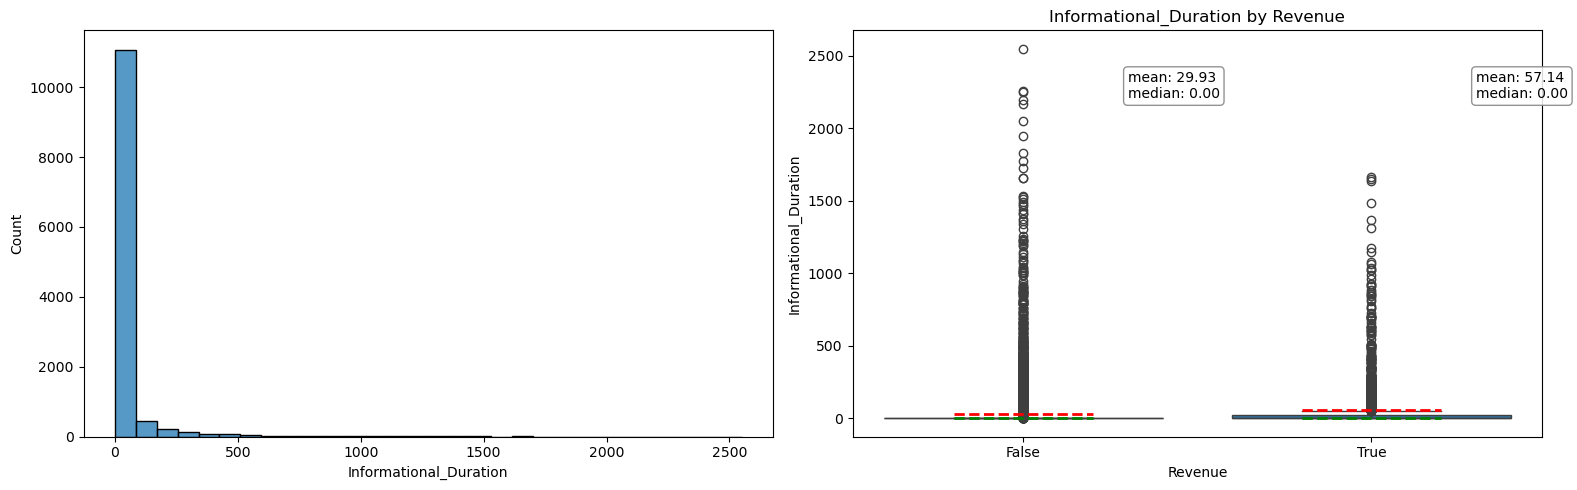


Feature: ProductRelated
Description: Number of page visits within this category
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0 705 31.73769148849021 18.0


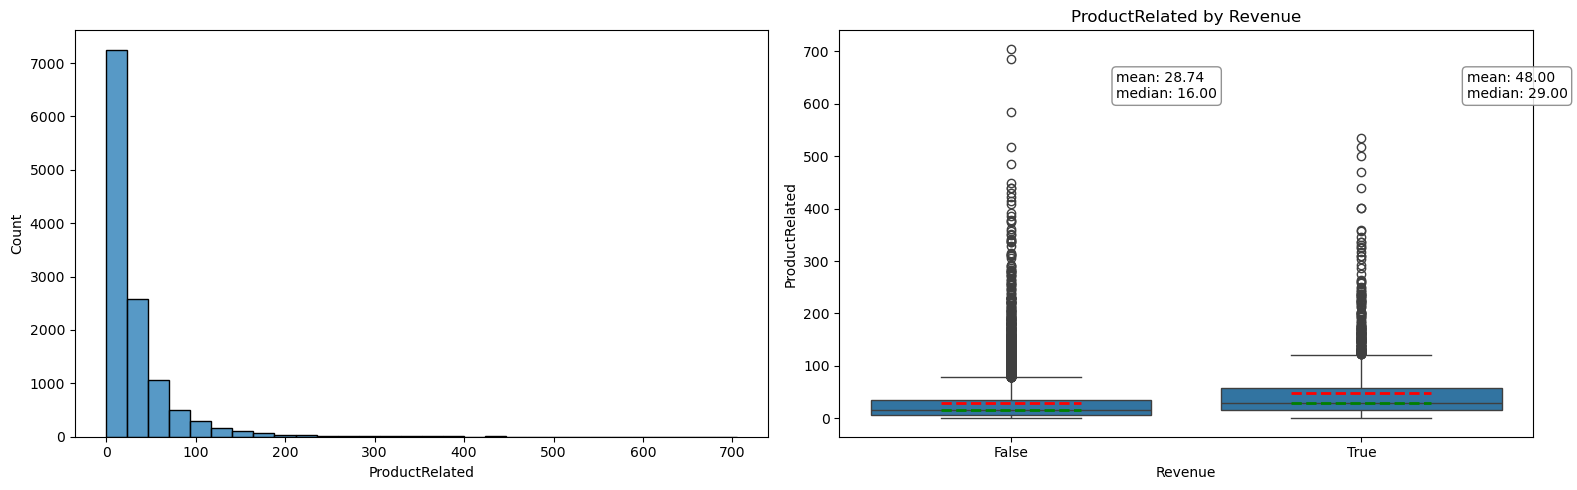


Feature: ProductRelated_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0.0 63973.52223 1195.4989514967726 599.5


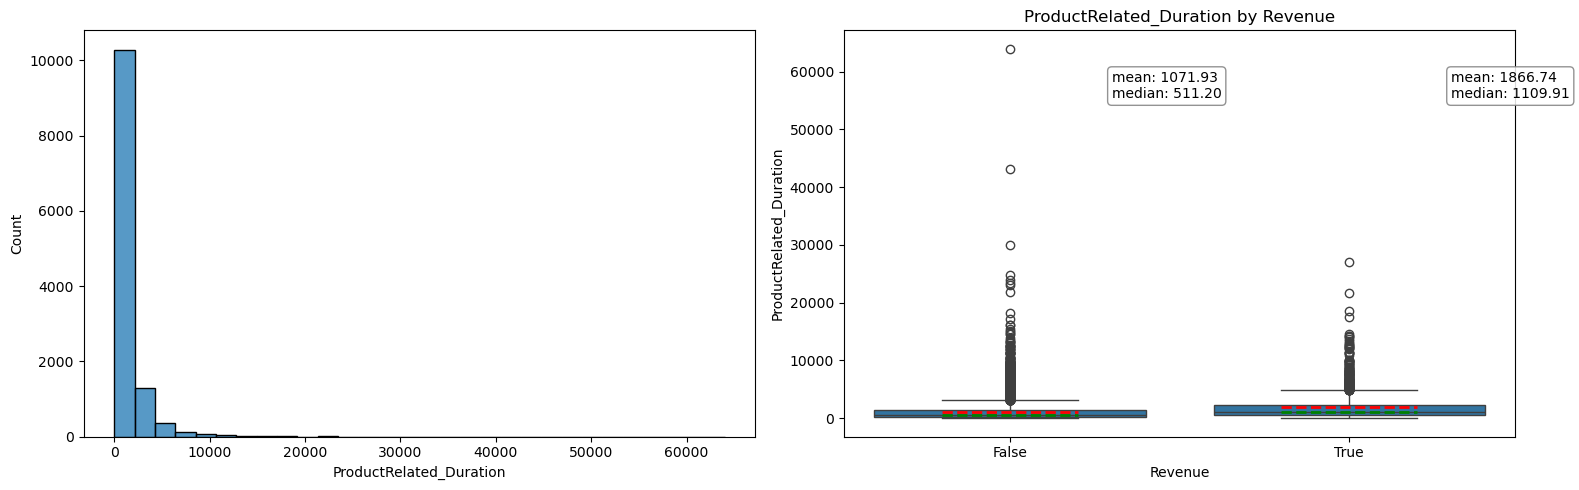


Feature: BounceRates
Description: Bounce rate of current page
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 -0.4986798792563108 2.098951827747294 0.0440198827953075 0.002857143


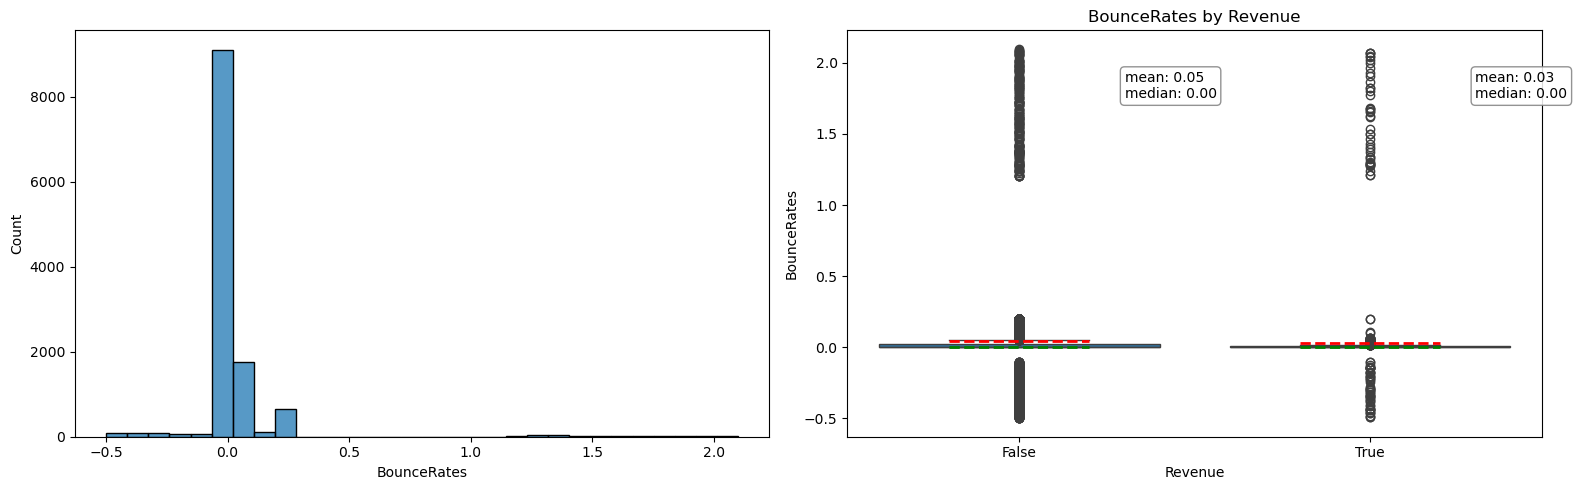


Feature: ExitRates
Description: Exit rate value of current page
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0.0 0.2 0.04302438844458098 0.025141026


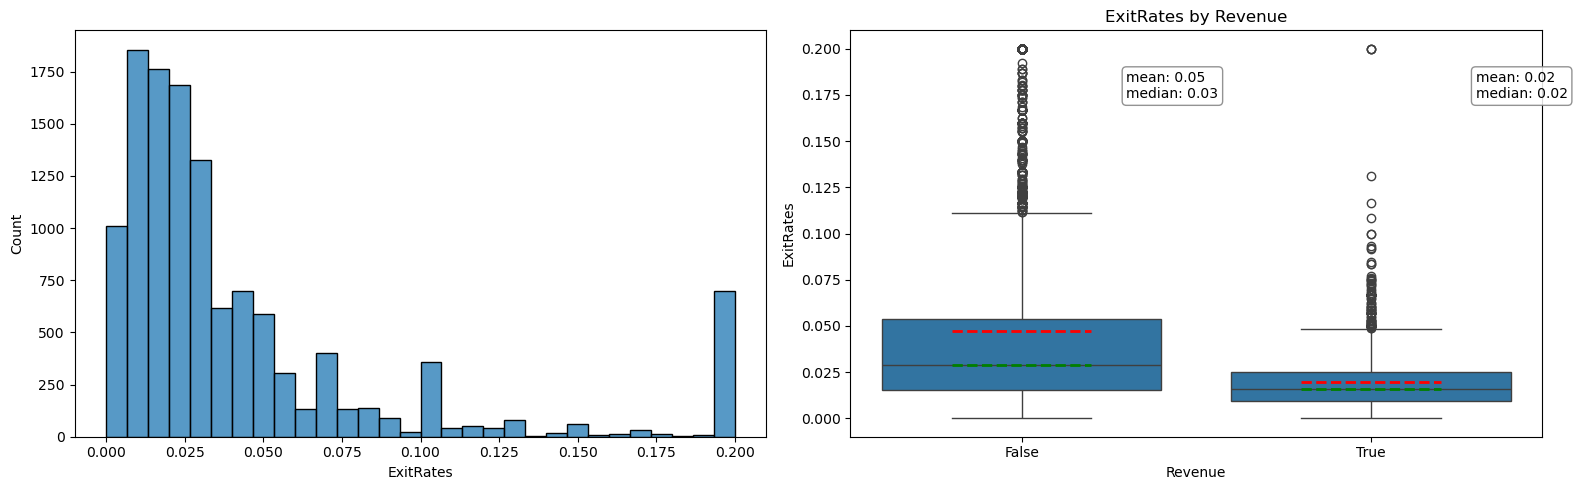


Feature: PageValues
Description: Page value of current page
Missing Values: 0 (0.00%)
Basic Statistics:
 Min      Max        Mean      Median
 0.0 361.7637419 5.901653038846728 0.0


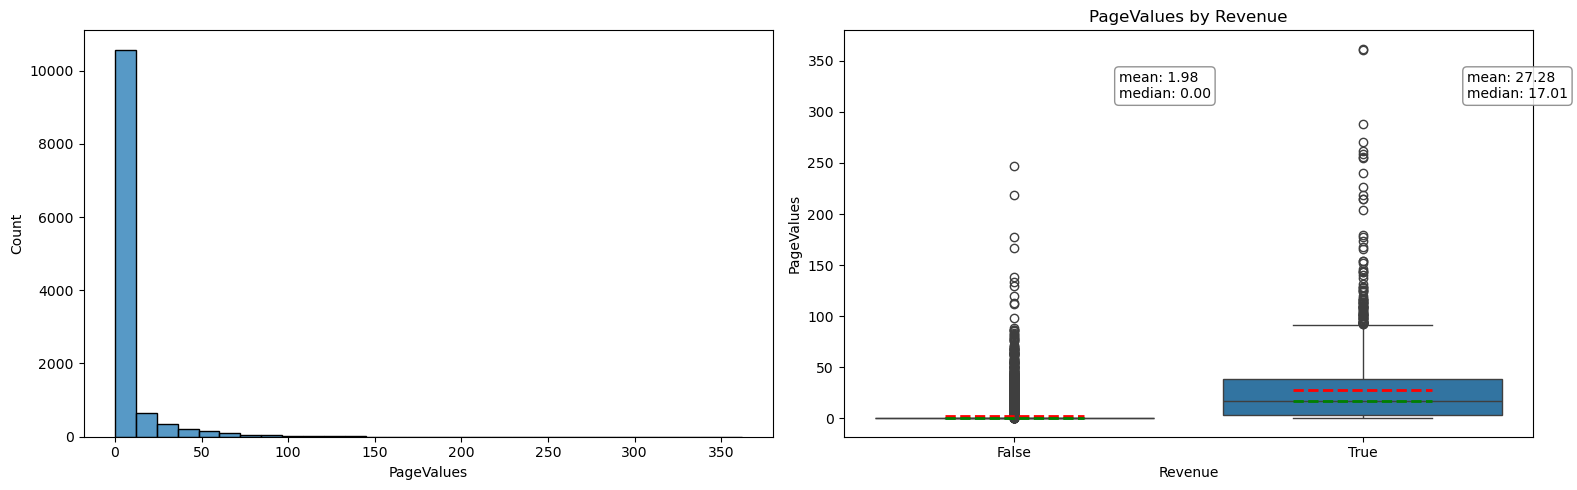


Feature: SpecialDay
Description: Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
Missing Values: 119 (0.97%)
Basic Statistics:
 Min      Max        Mean      Median
 0.0 1.0 0.06075446724023825 0.0


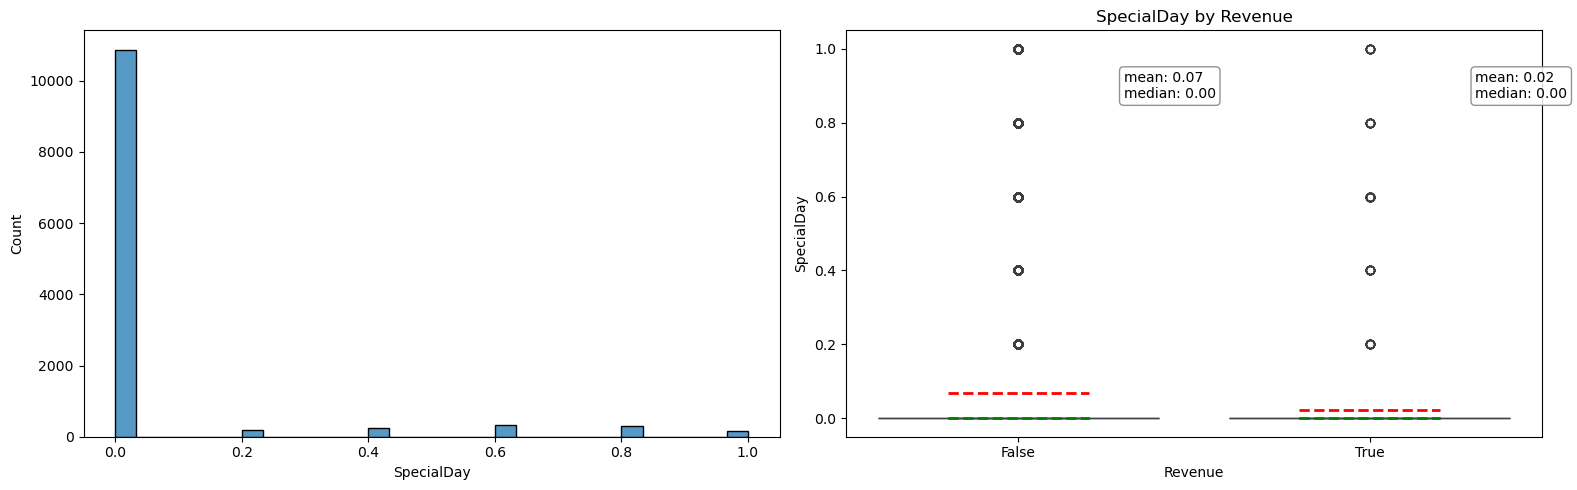


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3162
Nov    2968
Mar    1880
Dec    1714
Oct     544


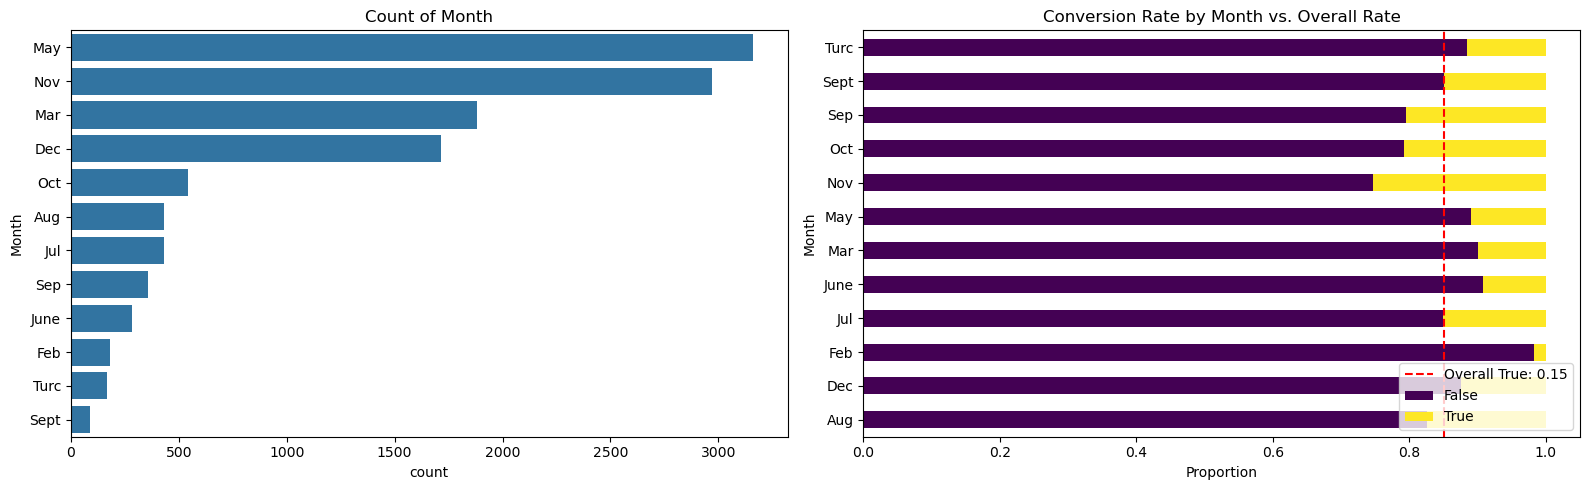


Feature: Weekend
Description: Boolean if the session day was in the weekend
Missing Values: 0 (0.00%)

Top 5 Categories:
Weekend
False        9170
True         2849
Name:Zara     188


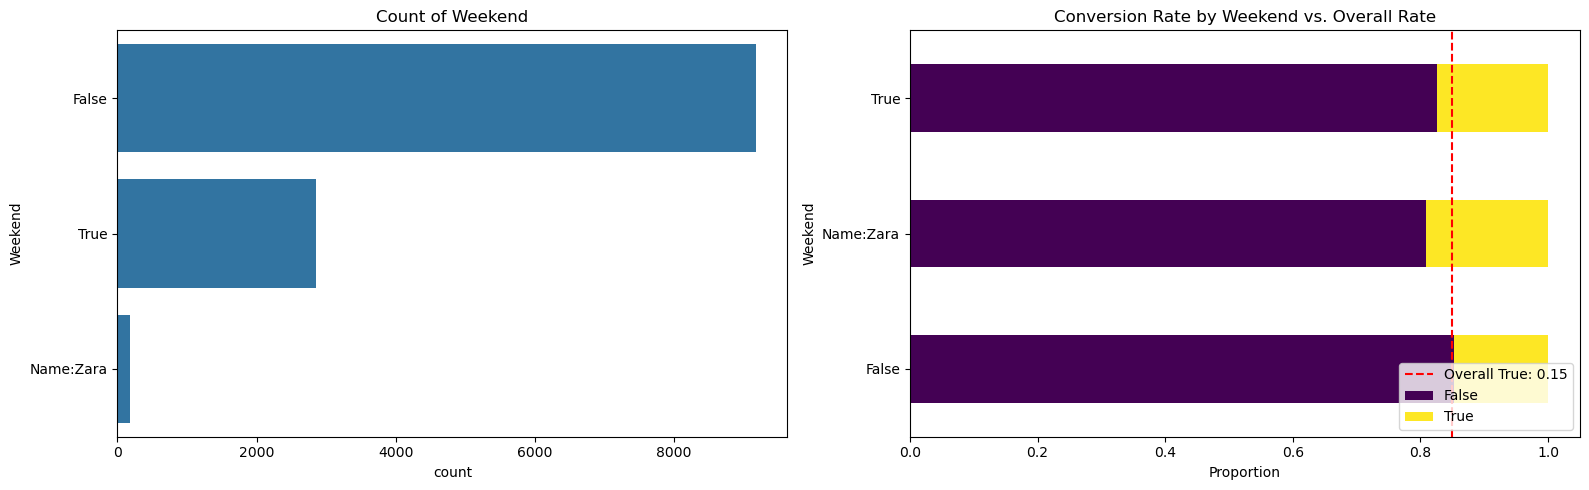


Feature: OperatingSystems
Description: Different OS' represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
OperatingSystems
2    6538
1    2550
3    2531
4     478
8      78


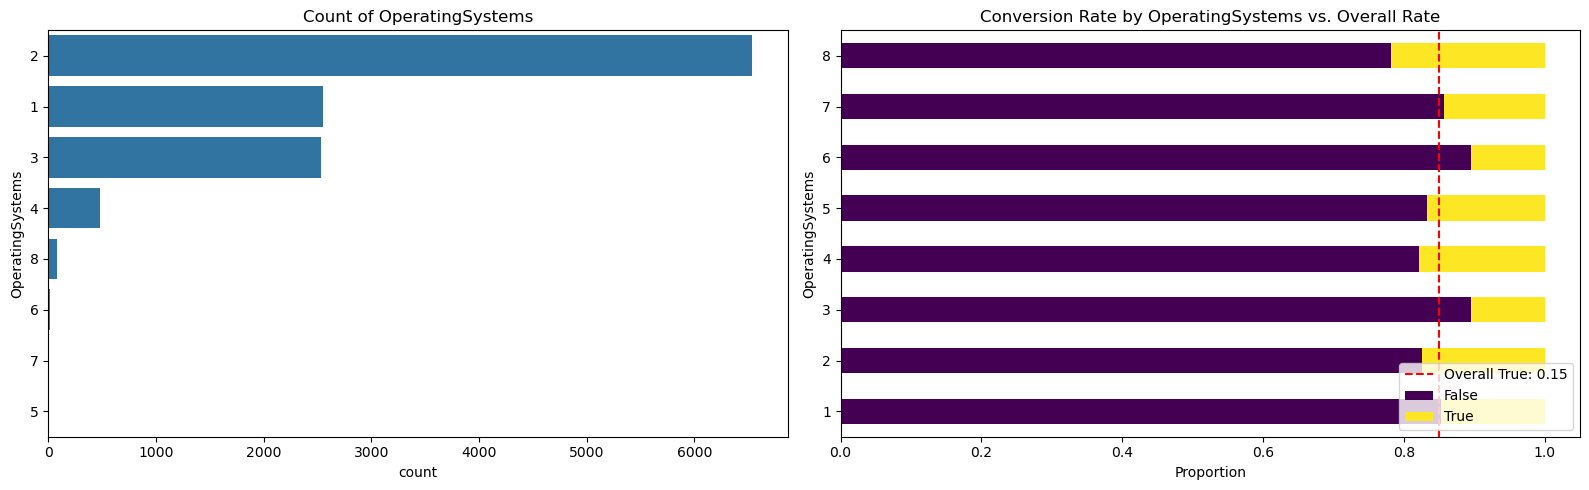


Feature: Browser
Description: Different browsers represented by different integers
Missing Values: 183 (1.50%)

Top 5 Categories:
Browser
2.0    7760
1.0    2394
4.0     717
5.0     461
6.0     169


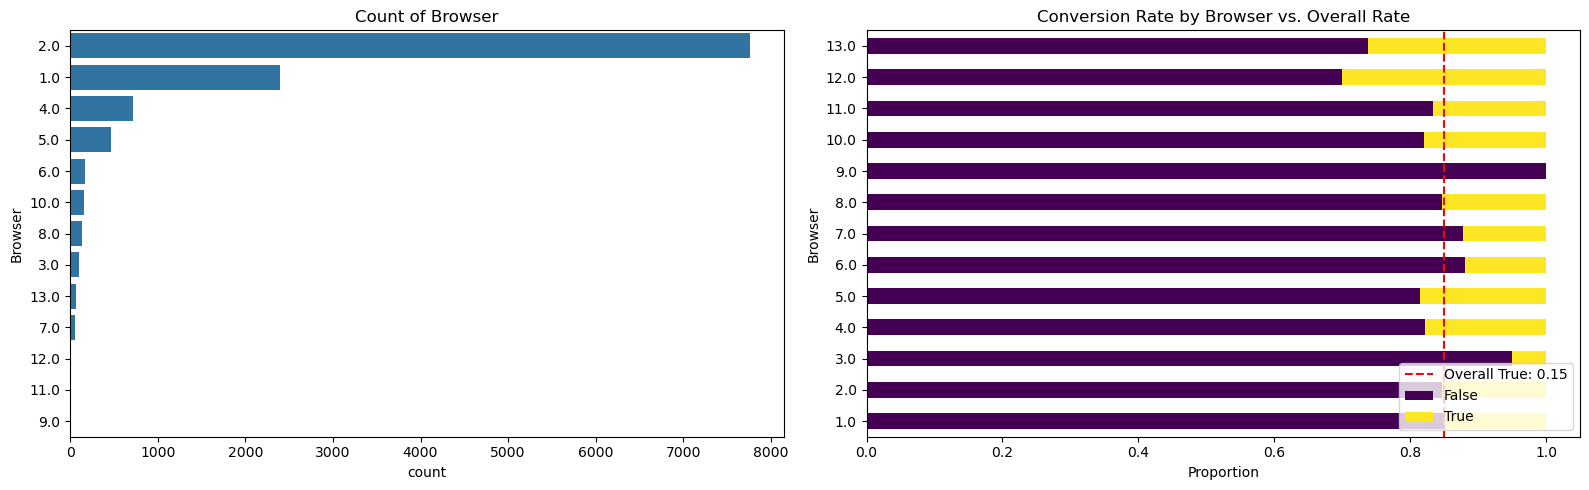


Feature: Region
Description: Different regions represented by different integers
Missing Values: 243 (1.99%)

Top 5 Categories:
Region
1.0    4643
3.0    2323
4.0    1146
2.0    1101
6.0     781


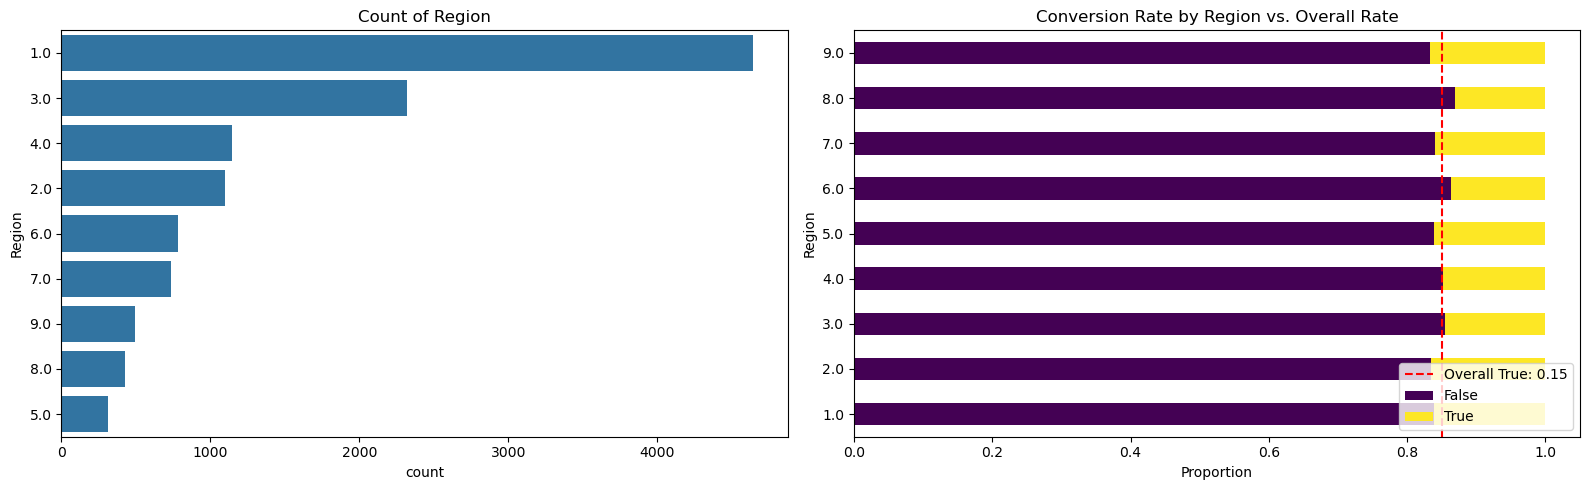


Feature: TrafficType
Description: Different traffic types represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
TrafficType
2     3876
1     2428
3     2031
4     1061
13     729


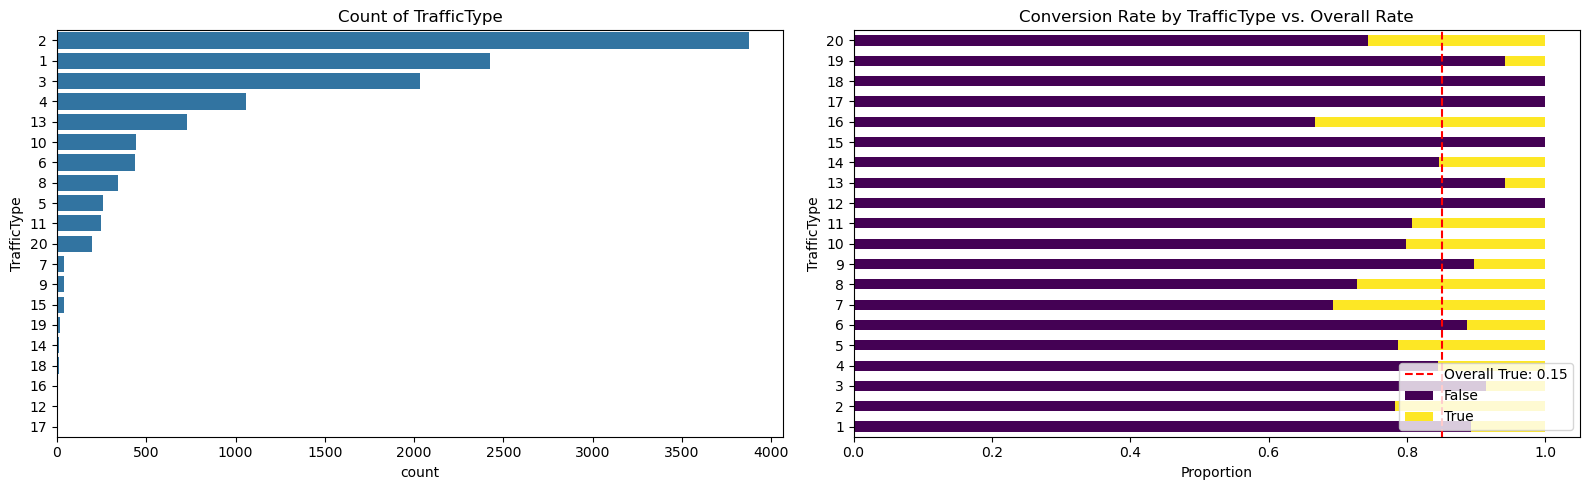


Feature: VisitorType
Description: Different visitor types represented by different categorical values
Missing Values: 0 (0.00%)

Top 5 Categories:
VisitorType
Returning_Visitor    10445
New_Visitor           1677
Other                   85


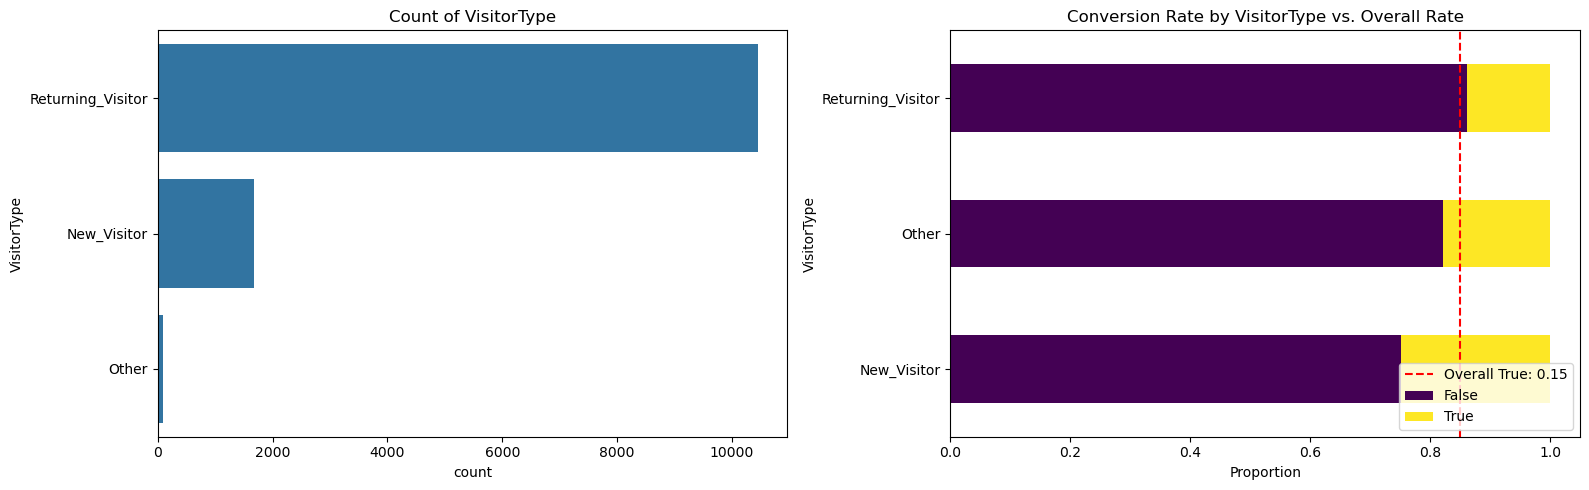

In [315]:
# First lets look at all features
plot_feature_eda(session_data_df, column_descriptions)

### Feature Plot Analysis

Insights:

Features that seem to have outliers:
1. Administrative_duration
2. Informational
3. ProductRelated_Duration
4. PageValues

Classes with ZERO or low conversion:
1. Month: {'Feb'}
2. Browser: {9.0, 3.0}
3. TrafficType: {18, 17, 15, 13, 12}

Call to action:
1. Lets look at at the outliers of: {'Administrative_duration', 'Informational', 'ProductRelated_Duration', 'PageValues'}
2. We need to speak to our domain expert about the zero/low conversion rates we found.

In [316]:
# Put features with outliers in a list for easier analysis.
outlier_features = ['Administrative_Duration', 'Informational', 'ProductRelated_Duration', 'PageValues']

# Lets look at the 20 largest values in each feature - this should help us identify how many values are outliers
outlier_value = 20

# Loop over features and show top 20 values
for feature in outlier_features:

    print(f'{feature}: Top {outlier_value} values')
    display(session_data_df[feature].nlargest(outlier_value))

Administrative_Duration: Top 20 values


2560     989493.000000
3757     987522.000000
7260     985308.000000
9375     985147.000000
8979     984643.000000
9642     984508.000000
6160     980612.000000
7789     977747.000000
9948     973917.000000
6434     971707.000000
7459     971509.000000
11172    970294.000000
7109     968066.000000
10955    965596.000000
8641     965480.000000
8071       3398.750000
5776       2720.500000
9238       2657.318056
5152       2629.253968
6165       2407.423810
Name: Administrative_Duration, dtype: float64

Informational: Top 20 values


5152     24
184      16
373      14
6757     14
9238     13
610      12
4316     12
4378     12
8872     12
12131    12
4226     11
1913     10
7329     10
8632     10
9712     10
11346    10
11713    10
12110    10
1572      9
2415      9
Name: Informational, dtype: int64

ProductRelated_Duration: Top 20 values


8071     63973.52223
5152     43171.23338
9238     29970.46597
8784     27009.85943
8308     24844.15620
7662     23888.81000
6684     23342.08205
6165     23050.10414
5916     21857.04648
8972     21672.24425
10318    18504.12621
6066     18171.79454
8557     17550.58486
9901     17086.23424
11130    16138.29080
6322     16093.30941
7900     15454.43857
8230     15025.23302
11713    14988.59151
6278     14577.08498
Name: ProductRelated_Duration, dtype: float64

PageValues: Top 20 values


9239     361.763742
8635     360.953384
10853    287.953793
11816    270.784693
1491     261.491286
6547     258.549873
8794     255.569158
3529     254.607158
5773     246.758590
3110     239.980000
12108    226.677702
8436     218.864910
8345     218.395192
2659     215.009412
10877    214.306663
5464     204.007949
6955     179.307293
6812     177.771454
10640    177.528825
4069     173.469792
Name: PageValues, dtype: float64

#### Outlier Analysis

Insights:
1. Quite clear that the top 15 'Administrative_Duration' values are outliers. They are more than two orders of magnitude larger than the next value.
2. The other columns just have a couple of outliers

Call to action:
1. Remove all outliers

In [317]:
display(session_data_df['Administrative_Duration'].nlargest(20))
display(len(session_data_df))

# Get the index of the 15 outlier values in the Administraive_Duration column
outliers_to_drop_from_administrative_duration = session_data_df['Administrative_Duration'].nlargest(15).index

# Remove these rows from the dataframe
session_data_df.drop(index=outliers_to_drop_from_administrative_duration, inplace=True)

# Lets check that we removed the rows we intended to
display(session_data_df['Administrative_Duration'].nlargest(20))
display(len(session_data_df))

2560     989493.000000
3757     987522.000000
7260     985308.000000
9375     985147.000000
8979     984643.000000
9642     984508.000000
6160     980612.000000
7789     977747.000000
9948     973917.000000
6434     971707.000000
7459     971509.000000
11172    970294.000000
7109     968066.000000
10955    965596.000000
8641     965480.000000
8071       3398.750000
5776       2720.500000
9238       2657.318056
5152       2629.253968
6165       2407.423810
Name: Administrative_Duration, dtype: float64

12207

8071     3398.750000
5776     2720.500000
9238     2657.318056
5152     2629.253968
6165     2407.423810
4884     2156.166667
11712    2137.112745
9736     2086.750000
1572     2047.234848
4509     1951.279141
9662     1946.000000
12017    1922.000000
3654     1764.000000
3227     1751.047619
8707     1715.000000
2446     1687.500000
5754     1672.033333
9633     1668.500000
6645     1660.300000
8368     1652.000000
Name: Administrative_Duration, dtype: float64

12192

In [318]:
indices_to_drop = [5152, 8071, 5152, 9239, 8635]

session_data_df.drop(index=indices_to_drop, inplace=True)

for feature in outlier_features:

    print(f'{feature}: Top {outlier_value} values')
    display(session_data_df[feature].nlargest(outlier_value))

Administrative_Duration: Top 20 values


5776     2720.500000
9238     2657.318056
6165     2407.423810
4884     2156.166667
11712    2137.112745
9736     2086.750000
1572     2047.234848
4509     1951.279141
9662     1946.000000
12017    1922.000000
3654     1764.000000
3227     1751.047619
8707     1715.000000
2446     1687.500000
5754     1672.033333
9633     1668.500000
6645     1660.300000
8368     1652.000000
1277     1640.590909
3185     1629.333333
Name: Administrative_Duration, dtype: float64

Informational: Top 20 values


184      16
373      14
6757     14
9238     13
610      12
4316     12
4378     12
8872     12
12131    12
4226     11
1913     10
7329     10
8632     10
9712     10
11346    10
11713    10
12110    10
1572      9
2415      9
6020      9
Name: Informational, dtype: int64

ProductRelated_Duration: Top 20 values


9238     29970.46597
8784     27009.85943
8308     24844.15620
7662     23888.81000
6684     23342.08205
6165     23050.10414
5916     21857.04648
8972     21672.24425
10318    18504.12621
6066     18171.79454
8557     17550.58486
9901     17086.23424
11130    16138.29080
6322     16093.30941
7900     15454.43857
8230     15025.23302
11713    14988.59151
6278     14577.08498
10815    14568.16201
8630     14505.72725
Name: ProductRelated_Duration, dtype: float64

PageValues: Top 20 values


10853    287.953793
11816    270.784693
1491     261.491286
6547     258.549873
8794     255.569158
3529     254.607158
5773     246.758590
3110     239.980000
12108    226.677702
8436     218.864910
8345     218.395192
2659     215.009412
10877    214.306663
5464     204.007949
6955     179.307293
6812     177.771454
10640    177.528825
4069     173.469792
9727     167.230834
6429     166.373553
Name: PageValues, dtype: float64

# Rando: First Value

Remaining on our EDA checklist are some "random" values that appear.
In the VisitorType feature, we have rows with the value 'Other' which is not specificed in the documentation of the data.
In Weekend, a boolean feature, we have rows with the value 'Name:Zara'.
In Month we have 'Sept' and 'Turc'.

Let dig into these random values!

In [319]:
session_data_df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10435
New_Visitor           1670
Other                   83
Name: count, dtype: int64

In [320]:
visiter_type_other_filter = session_data_df['VisitorType'] == 'Other'

In [321]:
visiter_type_other_df = session_data_df[visiter_type_other_filter]

summarise_df(visiter_type_other_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,14,1652.0,4,410.5,222,9630.209524
min_value,0,0.0,0,0.0,1,0.0
mean_value,1.506024,64.206325,0.180723,11.967068,12.228916,574.693132
standard_deviation,2.529694,206.138397,0.70095,60.491417,26.165666,1277.697806


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.376004,0.2,226.677702
min_value,-0.494399,0.000667,0.0
mean_value,0.049515,0.062408,14.281333
standard_deviation,0.226522,0.070069,38.003088


,SpecialDay
data_type,float64
max_value,0.0
min_value,0.0
mean_value,0.0
standard_deviation,0.0


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[June, Dec, Nov]","[8, 2, 1, 3]","[13.0, 2.0, 1.0, 10.0, 4.0, 5.0, nan]","[9.0, 4.0, 3.0, 1.0, nan, 2.0, 6.0, 7.0]","[5, 20, 2, 10, 3, 1, 13, 6, 11, 8]",[Other],"[False, True, Name:Zara]","[False, True, nan]"
value_counts,"[(Dec, 61), (Nov, 21), (June, 1)]","[(8, 53), (2, 16), (3, 8), (1, 6)]","[(13.0, 51), (2.0, 21), (1.0, 5), (4.0, 2), (5...","[(9.0, 54), (3.0, 7), (1.0, 6), (4.0, 5), (2.0...","[(20, 51), (2, 11), (3, 7), (1, 6), (10, 3), (...","[(Other, 83)]","[(False, 74), (True, 7), (Name:Zara, 2)]","[(False, 68), (True, 14), (nan, 1)]"
top_value,"(Dec, 61)","(8, 53)","(13.0, 51)","(9.0, 54)","(20, 51)","(Other, 83)","(False, 74)","(False, 68)"
bottom_value,"(June, 1)","(1, 6)","(nan, 1)","(6.0, 1)","(8, 1)","(Other, 83)","(Name:Zara, 2)","(nan, 1)"


### VisitorType: Other Analysis

Insights:
Inconclusive

Call to action:
1. Keep rows unchanged
2. Raise to Domain Expert

Now lets move onto our friend Zara, some Turcs and September's doppelganger. . .

In [322]:
weekend_name_zara_filter = session_data_df['Weekend'] == 'Name:Zara'

weekend_name_zara_df = session_data_df[weekend_name_zara_filter]

summarise_df(weekend_name_zara_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,22,1951.279141,7,1079.833333,305,9143.435714
min_value,0,0.0,0,0.0,0,0.0
mean_value,2.812834,102.730337,0.684492,39.37268,37.962567,1423.897097
standard_deviation,3.951622,220.375844,1.352785,137.76971,49.723036,1893.472776


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.775659,0.2,218.86491
min_value,-0.474555,0.0,0.0
mean_value,0.040845,0.043135,7.402656
standard_deviation,0.233452,0.046226,23.596734


,SpecialDay
data_type,float64
max_value,0.8
min_value,0.0
mean_value,0.075269
standard_deviation,0.199272


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Nov, Jul, Oct, June, Aug...","[2, 1, 4, 3, 6, 8]","[2.0, 6.0, 1.0, nan, 5.0, 4.0, 8.0, 10.0, 13.0]","[3.0, 1.0, 2.0, 6.0, 7.0, 9.0, 4.0, 8.0, nan, ...","[1, 2, 4, 3, 8, 10, 13, 6, 5, 19, 14, 20, 11]","[Returning_Visitor, New_Visitor, Other]",[Name:Zara],"[True, False, nan]"
value_counts,"[(May, 61), (Nov, 39), (Mar, 28), (Dec, 23), (...","[(2, 109), (1, 41), (3, 27), (4, 5), (8, 3), (...","[(2.0, 116), (1.0, 40), (5.0, 8), (4.0, 8), (6...","[(1.0, 76), (3.0, 29), (6.0, 21), (2.0, 18), (...","[(2, 63), (1, 38), (3, 31), (4, 21), (13, 10),...","[(Returning_Visitor, 170), (New_Visitor, 15), ...","[(Name:Zara, 187)]","[(False, 148), (True, 34), (nan, 5)]"
top_value,"(May, 61)","(2, 109)","(2.0, 116)","(1.0, 76)","(2, 63)","(Returning_Visitor, 170)","(Name:Zara, 187)","(False, 148)"
bottom_value,"(Turc, 1)","(6, 2)","(13.0, 2)","(nan, 2)","(14, 1)","(Other, 2)","(Name:Zara, 187)","(nan, 5)"


In [323]:
month_sept_filter = session_data_df['Month'] == 'Sept'

month_sept_df = session_data_df[month_sept_filter]

summarise_df(month_sept_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,19,484.461579,7,790.006667,429,9836.068333
min_value,0,0.0,0,0.0,1,0.0
mean_value,4.306818,117.457403,0.465909,24.873842,33.465909,1262.40872
standard_deviation,4.194572,123.444062,1.164108,100.063049,50.538241,1870.698895


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.893714,0.2,60.044729
min_value,-0.291723,0.001471,0.0
mean_value,0.061687,0.032262,5.053891
standard_deviation,0.276521,0.033559,11.804998


,SpecialDay
data_type,float64
max_value,0.0
min_value,0.0
mean_value,0.0
standard_deviation,0.0


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,[Sept],"[3, 2, 4, 1, 5]","[2.0, 1.0, 5.0, 4.0, 6.0, 10.0, 8.0, nan, 11.0]","[1.0, 2.0, 7.0, 4.0, 3.0, 8.0, 5.0, 9.0, 6.0]","[6, 2, 3, 1, 13, 5, 4]","[Returning_Visitor, New_Visitor]","[False, True, Name:Zara]","[False, True, nan]"
value_counts,"[(Sept, 88)]","[(2, 46), (3, 22), (1, 14), (4, 5), (5, 1)]","[(2.0, 57), (1.0, 16), (4.0, 6), (5.0, 2), (10...","[(1.0, 30), (3.0, 18), (4.0, 13), (2.0, 5), (8...","[(1, 26), (2, 24), (3, 11), (4, 9), (13, 7), (...","[(Returning_Visitor, 72), (New_Visitor, 16)]","[(False, 70), (True, 16), (Name:Zara, 2)]","[(False, 73), (True, 13), (nan, 2)]"
top_value,"(Sept, 88)","(2, 46)","(2.0, 57)","(1.0, 30)","(1, 26)","(Returning_Visitor, 72)","(False, 70)","(False, 73)"
bottom_value,"(Sept, 88)","(5, 1)","(11.0, 1)","(9.0, 4)","(6, 4)","(New_Visitor, 16)","(Name:Zara, 2)","(nan, 2)"


In [324]:
month_turc_filter = session_data_df['Month'] == 'Turc'

month_turc_df = session_data_df[month_turc_filter]

summarise_df(month_turc_df);

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,14,1261.916667,12,985.419048,124,6266.208586
min_value,0,0.0,0,0.0,1,0.0
mean_value,1.6,66.9203,0.327273,25.60658,22.939394,769.664719
standard_deviation,2.49585,152.434116,1.116198,110.673446,23.92613,904.432278


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.979375,0.2,165.620467
min_value,-0.413398,0.0016,0.0
mean_value,0.062858,0.048602,6.414644
standard_deviation,0.27906,0.05182,19.545259


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.215951
standard_deviation,0.339194


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,[Turc],"[2, 3, 1, 4, 6]","[2.0, 5.0, 1.0, 4.0, 10.0, 6.0, 7.0, 3.0, nan,...","[2.0, 6.0, 1.0, 4.0, 9.0, 3.0, 7.0, 5.0, 8.0, ...","[2, 1, 4, 3, 13, 6, 11, 15, 5, 19]","[Returning_Visitor, New_Visitor]","[True, False, Name:Zara]","[False, True]"
value_counts,"[(Turc, 165)]","[(2, 92), (3, 35), (1, 35), (4, 2), (6, 1)]","[(2.0, 107), (1.0, 27), (4.0, 13), (5.0, 7), (...","[(1.0, 62), (3.0, 27), (2.0, 22), (4.0, 19), (...","[(4, 42), (2, 41), (3, 31), (1, 21), (13, 11),...","[(Returning_Visitor, 149), (New_Visitor, 16)]","[(False, 120), (True, 44), (Name:Zara, 1)]","[(False, 146), (True, 19)]"
top_value,"(Turc, 165)","(2, 92)","(2.0, 107)","(1.0, 62)","(4, 42)","(Returning_Visitor, 149)","(False, 120)","(False, 146)"
bottom_value,"(Turc, 165)","(6, 1)","(8.0, 1)","(8.0, 2)","(19, 1)","(New_Visitor, 16)","(Name:Zara, 1)","(True, 19)"


Insights: Inconclusive - lets focus on conversion rates.

In [325]:
session_data_df['Month'].value_counts()

Month
May     3159
Nov     2962
Mar     1880
Dec     1709
Oct      542
Aug      431
Jul      429
Sep      358
June     284
Feb      181
Turc     165
Sept      88
Name: count, dtype: int64

Analyzing 'Name:Zara' in Weekend column...

Name:Zara in Weekend Analysis:
Total rows with Name:Zara: 187 rows (1.53% of all data)

Conversion Analysis:
Converted rows in Name:Zara subset: 34 (18.18% conversion rate within subset)
Overall conversion rate: 15.28%
Portion of all conversions: 34/1862 (1.83% of all conversions)


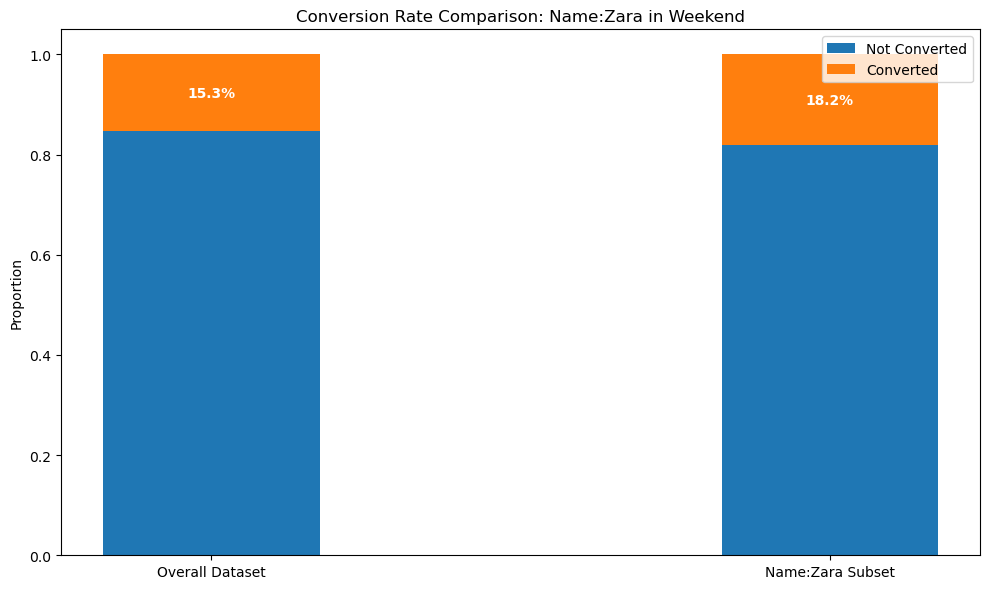

Analyzing 'Sept' in Month column...

Sept in Month Analysis:
Total rows with Sept: 88 rows (0.72% of all data)

Conversion Analysis:
Converted rows in Sept subset: 13 (14.77% conversion rate within subset)
Overall conversion rate: 15.28%
Portion of all conversions: 13/1862 (0.70% of all conversions)


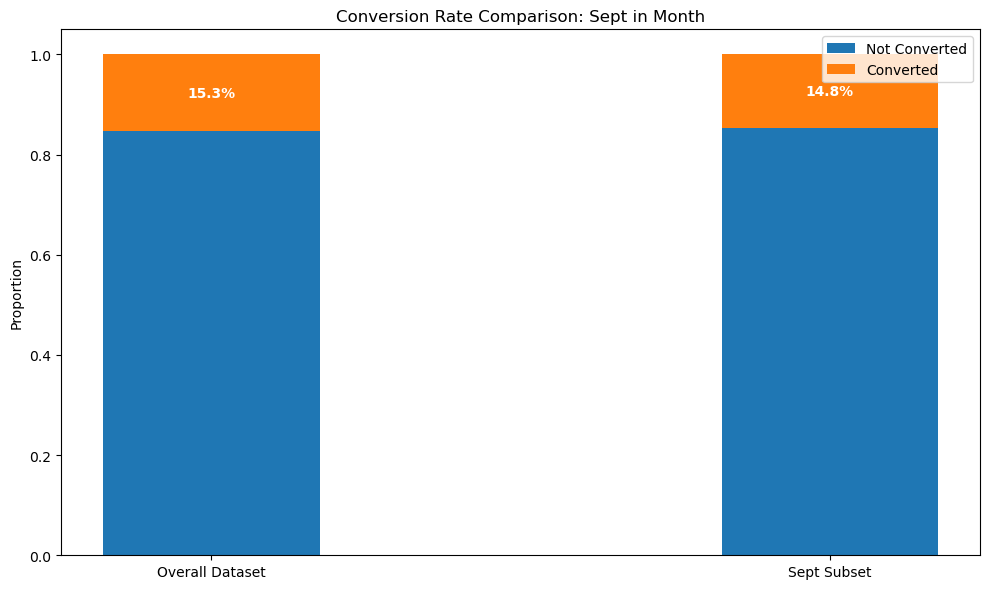

Analyzing 'Sep' in Month column...

Sep in Month Analysis:
Total rows with Sep: 358 rows (2.94% of all data)

Conversion Analysis:
Converted rows in Sep subset: 72 (20.11% conversion rate within subset)
Overall conversion rate: 15.28%
Portion of all conversions: 72/1862 (3.87% of all conversions)


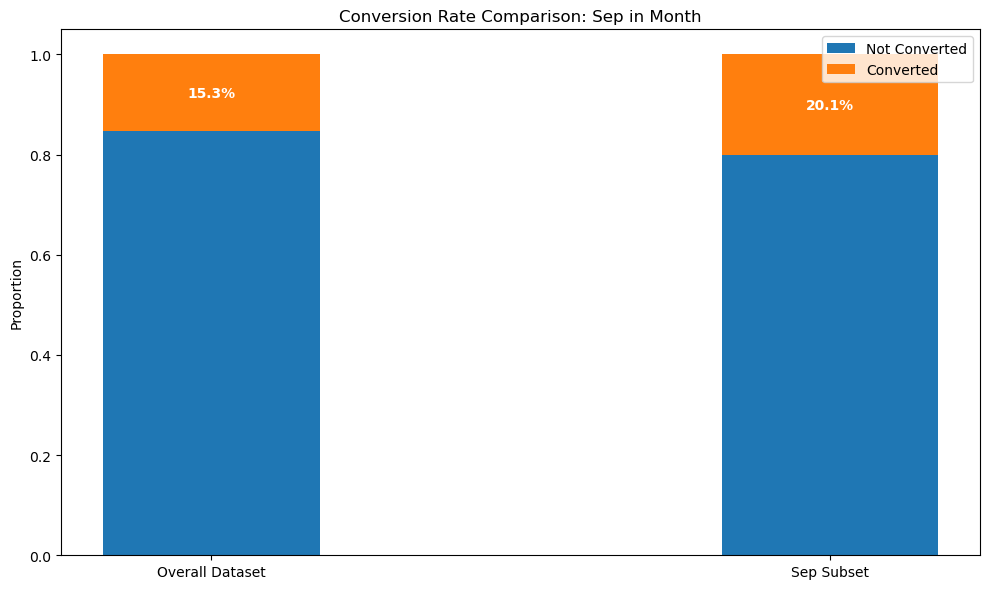

Analyzing 'Turc' in Month column...

Turc in Month Analysis:
Total rows with Turc: 165 rows (1.35% of all data)

Conversion Analysis:
Converted rows in Turc subset: 19 (11.52% conversion rate within subset)
Overall conversion rate: 15.28%
Portion of all conversions: 19/1862 (1.02% of all conversions)


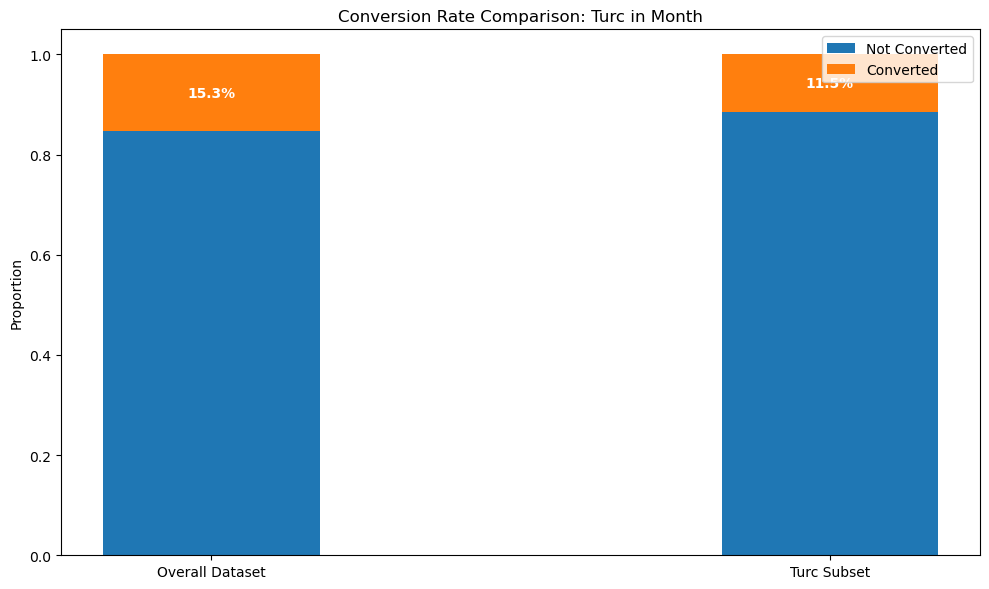

In [326]:
# Now use the function for all three unusual values - no need for manual print statements!
analyze_unusual_value(session_data_df, 'Weekend', 'Name:Zara')

analyze_unusual_value(session_data_df, 'Month', 'Sept')

analyze_unusual_value(session_data_df, 'Month', 'Sep')

analyze_unusual_value(session_data_df, 'Month', 'Turc')

### Name:Zara Final Analysis:

Insights: Inconclusive about what this anomaly might be. But these rows represent almost 2% of all converted rows and also have a much higher conversion rate than the overal conversion rate.

Call to Action: As these rows carry interesting patterns we will keep it and not rename it, so if this class is of importance for prediction, we can easily single it out instead of just calling it 'Unknown'. Furthermore we will raise this issue to the domain expert at the company. It is obviously not good for future data analysis' if data gets mislabled this way.

We need to dive into the anomaly months a dit deeper. . .

Lets first get another view using our plot_feature_eda function - seeing the conversion rates and size of the classes relative to others might be helpful.


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3159
Nov    2962
Mar    1880
Dec    1709
Oct     542


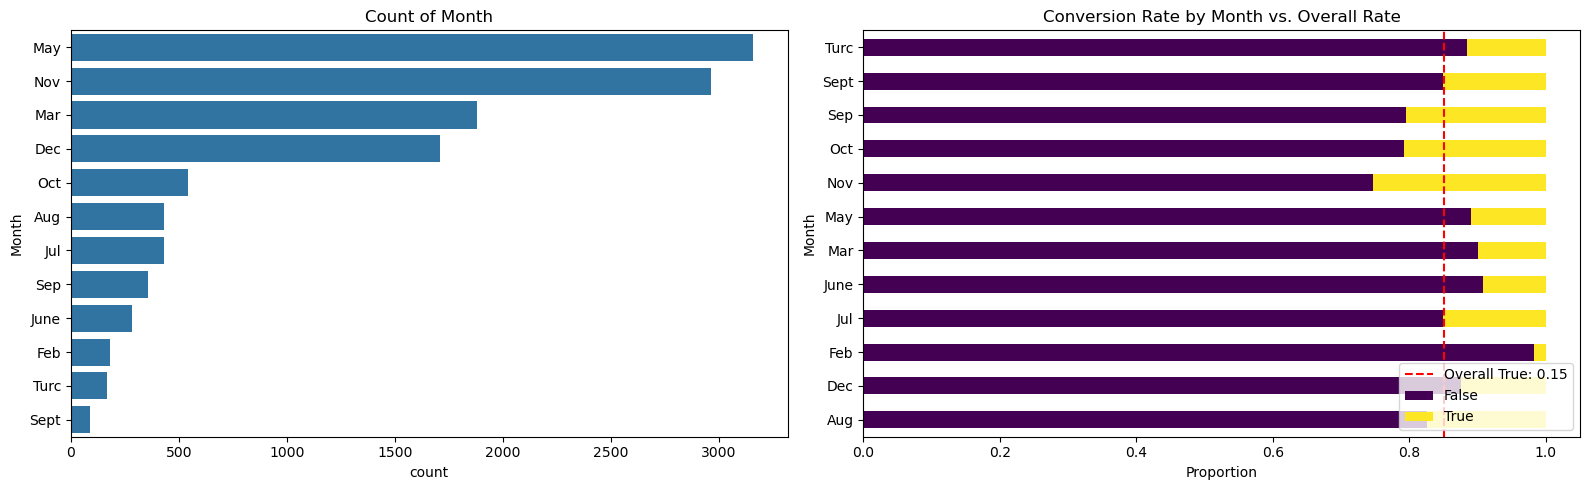

In [327]:
plot_feature_eda(session_data_df, column_descriptions, features_to_plot=['Month'])

This wasn't that helpful - although I am starting to more and more lean towards Sept, simply being samples belonging to Sep, but mislabled.

Lets look at the months in the actual order of the calender year.

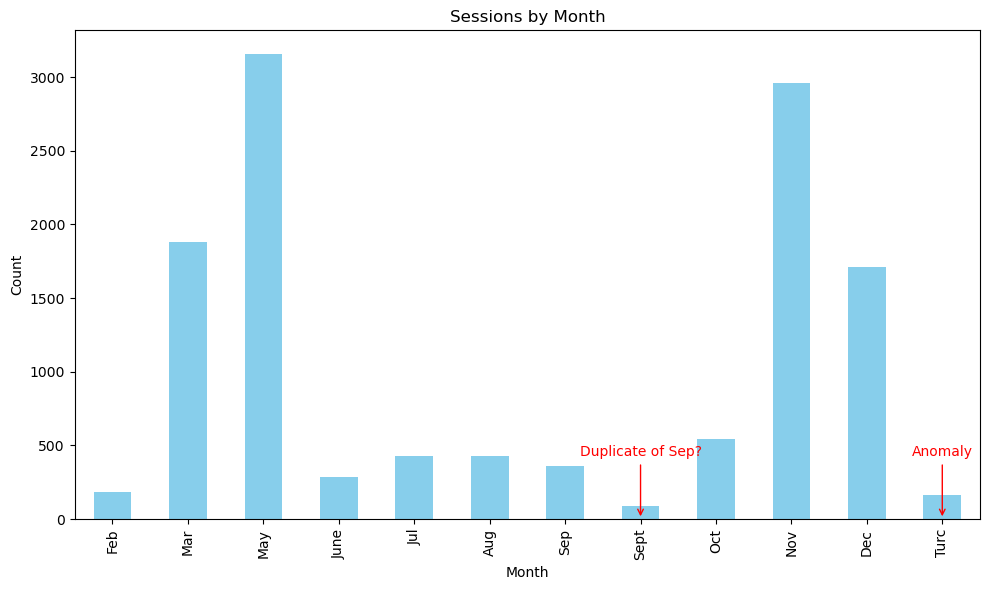

In [328]:
# Define the desired month order
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Sept', 'Oct', 'Nov', 'Dec', 'Turc']

# Count occurrences of each month
month_counts = session_data_df['Month'].value_counts().reindex(month_order)

# Create a simple bar chart
plt.figure(figsize=(10, 6))
month_counts.plot(kind='bar', color='skyblue')

# Add annotations for anomalies
plt.annotate('Duplicate of Sep?', xy=(7, 0), xytext=(7, 500),
             ha='center', va='top', color='red', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate('Anomaly', xy=(11, 0), xytext=(11, 500),
             ha='center', va='top', color='red', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='red'))

# Add a simple title and labels
plt.title('Sessions by Month')
plt.xlabel('Month')
plt.ylabel('Count')

# Show the plot
plt.tight_layout()
plt.show()

### Rando months values final analysis

Insights:

1. Sept is probably actually Sep - conversion rates in both classes are similar and the total of Sept and Sep together would make it fit well with the coutns of Aug and Oct.
2. I do however feel inconclusive about Turc. January and April are both remaining as months with missing samples, but it would be complete guesswork, and not even an educated one at that, for me to assume that Turc is either of these two. It could even be that Turc is actually some other month, but mislabeled and for some reason we lost all user data from January and April.
Furthermore the conversion rate of Turc is very interesting, much lower than the overall, making these samples seem important for predictions, especially given that Turc months carry 1% of all converted rows.

Call to action:
1. Replace Sept with Sep in month column
2. Keep Turc as is and raise to Domain Expert as the mislabling of user session is getting problematic for predictions


In [329]:
# Replace 'Sept' with 'Sep' in month column
session_data_df.loc[session_data_df['Month'] == 'Sept', 'Month'] = 'Sep'

# Double check that it worked
print(session_data_df['Month'].unique())

['Feb' 'Mar' 'May' 'Turc' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']


# Nan of this makes sense . . . 

It is worrying to see that the Revenue column has nans. Since this is our target column that really isn't good and must be raised to our domain expert.
A target column contains the very values we are *trying to predict*. This makes having missing values more problematic than in feature columns.
The consensus within the ML community seems to be that one should generally avoid replacing missing values in the target column - instead it is better to remove them. This agrees with my own intuition since it seems weird to try and guess (even if it is educated) values that you are trying to predict.
I vote for removing these, buts lets crunch some numbers first.

In [330]:
revenue_is_nan_filter = session_data_df['Revenue'].isna()

revenue_is_nan_df = session_data_df[revenue_is_nan_filter]

display(revenue_is_nan_df)

print(f'There are {len(revenue_is_nan_df)} rows where revenue is a nan value. This amounts to {round(len(revenue_is_nan_df)/session_df_row_count, 4)} of the total rows.')

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
48,0,0.000000,0,0.0,11,800.833333,0.000000,0.003636,0.000000,0.0,Feb,3,2.0,1.0,3,Returning_Visitor,False,NaN
82,0,0.000000,0,0.0,6,39.500000,0.000000,0.020000,0.000000,0.0,Feb,2,2.0,1.0,3,Returning_Visitor,False,NaN
113,2,22.000000,0,0.0,25,436.500000,0.008000,0.024000,0.000000,0.2,Feb,2,4.0,1.0,1,Returning_Visitor,False,NaN
188,9,111.500000,1,48.5,49,1868.819697,0.000000,0.020709,1.706015,0.0,Mar,2,2.0,7.0,2,Returning_Visitor,False,NaN
200,1,32.000000,0,0.0,50,2867.000000,0.000000,0.004000,153.443248,0.0,Mar,2,2.0,7.0,8,Returning_Visitor,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12005,5,76.000000,0,0.0,66,1415.387500,0.003582,0.014262,9.829115,0.0,Dec,2,2.0,5.0,2,Returning_Visitor,False,NaN
12069,2,163.000000,0,0.0,136,4201.508333,0.000000,0.011265,0.000000,0.0,Dec,3,2.0,3.0,3,Returning_Visitor,False,NaN
12093,10,260.250000,0,0.0,31,1694.333333,0.017143,0.039048,15.108543,0.0,Nov,2,2.0,4.0,3,Returning_Visitor,False,NaN
12182,9,102.866667,3,339.5,29,693.254167,0.000000,0.014706,77.649145,0.0,Dec,2,10.0,1.0,2,Returning_Visitor,False,NaN


There are 146 rows where revenue is a nan value. This amounts to 0.0118 of the total rows.


The amount of rows where revenue is nan is only about 1% of the total amount of rows. This is a very small ratio so lets just remove them asap!

In [331]:
# Use .dropna() method with subset parameter to drop all rows with nans in the revenue column 
session_data_df.dropna(subset='Revenue', inplace=True)

Let's deal with the rest of the nans

In [332]:
columns_with_nans

{'SpecialDay': 123, 'Browser': 184, 'Region': 246, 'Revenue': 147}

In [333]:
for key in columns_with_nans:
        if key != 'Revenue':
                nans_df = session_data_df[session_data_df[key].isna()]
                print(end=delimiter_between_prints)
                print(f'Summary of rows with nans in column: {key}. Row count: {len(nans_df)}')
                summarise_df(nans_df)



-----------

Summary of rows with nans in column: SpecialDay. Row count: 117


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,16,934.5,5,1037.15,501,21672.24425
min_value,0,0.0,0,0.0,1,0.0
mean_value,2.538462,78.484765,0.529915,37.394919,28.615385,1122.194118
standard_deviation,3.482811,157.921028,1.221733,124.885835,51.518133,2509.95054


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.811388,0.2,261.491286
min_value,-0.147128,0.0,0.0
mean_value,0.059704,0.042786,8.804983
standard_deviation,0.254207,0.047274,29.455012


,SpecialDay
data_type,float64
max_value,NaN
min_value,NaN
mean_value,NaN
standard_deviation,NaN


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Mar, May, Turc, Oct, Nov, Aug, Sep, Jul, Dec]","[1, 2, 3, 4]","[2.0, 5.0, 1.0, 10.0, 8.0, 6.0, 4.0, nan, 3.0]","[1.0, 4.0, 3.0, 6.0, 8.0, 2.0, 5.0, 9.0, 7.0, ...","[8, 1, 2, 3, 13, 4, 6, 5, 20, 10]","[Returning_Visitor, New_Visitor]","[False, True, Name:Zara]","[False, True]"
value_counts,"[(May, 34), (Nov, 30), (Mar, 18), (Dec, 18), (...","[(2, 67), (1, 24), (3, 21), (4, 5)]","[(2.0, 78), (1.0, 23), (4.0, 8), (10.0, 2), (5...","[(1.0, 51), (3.0, 20), (4.0, 10), (2.0, 10), (...","[(2, 41), (1, 23), (3, 18), (4, 10), (13, 7), ...","[(Returning_Visitor, 103), (New_Visitor, 14)]","[(False, 94), (True, 22), (Name:Zara, 1)]","[(False, 97), (True, 20)]"
top_value,"(May, 34)","(2, 67)","(2.0, 78)","(1.0, 51)","(2, 41)","(Returning_Visitor, 103)","(False, 94)","(False, 97)"
bottom_value,"(Sep, 2)","(4, 5)","(3.0, 1)","(nan, 2)","(8, 2)","(New_Visitor, 14)","(Name:Zara, 1)","(True, 20)"


...



-----------

Summary of rows with nans in column: Region. Row count: 241


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,22,1951.279141,7,1830.5,337,15454.43857
min_value,0,0.0,0,0.0,0,0.0
mean_value,2.431535,90.779929,0.53112,46.673686,29.394191,1161.878967
standard_deviation,3.721066,201.788447,1.172633,179.587833,38.601357,1840.580403


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.96016,0.2,129.101374
min_value,-0.489344,0.0,0.0
mean_value,0.059086,0.048706,5.423886
standard_deviation,0.280409,0.053899,16.65181


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.059414
standard_deviation,0.193989


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Oct, Aug, June, Jul, Nov...","[2, 4, 1, 3]","[2.0, 1.0, 6.0, 4.0, 8.0, 5.0, 10.0, 3.0, nan]",[nan],"[2, 3, 1, 6, 13, 9, 8, 4, 5, 11, 20, 10]","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, True]"
value_counts,"[(May, 70), (Nov, 58), (Dec, 40), (Mar, 30), (...","[(2, 107), (1, 64), (3, 57), (4, 13)]","[(2.0, 148), (1.0, 64), (4.0, 8), (8.0, 4), (5...","[(nan, 241)]","[(2, 71), (1, 48), (3, 41), (4, 22), (13, 20),...","[(Returning_Visitor, 209), (New_Visitor, 29), ...","[(False, 179), (True, 60), (Name:Zara, 2)]","[(False, 209), (True, 32)]"
top_value,"(May, 70)","(2, 107)","(2.0, 148)","(nan, 241)","(2, 71)","(Returning_Visitor, 209)","(False, 179)","(False, 209)"
bottom_value,"(Sep, 3)","(4, 13)","(3.0, 3)","(nan, 241)","(9, 1)","(Other, 3)","(Name:Zara, 2)","(True, 32)"


Nothing really stands out in the summary of columns per nan-category (Region, Browser, SpecialDay).

Let's check how many of these rows there are all together.


In [334]:
all_nans_combined_df = session_data_df[session_data_df.isna().any(axis=1)]

summarise_df(all_nans_combined_df)

all_nans_combined_row_count = len(all_nans_combined_df)
print(end=delimiter_between_prints)
print(f"There are {all_nans_combined_row_count} rows with nans. This is {round(all_nans_combined_row_count/session_df_row_count, 4)} of the total original row count", end=delimiter_between_prints)

converted_rows_in_all_nans_df = all_nans_combined_df[all_nans_combined_df['Revenue'] == True]
converted_rows_in_all_nans_row_count = len(converted_rows_in_all_nans_df)

print(f'There are {converted_rows_in_all_nans_row_count} rows with converted users in the nans subset. This is {round(converted_rows_in_all_nans_row_count/target_true_count_before_cleaning, 4)} of the total original count of converted rows.')

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,22,1951.279141,9,1830.5,501,21672.24425
min_value,0,0.0,0,0.0,0,0.0
mean_value,2.466165,91.142499,0.524436,40.991444,28.744361,1130.348992
standard_deviation,3.701781,199.023375,1.209412,152.684696,41.296668,1876.50958


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.098952,0.2,261.491286
min_value,-0.489344,0.0,0.0
mean_value,0.062663,0.047521,5.660926
standard_deviation,0.27344,0.052894,18.792828


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.060723
standard_deviation,0.192051


,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,object,int64,float64,float64,int64,object,object,object
unique_values,"[Feb, Mar, May, Turc, Nov, Oct, June, Aug, Sep...","[1, 2, 4, 3, 7]","[nan, 2.0, 1.0, 5.0, 6.0, 4.0, 10.0, 8.0, 3.0]","[1.0, nan, 3.0, 4.0, 8.0, 6.0, 2.0, 7.0, 5.0, ...","[1, 2, 3, 6, 8, 13, 10, 9, 4, 5, 11, 19, 20]","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, True]"
value_counts,"[(May, 152), (Nov, 128), (Dec, 87), (Mar, 74),...","[(2, 259), (1, 127), (3, 119), (4, 25), (7, 2)]","[(2.0, 226), (nan, 181), (1.0, 87), (4.0, 15),...","[(nan, 241), (1.0, 118), (3.0, 55), (4.0, 25),...","[(2, 173), (1, 106), (3, 85), (4, 48), (13, 37...","[(Returning_Visitor, 454), (New_Visitor, 74), ...","[(False, 392), (True, 135), (Name:Zara, 5)]","[(False, 453), (True, 79)]"
top_value,"(May, 152)","(2, 259)","(2.0, 226)","(nan, 241)","(2, 173)","(Returning_Visitor, 454)","(False, 392)","(False, 453)"
bottom_value,"(Turc, 6)","(7, 2)","(3.0, 4)","(5.0, 7)","(19, 1)","(Other, 4)","(Name:Zara, 5)","(True, 79)"




-----------

There are 532 rows with nans. This is 0.0431 of the total original row count

-----------

There are 79 rows with converted users in the nans subset. This is 0.042 of the total original count of converted rows.


# We will have nan of this . . .

Just over 4% of rows have nans. Furthermore this subset contains just over 4% of all converted rows. Given that we have an imbalanaced dataset where only about 15% of of rows have our target value my intuition tells me it would not be good to remove these rows. A better apporach might be to replace the missing values.
In order to replace them we have a few alternatives.

1. Replace with mean, median or mode values of the column. This is a very inexact approach and we can quite easily do better than this.
2. Replace using KNN impute
3. Replace with 'Unknown' or 0.

Call-to-action:

We can actually create two dfs which we can then use when we train our models and see which approach works best:
1. A df with nans replaced with 0. We will use 0 even for our categorical data columns as we are using numbers to designate the different classes and we want to maintain one datatype in our features for future data preprocessing.
2. A df with rows with nans removed
3. Use KNN Impute in our pipeline to Impute the values in SpecialDay later on.

In [335]:
replace_nans_dict = {'Browser' : 0, 'Region' : 0}
session_data_nans_replaced_with_zero_df = session_data_df.fillna(replace_nans_dict)
any_columns_with_nans_left = {key : value for key, value in session_data_nans_replaced_with_zero_df.isna().sum().to_dict().items() if value != 0}

if len(any_columns_with_nans_left) == 0:
    print('All nans have been replaced')
else:
    print(any_columns_with_nans_left)


{'SpecialDay': 117}


In [336]:
# df with rows with nans dropped
session_data_nan_rows_dropped_df = session_data_df.dropna()

any_columns_with_nans_left = {key : value for key, value in session_data_nan_rows_dropped_df.isna().sum().to_dict().items() if value != 0}

if len(any_columns_with_nans_left) == 0:
    print('All nans have been replaced')
else:
    print(any_columns_with_nans_left)

All nans have been replaced


# Return of the Feature Engineer

As we have now finished our EDA - lets get down to feature engineering.

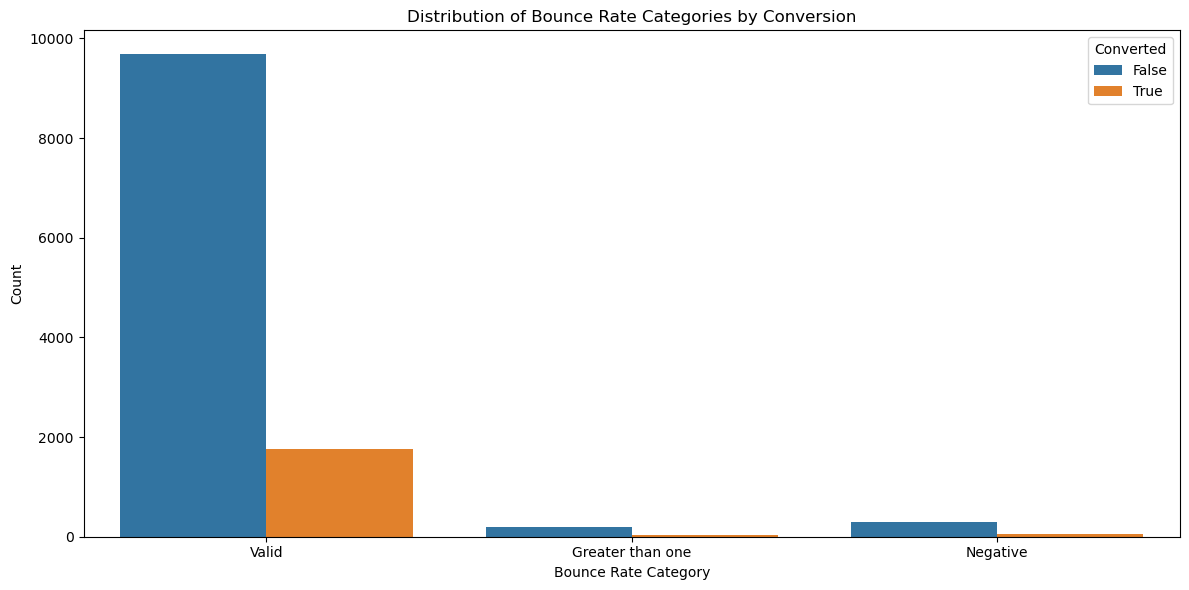

In [337]:
# Create a new dataframe with the feature engineering applied
session_data_bounce_rate_feature_df = session_data_df.copy()

# Create the 'BounceRateType' feature based on the specified categories
def categorize_bounce_rate(value):
    if value < 0:
        return 'Negative'
    elif value > 1:
        return 'Greater than one'
    else:
        return 'Valid'

# Apply the categorization function to create the new feature
session_data_bounce_rate_feature_df['BounceRateType'] = session_data_bounce_rate_feature_df['BounceRates'].apply(categorize_bounce_rate)

# Create a visualization of the distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=session_data_bounce_rate_feature_df, x='BounceRateType', hue='Revenue')
plt.title('Distribution of Bounce Rate Categories by Conversion')
plt.xlabel('Bounce Rate Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Converted')
plt.tight_layout()
plt.show()

In [338]:
# Just as we created dfs with dropped nans from our "base" dataset:
# Lets do the same with our df with the Bounce Rate type feature
session_data_bounce_rate_feature_df.dropna(subset='Revenue', inplace=True)

# Lets do the same for our bounce rate feature df
session_data_bounce_rate_feature_nans_replaced_with_zero_df = session_data_bounce_rate_feature_df.fillna(replace_nans_dict)
any_columns_with_nans_left = {key : value for key, value in session_data_bounce_rate_feature_nans_replaced_with_zero_df.isna().sum().to_dict().items() if value != 0}

if len(any_columns_with_nans_left) == 0:
    print('All nans have been replaced')
else:
    print(any_columns_with_nans_left)

# Lets do the same for our bounce rate feature df
session_data_bounce_rate_feature_nan_rows_dropped_df = session_data_bounce_rate_feature_df.dropna()

any_columns_with_nans_left = {key : value for key, value in session_data_bounce_rate_feature_nan_rows_dropped_df.isna().sum().to_dict().items() if value != 0}

if len(any_columns_with_nans_left) == 0:
    print('All nans have been replaced')
else:
    print(any_columns_with_nans_left)

{'SpecialDay': 117}
All nans have been replaced


Just a small reminder of which dfs we have now created and put them in a list for later.

In [339]:
# Create a list of tuples containing both the name of the df, and the df itself. We will use the name later in visualisations.
dfs_to_be_used_for_training_list_with_names = [
    ("session_data_bounce_rate_feature_nan_rows_dropped_df", session_data_bounce_rate_feature_nan_rows_dropped_df),
    ("session_data_bounce_rate_feature_nans_replaced_with_zero_df", session_data_bounce_rate_feature_nans_replaced_with_zero_df),
    ("session_data_nan_rows_dropped_df", session_data_nan_rows_dropped_df),
    ("session_data_nans_replaced_with_zero_df", session_data_nans_replaced_with_zero_df),
]
print(f"We have {len(dfs_to_be_used_for_training_list_with_names)} dfs to use for training so far")

# Extract the names of the dfs and save in a list for visualisation later
names_of_dfs_to_be_used_for_training = [name for name, df in dfs_to_be_used_for_training_list_with_names]
# Extract the dfs themselves and save in a list for later use.
dfs_to_be_used_for_training = [df for name, df in dfs_to_be_used_for_training_list_with_names]

# Later on in the code we will get warnings about us *maybe* using views instead of copies, so lets make explicit copies in order to avoid cluttering our notebook with warnings.
dfs_to_be_used_for_training = [df.copy() for df in dfs_to_be_used_for_training]

# Convert all dfs target column into ints for easiter handling later
for df in dfs_to_be_used_for_training:

    df['Revenue'] = df['Revenue'].astype(int)

We have 4 dfs to use for training so far


# Time to start pumping models . . . 

Our training pipeline and strategy:

Our data is imbalanced, has missing values, and invalid bonce rates.

During our EDA we have so far created dataframes that we will use for training and evaluate which one creates the best performance.
We will use the dataframes in combinations with various classifer models that have been used during our Machine Learning course of 2025 and other techniques for dealing with missing values and imbalanced data.

The five models we will use are all from SKLearn:
1. LogisticRegression
2. DecisionTreeClassifier
3. RandomForestClassifier
4. AdaBoostClassifier
5. KNeighborsClassifier

Our evaluation metrics will be:
1. Accuracy
2. Precision
3. Recall
4. Model prediction speed. The final model will be used in real time in a ecommerce production environment in order to predict if users will convert or not. So the model has to be rapid!
IMPORTANT: We will in no part of the evaluation process consider F1. We want to capture as many converting users as possible, as fast as possible. So we will optimise for recall and latency. As a back up, in case this becomes relevant after talking to domain experts, we will also track Precision. In order to achieve this we will calcute a *F1-style* score that weights both Recall/Precision with latency.

Regarding speed: For each candidate model we record median prediction latency (milliseconds per sample).

Our visualision techniques for each model will be:
1. Printed summaries of each evaluation metric
2. Confusion matrices
3. A HTML Display of a dataframe with all the relevant results from the training.

We need do deal with the missing values and bounce rates by:
1. Using the dataframes where we replaced all missing values with 0.
2. Using the dataframes where we dropped all rows with missing values.
3. Use KNNImputer to replace missing values in the feauture 'SpecialDay'
These will be our baselines.

We will perform a train/test split on each of the dataframes and then perform 
1. One-Hot Encoding on categorical features; VisitorType, Weekend and, where applicable, Bounce Rate type, and drop the first of each in order to keep the number of columns as low as possible. Let's use ColumnTransformer for this.
2. Feature Scaling on numerical features; Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues. Lets use StandardScaler.

Train a RandomForestClassifier on each of our different train/test sets.
For each of the four sets we will use the evaluation metrics outlined above and visualise them according to the visualisation techniques mentiond above. As we have an imbalanced dataset, lets use StratifiedKFold.
We will choose the two best performers (one focusing on Recall-Latency and one on Precision-Latency) and then use these two sets for the rest of our training and evaluation.

After each of the preprocessing pipelines we log a dataset profile consisting of
• row count (n_samples) and
• minority‑class share (positive_ratio = y.sum()/n_samples).
These numbers are derived with Counter(y) immediately after the train/test split and are persisted to our results DataFrame.
The snapshot tells us how severe class imbalance remains in each variant and guides the choice of resampling: pipelines whose positive ratio ≥ 0.35 may skip heavy oversampling, while those below that threshold proceed to the under/over/SMOTE experiment.

For each of the two chosen sets we need to deal with the imbalance by testing these three approaches from IMBLearn for each set. 
1. Subsampling
2. Oversamplig
3. SMOTE, Synthetic Minority Oversampling Technique
As we have an imbalanced dataset, lets use StratifiedKFold for each fold.

Train a RandomForestClassifier on each of our six sets of preprocessing strategy/imbalance strategy combinations.
For each of the sets we will use the evaluation metrics outlined above and visualise them according to the visualisation techniques mentiond above.
We will choose the two best performers (one focusing on Recall-Latency and one on Precision-Latency) and then use these two sets for the rest of our training and evaluation.

When we train on data that has already been balanced through undersampling, oversampling or SMOTE, we fix class_weight=None in every estimator grid.
This avoids double‑counting the minority class: the resampling step has equalised the class distribution, so letting the model apply an additional weighting would skew the decision boundary.

For each of the two best combinations of preprocessing + imbalance strategy we will:
1. Use GridSearchCV with different params for each of the different Classifier models we will use. So 2 x 5 (15) models. As we have an imbalanced dataset, lets use StratifiedKFold.
2. In each GridsearchCV the parameters will be:
    1. estimator will be one of the five classifier models
    2. param_grid will be a variety of params suitable for each model
    3. cv will be 3 - for this type of prediction 3 folds will be plenty
    4. n_jobs will be -1 - the dataset is so small we dont need to be conservative with resources
    5. verbose will be 2
    6. scoring will be Accuracy, Recall and Precision
3. When each of the grid searches have been run the results of each shall be visualised according to the visualisation instructions above. We should store all the results in a dict which we turn into a dataframe for easy visualisation and analysis.

We will for each of the models do the following error analysis:
1. Identify and analyze misclassified samples from best-performing model
2. Group errors by type (false positives vs. false negatives)
3. Recall-Latency Trade-off in the form of a graph for all models.
4. Precision-Latency Trade-off in the form of a graph for all models.

# FUNCTIONS FOR TRAINING AND EVALUATION

In [340]:
def prepare_dataset_for_training(df):
    """
    Prepares a dataset for training by separating features and target.
    
    Parameters:
    df (pandas.DataFrame): Input DataFrame
    
    Returns:
    X (pandas.DataFrame): Features
    y (pandas.Series): Target
    """
    
    # Define X and y
    X = df.drop(columns=['Revenue'])
    y = df['Revenue']
    
    return X, y

# Define column groups as specified in the strategy
numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates",
    "PageValues", "SpecialDay"
]

categorical_cols = [
    "Month", "Weekend",
    "OperatingSystems", "Browser", "Region",
    "TrafficType", "VisitorType"
]

In [341]:
def create_preprocessing_pipeline(numeric_columns, categorical_columns, bounce_rate_type_columns=None):
    """
    Creates a preprocessing pipeline based on specified column types
    
    Parameters:
    numeric_columns (list): List of numeric column names
    categorical_columns (list): List of categorical column names
    bounce_rate_type_columns (list, optional): List of bounce rate type column names
    
    Returns:
    sklearn.compose.ColumnTransformer: Preprocessing pipeline
    """
    transformers = [
        ("num_impute_scale", Pipeline(
            [('impute', KNNImputer()),
            ("scale", StandardScaler())]
        ), numeric_columns),
        ("cat_onehot", OneHotEncoder(drop="first", handle_unknown='infrequent_if_exist', min_frequency=1), categorical_columns)
    ]
    
    # Add bounce rate type columns to transformers if they exist
    if bounce_rate_type_columns and len(bounce_rate_type_columns) > 0:
        transformers.append(
            ("bounce_rate_onehot", OneHotEncoder(drop="first", handle_unknown='infrequent_if_exist', min_frequency=1), bounce_rate_type_columns)
        )
    
    return ColumnTransformer(transformers=transformers)

In [342]:
def evaluate_model_performance(model, X_test, y_test, model_name, dataset_name, 
                              resampling_method=None, param_grid=None, latency=None):
    """
    Evaluates model performance and returns results dictionary
    
    Parameters:
    model: Trained model
    X_test: Test features
    y_test: Test target
    model_name: Name of the model
    dataset_name: Name of the dataset used
    resampling_method: Method used for addressing class imbalance (if any)
    param_grid: Parameter grid used for hyperparameter tuning (if any)
    latency: Model prediction latency (if measured)
    
    Returns:
    dict: Performance metrics
    """
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Create results dictionary
    results = {
        'model_name': model_name,
        'dataset': dataset_name,
        'resampling': resampling_method if resampling_method else 'None',
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'latency_ms': latency,
        'param_grid': param_grid
    }
    
    # Print results
    print(f"\nResults for {model_name} on {dataset_name} dataset:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    if latency:
        print(f"Latency: {latency:.6f} ms/sample")
    
    # Create and display confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name} on {dataset_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return results

In [343]:
def measure_model_latency(model, X_val):
    """
    Measures model prediction latency on a validation batch
    
    Parameters:
    model: Trained model
    X_val: Validation features
    
    Returns:
    float: Median prediction latency in milliseconds per sample
    """
    # Use at minimum 1000 samples for latency testing
    n_samples = min(1000, X_val.shape[0])
    X_sample = X_val[:n_samples]
    
    # Measure latency
    latencies = []
    for _ in range(5):  # Run multiple times for stability
        start_time = time.perf_counter()
        model.predict(X_sample)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000 / n_samples)  # ms per sample
    
    return np.median(latencies)

In [344]:
def profile_dataset(X, y):
    """
    Profiles a dataset and returns basic statistics that will used to determine how to deal with imbalanaced data.
    
    Parameters:
    X: Features
    y: Target variable
    
    Returns:
    dict: Dataset profile
    """
    n_samples = len(y)
    positive_count = np.sum(y == True)
    positive_ratio = positive_count / n_samples
    
    profile = {
        'n_samples': n_samples,
        'positive_count': positive_count,
        'positive_ratio': positive_ratio
    }
    
    print(f"Dataset Profile:")
    print(f"Total samples: {n_samples}")
    print(f"Positive samples: {positive_count} ({positive_ratio:.2%})")
    
    return profile

In [345]:
def compute_latency_scores(results_df):
    """
    Adds recall_latency_score and precision_latency_score to the results DataFrame.
    Also prints a summary view of key metrics.
    """
    scaler = MinMaxScaler()
    norm_data = scaler.fit_transform(results_df[['recall', 'precision', 'latency_ms']])
    
    results_df['recall_norm'] = norm_data[:, 0]
    results_df['precision_norm'] = norm_data[:, 1]
    results_df['latency_norm'] = norm_data[:, 2]
    
    # Invert latency so lower is better
    results_df['latency_inv_norm'] = 1 - results_df['latency_norm']
    
    # F1-style harmonic means
    results_df['recall_latency_score'] = 2 * (
        (results_df['recall_norm'] * results_df['latency_inv_norm']) /
        (results_df['recall_norm'] + results_df['latency_inv_norm'] + 1e-6)
    )
    
    results_df['precision_latency_score'] = 2 * (
        (results_df['precision_norm'] * results_df['latency_inv_norm']) /
        (results_df['precision_norm'] + results_df['latency_inv_norm'] + 1e-6)
    )

    # 📊 Print visual summary like in train_baseline_models
    print("\n" + "="*80)
    print("RECALL-LATENCY & PRECISION-LATENCY SUMMARY")
    print("="*80)
    display(results_df[['dataset', 'accuracy', 'precision', 'recall', 'latency_ms',
                        'recall_latency_score', 'precision_latency_score']])
    
    return results_df


In [346]:
def train_baseline_models(datasets, dataset_names):
    """
    Trains baseline models on multiple datasets and compares performance
    
    Parameters:
    datasets (list): List of DataFrames
    dataset_names (list): Names of datasets
    
    Returns:
    pandas.DataFrame: Results of all baseline models
    """
    results = []
    
    for df, name in zip(datasets, dataset_names):
        print(f"\n{'='*50}\nTraining baseline model on {name}\n{'='*50}")
        
        # Prepare dataset
        X, y = prepare_dataset_for_training(df)
        
        # Profile dataset
        profile = profile_dataset(X, y)
        
        # Check if this dataset has the 'Bounce Rate type' column
        bounce_rate_cols = ['Bounce Rate type'] if 'Bounce Rate type' in X.columns else []
        if bounce_rate_cols:
            print("This dataset includes the 'Bounce Rate type' feature")
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        # Create preprocessing pipeline
        preproc = create_preprocessing_pipeline(numeric_cols, categorical_cols, bounce_rate_cols)
        
        # Create and train baseline model
        baseline_model = Pipeline([
            ("prep", preproc),
            ("clf", RandomForestClassifier(random_state=42))
        ])
        
        def print_unknown_categories(preprocessor, X_train, X_test, categorical_cols):
            print("\n🕵️‍♂️ Diagnostic: Unknown Categories Check")
            ohe = preprocessor.named_transformers_["cat_onehot"]
            known_categories = ohe.categories_  # list of arrays, one per cat column

            for idx, col in enumerate(categorical_cols):
                train_cats = set(known_categories[idx])
                test_cats = set(X_test[col].unique())
                unseen_cats = test_cats - train_cats

                if unseen_cats:
                    print(f"⚠️ Column '{col}' has unseen test categories: {unseen_cats}")
                else:
                    print(f"✅ Column '{col}' has no unseen categories.")

            print("Done.\n")


        print("Training baseline model...")
        baseline_model.fit(X_train, y_train)
        
        print_unknown_categories(preproc, X_train, X_test, categorical_cols)
        print(X_train["TrafficType"].value_counts().sort_index())

        # Measure latency
        latency = measure_model_latency(baseline_model, X_test)
        
        # Evaluate model
        result = evaluate_model_performance(
            baseline_model, X_test, y_test, 
            "RandomForest_Baseline", name, 
            latency=latency
        )
        
        # Add profile information to results
        result.update(profile)
        results.append(result)
        
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Print summary
    print("\n" + "="*80)
    print("BASELINE MODELS SUMMARY")
    print("="*80)
    display(results_df[['dataset', 'accuracy', 'precision', 'recall', 'latency_ms', 'positive_ratio']])
    
    return results_df

In [347]:
def handle_imbalance(X_train, y_train, method):
    """
    Applies specified resampling method to handle class imbalance
    
    Parameters:
    X_train: Training features
    y_train: Training target
    method: Resampling method ('undersample', 'oversample', or 'smote')
    
    Returns:
    tuple: Resampled X_train and y_train
    """
    if method == 'undersample':
        resampler = RandomUnderSampler(random_state=42)
    elif method == 'oversample':
        resampler = RandomOverSampler(random_state=42)
    elif method == 'smote':
        resampler = SMOTE(random_state=42)
    else:
        raise ValueError(f"Unknown resampling method: {method}")
    
    X_resampled, y_resampled = resampler.fit_resample(X_train, y_train)
    
    # Print resampling statistics
    original_counts = Counter(y_train)
    resampled_counts = Counter(y_resampled)
    
    print(f"\nResampling using {method}:")
    print(f"Original class distribution: {dict(original_counts)}")
    print(f"Resampled class distribution: {dict(resampled_counts)}")
    print(f"Original samples: {len(y_train)}, Resampled samples: {len(y_resampled)}")
    
    return X_resampled, y_resampled

In [348]:
def train_imbalanced_models(datasets, dataset_names):
    """
    Trains models with different imbalance handling methods on specified datasets
    
    Parameters:
    datasets (list): List of DataFrames
    dataset_names (list): Names of datasets
    
    Returns:
    pandas.DataFrame: Results of all models
    """
    results = []
    
    for df, name in zip(datasets, dataset_names):
        print(f"\n{'='*50}\nTraining models with resampling on {name}\n{'='*50}")
        
        # Prepare dataset
        X, y = prepare_dataset_for_training(df)
        
        # Profile dataset
        profile = profile_dataset(X, y)
        positive_ratio = profile['positive_ratio']
        
        # Check if this dataset has the 'Bounce Rate type' column
        bounce_rate_cols = ['BounceRateType'] if 'BounceRate Type' in X.columns else []
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        # Create preprocessing pipeline
        preproc = create_preprocessing_pipeline(numeric_cols, categorical_cols, bounce_rate_cols)
        
        # Apply preprocessing to training data
        X_train_processed = preproc.fit_transform(X_train)

        def print_unknown_categories(preprocessor, X_train, X_test, categorical_cols):
            print("\n🕵️‍♂️ Diagnostic: Unknown Categories Check")
            ohe = preprocessor.named_transformers_["cat_onehot"]
            known_categories = ohe.categories_  # list of arrays, one per cat column

            for idx, col in enumerate(categorical_cols):
                train_cats = set(known_categories[idx])
                test_cats = set(X_test[col].unique())
                unseen_cats = test_cats - train_cats

                if unseen_cats:
                    print(f"⚠️ Column '{col}' has unseen test categories: {unseen_cats}")
                else:
                    print(f"✅ Column '{col}' has no unseen categories.")

            print("Done.\n")
        
        # Determine which resampling methods to use based on positive_ratio
        if positive_ratio >= 0.35:
            # Less severe imbalance, skip heavy oversampling
            resampling_methods = ['undersample', 'oversample']
            print(f"Positive ratio ({positive_ratio:.2f}) >= 0.35, skipping SMOTE")
        else:
            # More severe imbalance, use all methods including SMOTE
            resampling_methods = ['undersample', 'oversample', 'smote']
            print(f"Positive ratio ({positive_ratio:.2f}) < 0.35, including SMOTE")
        
        # For each resampling method
        for method in resampling_methods:
            print(f"\n{'-'*40}\nResampling method: {method}\n{'-'*40}")
            
            # Apply resampling
            X_resampled, y_resampled = handle_imbalance(X_train_processed, y_train, method)
            
            # Create and train model
            clf = RandomForestClassifier(random_state=42, class_weight=None)
            clf.fit(X_resampled, y_resampled)
            
            # Create a complete pipeline for test set transformation
            complete_pipeline = Pipeline([
                ("prep", preproc),
                ("clf", clf)
            ])
            
            print_unknown_categories(preproc, X_train, X_test, categorical_cols)
            print(X_train["TrafficType"].value_counts().sort_index())

            # For latency measurement, we need the complete pipeline
            latency = measure_model_latency(complete_pipeline, X_test)
            
            # For evaluation, use the already-fitted preprocessing transformer
            X_test_processed = preproc.transform(X_test)
            
            # Evaluate model
            result = evaluate_model_performance(
                clf, X_test_processed, y_test, 
                f"RandomForest_{method}", name, 
                resampling_method=method,
                latency=latency
            )
            
            results.append(result)
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Print summary
    print("\n" + "="*80)
    print("IMBALANCE HANDLING MODELS SUMMARY")
    print("="*80)
    display(results_df[['model_name', 'dataset', 'resampling', 'accuracy', 'precision', 'recall', 'latency_ms']])
    
    return results_df

In [349]:
def run_grid_search(datasets, dataset_names, resampling_methods):
    """
    Runs grid search with different models on specified dataset and resampling combinations
    
    Parameters:
    datasets (list): List of DataFrames
    dataset_names (list): Names of datasets
    resampling_methods (list): Resampling methods to use for each dataset
    
    Returns:
    pandas.DataFrame: Results of all grid searches
    """
    # Define parameter grids for each model
    param_grids = {
        'LogisticRegression': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'max_iter': [2000, 5000, 10000],
            'class_weight': [None]
        },
        'DecisionTreeClassifier': {
            'max_depth': [None, 5, 10, 15, 20],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'criterion': ['gini', 'entropy'],
            'class_weight': [None]
        },
        'RandomForestClassifier': {
            'n_estimators': [5, 10, 20],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False],
            'class_weight': [None]
        },
        'AdaBoostClassifier': {
            'n_estimators': [5, 10, 20],
            'learning_rate': [0.01, 0.1, 1.0],
            'estimator': [
                DecisionTreeClassifier(max_depth=1, random_state=42),
                DecisionTreeClassifier(max_depth=2, random_state=42)
            ]
        },
        'KNeighborsClassifier': {
            'n_neighbors': [3, 5, 7, 11],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        }
    }
    
    # Define models
    models = {
        'LogisticRegression': LogisticRegression(random_state=42),
        'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
        'RandomForestClassifier': RandomForestClassifier(random_state=42),
        'AdaBoostClassifier': AdaBoostClassifier(random_state=42),
        'KNeighborsClassifier': KNeighborsClassifier()
    }
    
    # Initialize results
    all_results = []
    
    # For each dataset and resampling method combination
    for df, dataset_name, resampling_method in zip(datasets, dataset_names, resampling_methods):
        print(f"\n{'='*60}")
        print(f"Dataset: {dataset_name}, Resampling: {resampling_method}")
        print(f"{'='*60}")
        
        # Prepare dataset
        X, y = prepare_dataset_for_training(df)
        
        # Check if this dataset has the 'Bounce Rate type' column
        bounce_rate_cols = ['Bounce Rate type'] if 'Bounce Rate type' in X.columns else []
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        # Create preprocessing pipeline
        preproc = create_preprocessing_pipeline(numeric_cols, categorical_cols, bounce_rate_cols)
        
        # Apply preprocessing to training data
        X_train_processed = preproc.fit_transform(X_train)
        
        # Apply resampling if specified
        if resampling_method != 'None':
            X_train_processed, y_train = handle_imbalance(X_train_processed, y_train, resampling_method)
        
        # Apply preprocessing to test data
        X_test_processed = preproc.transform(X_test)
        
        # For each model
        for model_name, model in models.items():
            print(f"\n{'-'*40}")
            print(f"Model: {model_name}")
            print(f"{'-'*40}")
            
            # Define scoring metrics
            scoring = {
                'accuracy': 'accuracy',
                'precision': 'precision',
                'recall': 'recall'
            }
            
            # Set up cross-validation
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            
            # Create grid search
            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grids[model_name],
                scoring=scoring,
                refit='recall',  # Refit on recall as we are prioritising recall
                cv=cv,
                verbose=1,
                n_jobs=-1
            )
            
            # Fit grid search
            print(f"Running grid search for {model_name}...")
            grid_search.fit(X_train_processed, y_train)
            
            # Get best model
            best_model = grid_search.best_estimator_
            
            # Measure latency
            latency = measure_model_latency(best_model, X_test_processed)
            
            # Evaluate best model
            result = evaluate_model_performance(
                best_model, X_test_processed, y_test,
                model_name, dataset_name,
                resampling_method=resampling_method,
                param_grid=grid_search.best_params_,
                latency=latency
            )
            
            # Add cross-validation results
            result.update({
                'cv_accuracy': grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_],
                'cv_precision': grid_search.cv_results_['mean_test_precision'][grid_search.best_index_],
                'cv_recall': grid_search.cv_results_['mean_test_recall'][grid_search.best_index_],
                'best_params': grid_search.best_params_,
                'fitted_model': best_model
            })
            
            all_results.append(result)
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Print summary
    print("\n" + "="*100)
    print("GRID SEARCH SUMMARY")
    print("="*100)
    display(results_df[['model_name', 'dataset', 'resampling', 'accuracy', 'precision', 'recall', 'latency_ms', 'best_params']])
    
    return results_df

In [350]:
def perform_error_analysis(
    best_model_instance,
    model_name,
    dataset_name,
    resampling_method,
    recall=None,
    precision=None,
    latency_ms=None,
    recall_latency_score=None,
    precision_latency_score=None
):
    """
    Perform error analysis using a pre-trained model and external metrics for display.
    """
    print(f"\n{'='*80}")
    print(f"ERROR ANALYSIS FOR: {model_name}")
    print(f"Dataset: {dataset_name} | Resampling: {resampling_method}")
    print(f"{'='*80}")
    
    # Find dataset
    df = None
    for d, name in zip(dfs_to_be_used_for_training, names_of_dfs_to_be_used_for_training):
        if name == dataset_name:
            df = d
            break
    if df is None:
        print("⚠️ Dataset not found.")
        return None

    # Prepare and split dataset
    X, y = prepare_dataset_for_training(df)
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    # Preprocessing pipeline (same as used during training)
    bounce_rate_cols = ['Bounce Rate type'] if 'Bounce Rate type' in X.columns else []
    preproc = create_preprocessing_pipeline(numeric_cols, categorical_cols, bounce_rate_cols)
    preproc.fit(X_train)
    X_test_processed = preproc.transform(X_test)

    # Predict
    y_pred = best_model_instance.predict(X_test_processed)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    # Error stats
    total = len(y_test)
    misclassified = (y_test != y_pred).sum()
    error_rate = misclassified / total
    false_positives = ((y_test == 0) & (y_pred == 1)).sum()
    false_negatives = ((y_test == 1) & (y_pred == 0)).sum()

    # Summary
    print("\nSummary:")
    print(f"Total samples:        {total}")
    print(f"Misclassified count:  {misclassified}")
    print(f"Error rate:           {error_rate:.2%}")
    print(f"False Positives:      {false_positives}")
    print(f"False Negatives:      {false_negatives}")

    # Feature importance (if available)
    if hasattr(best_model_instance, "feature_importances_"):
        print("\nFeature Importances (for models that support it):")
        importances = best_model_instance.feature_importances_

        # Get feature names from the preprocessor
        onehot_feature_names = preproc.named_transformers_["cat_onehot"].get_feature_names_out(categorical_cols)
        all_feature_names = numeric_cols + list(onehot_feature_names)

        # Match lengths safely
        if len(importances) == len(all_feature_names):
            sorted_idx = np.argsort(importances)[::-1]
            plt.figure(figsize=(10, 6))
            plt.bar(range(len(importances)), importances[sorted_idx])
            plt.xticks(range(len(importances)), np.array(all_feature_names)[sorted_idx], rotation=90)
            plt.title("Feature Importances - {}".format(model_name))
            plt.tight_layout()
            plt.show()
        else:
            print("⚠️ Could not plot feature importances due to mismatch in feature name lengths.")
    else:
        print("ℹ️ This model does not support feature importances.")

    return {
            'Model': model_name,
            'Dataset': dataset_name,
            'Resampling': resampling_method,
            'Total Samples': total,
            'Misclassified Count': misclassified,
            'Error Rate': error_rate,
            'False Positives': false_positives,
            'False Negatives': false_negatives,
            'Recall': recall,
            'Precision': precision,
            'Latency (ms/sample)': latency_ms,
            'Recall-Latency Score': recall_latency_score,
            'Precision-Latency Score': precision_latency_score,
            'Confusion Matrix': cm
        }

In [351]:
def create_final_visualization(baseline_results, imbalance_results, grid_search_results):
    """
    Creates a comprehensive dashboard visualizing model performance using 
    recall-latency *and* precision-latency scores.
    """

    def compute_scores(df):
        scaler = MinMaxScaler()
        df[['recall_norm', 'latency_norm', 'precision_norm']] = scaler.fit_transform(
            df[['recall', 'latency_ms', 'precision']]
        )
        df['latency_inv_norm'] = 1 - df['latency_norm']
        
        df['recall_latency_score'] = 2 * (
            (df['recall_norm'] * df['latency_inv_norm']) / 
            (df['recall_norm'] + df['latency_inv_norm'] + 1e-6)
        )
        df['precision_latency_score'] = 2 * (
            (df['precision_norm'] * df['latency_inv_norm']) / 
            (df['precision_norm'] + df['latency_inv_norm'] + 1e-6)
        )
        return df

    # Apply to all result sets
    baseline_results = compute_scores(baseline_results)
    imbalance_results = compute_scores(imbalance_results)
    grid_search_results = compute_scores(grid_search_results)

    plt.figure(figsize=(20, 14))

    # Recall-Latency Comparison
    plt.subplot(2, 2, 1)
    top_models = grid_search_results.sort_values('recall_latency_score', ascending=False)
    top_per_model = top_models.groupby('model_name', as_index=False).first()
    sns.barplot(x='model_name', y='recall_latency_score', data=top_per_model, errorbar=None)
    plt.title('Recall-Latency Score by Model')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)

    # Precision-Latency Comparison
    plt.subplot(2, 2, 2)
    top_models_prec = grid_search_results.sort_values('precision_latency_score', ascending=False)
    top_per_model_prec = top_models_prec.groupby('model_name', as_index=False).first()
    sns.barplot(x='model_name', y='precision_latency_score', data=top_per_model_prec, errorbar=None)
    plt.title('Precision-Latency Score by Model')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)

    # Latency of Top Models (Recall-Focused)
    plt.subplot(2, 2, 3)
    top_models = (
    grid_search_results.sort_values('recall_latency_score', ascending=False)
    .groupby('model_name', as_index=False).first()
    .sort_values('recall_latency_score', ascending=False)
    .head(5)
    )
    sns.barplot(x='model_name', y='latency_ms', data=top_models, errorbar=None)
    plt.title('Latency of Top 5 Models by Recall-Latency Score')
    plt.xticks(rotation=45)

    # Latency of Top Models (Precision-Focused)
    plt.subplot(2, 2, 4)
    top_models_prec = (
    grid_search_results.sort_values('precision_latency_score', ascending=False)
    .groupby('model_name', as_index=False).first()
    .sort_values('precision_latency_score', ascending=False)
    .head(5)
    )
    sns.barplot(x='model_name', y='latency_ms', data=top_models_prec, errorbar=None)
    plt.title('Latency of Top 5 Models by Precision-Latency Score')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Scatter Plot: Recall vs Latency
    plt.figure(figsize=(10, 8))
    plt.scatter(grid_search_results['latency_ms'], grid_search_results['recall'], 
                s=100, c=grid_search_results['recall_latency_score'], cmap='plasma', alpha=0.7)
    for i, row in grid_search_results.iterrows():
        plt.annotate(row['model_name'], (row['latency_ms'], row['recall']), xytext=(5, 5), textcoords='offset points')
    plt.colorbar(label='Recall-Latency Score')
    plt.xlabel('Latency (ms/sample)')
    plt.ylabel('Recall')
    plt.title('Latency vs Recall')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


    # Scatter Plot: Precision vs Latency
    plt.figure(figsize=(10, 8))
    plt.scatter(grid_search_results['latency_ms'], grid_search_results['precision'], 
                s=100, c=grid_search_results['precision_latency_score'], cmap='viridis', alpha=0.7)
    for i, row in grid_search_results.iterrows():
        plt.annotate(row['model_name'], (row['latency_ms'], row['precision']), xytext=(5, 5), textcoords='offset points')
    plt.colorbar(label='Precision-Latency Score')
    plt.xlabel('Latency (ms/sample)')
    plt.ylabel('Precision')
    plt.title('Latency vs Precision')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


    # Display final comparison tables
    print("\nTOP 5 MODELS BY RECALL-LATENCY SCORE:")
    top_recall_table = pd.concat([
        baseline_results.assign(phase='Baseline'),
        imbalance_results.assign(phase='Imbalance Handling'),
        grid_search_results.assign(phase='Grid Search')
    ]).sort_values('recall_latency_score', ascending=False).head(5)

    display(top_recall_table[['model_name', 'dataset', 'resampling', 'accuracy', 'precision', 'recall', 'latency_ms', 'recall_latency_score', 'phase']])

    print("\nTOP 5 MODELS BY PRECISION-LATENCY SCORE:")
    top_precision_table = pd.concat([
        baseline_results.assign(phase='Baseline'),
        imbalance_results.assign(phase='Imbalance Handling'),
        grid_search_results.assign(phase='Grid Search')
    ]).sort_values('precision_latency_score', ascending=False).head(5)

    display(top_precision_table[['model_name', 'dataset', 'resampling', 'accuracy', 'precision', 'recall', 'latency_ms', 'precision_latency_score', 'phase']])


    # Extract best models
    best_recall_model = grid_search_results.loc[grid_search_results['recall_latency_score'].idxmax()]
    best_prec_model   = grid_search_results.loc[grid_search_results['precision_latency_score'].idxmax()]

    # Updated HTML with parameters included
    html = f"""
    <div style="background:#ffffff; padding: 20px; border-radius: 10px; font-family: Arial, sans-serif; color: #000000;">
        <h2 style="text-align:center;">⚔️ Final Battle of Models ⚔️</h2>

        <h3 style="color:#2980b9;">🏆 Best by Recall-Latency</h3>
        <ul>
            <li><b>Model:</b> {best_recall_model['model_name']}</li>
            <li><b>Dataset:</b> {best_recall_model['dataset']}</li>
            <li><b>Resampling:</b> {best_recall_model['resampling']}</li>
            <li><b>Recall:</b> {best_recall_model['recall']:.4f}</li>
            <li><b>Latency:</b> {best_recall_model['latency_ms']:.6f} ms/sample</li>
            <li><b>Score:</b> {best_recall_model['recall_latency_score']:.4f}</li>
            <li><b>Best Params:</b> {best_recall_model['best_params']}</li>
        </ul>

        <h3 style="color:#27ae60;">🏅 Best by Precision-Latency</h3>
        <ul>
            <li><b>Model:</b> {best_prec_model['model_name']}</li>
            <li><b>Dataset:</b> {best_prec_model['dataset']}</li>
            <li><b>Resampling:</b> {best_prec_model['resampling']}</li>
            <li><b>Precision:</b> {best_prec_model['precision']:.4f}</li>
            <li><b>Latency:</b> {best_prec_model['latency_ms']:.6f} ms/sample</li>
            <li><b>Score:</b> {best_prec_model['precision_latency_score']:.4f}</li>
            <li><b>Best Params:</b> {best_prec_model['best_params']}</li>
        </ul>
    </div>
    """
    display(HTML(html))


Training baseline model on session_data_bounce_rate_feature_nan_rows_dropped_df
Dataset Profile:
Total samples: 11510
Positive samples: 1783 (15.49%)
Training baseline model...

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
✅ Column 'TrafficType' has no unseen categories.
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1845
2     2896
3     1513
4      800
5      198
6      339
7       32
8      259
9       29
10     329
11     189
12       1
13     561
14      12
15      33
16       2
17       1
18       7
19      13
20     149
Name: count, dtype: int64

Results for RandomForest_Baseline on session_data_bounce_rate_feature_nan_rows_dropped_df dataset:
Accuracy: 0.9018
Precision: 0.7435
Recall: 0.5602
Latency: 0.052816 ms/sample


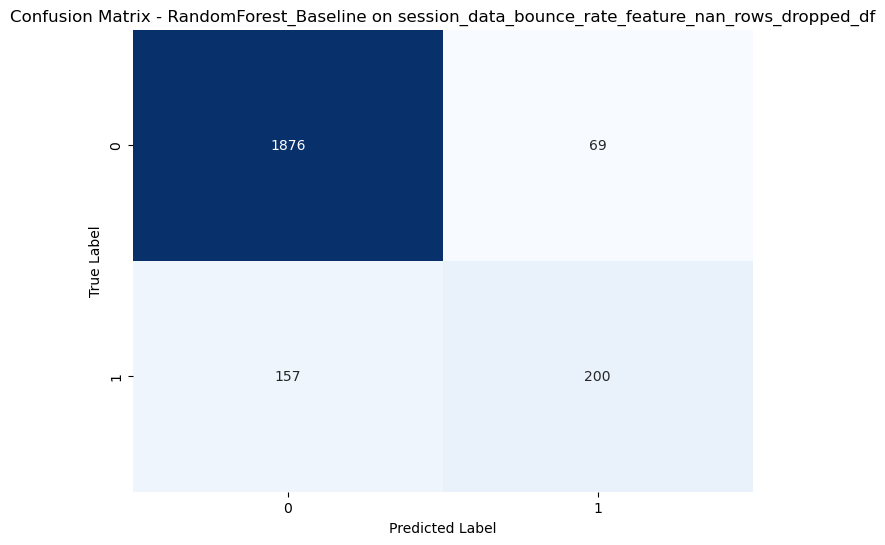


Training baseline model on session_data_bounce_rate_feature_nans_replaced_with_zero_df
Dataset Profile:
Total samples: 12042
Positive samples: 1862 (15.46%)
Training baseline model...

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
⚠️ Column 'TrafficType' has unseen test categories: {np.int64(12)}
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1931
2     3071
3     1585
4      831
5      208
6      345
7       30
8      262
9       31
10     348
11     199
13     568
14       9
15      32
16       3
17       1
18       8
19      12
20     159
Name: count, dtype: int64


c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as


Results for RandomForest_Baseline on session_data_bounce_rate_feature_nans_replaced_with_zero_df dataset:
Accuracy: 0.9008
Precision: 0.7454
Recall: 0.5430
Latency: 0.056450 ms/sample


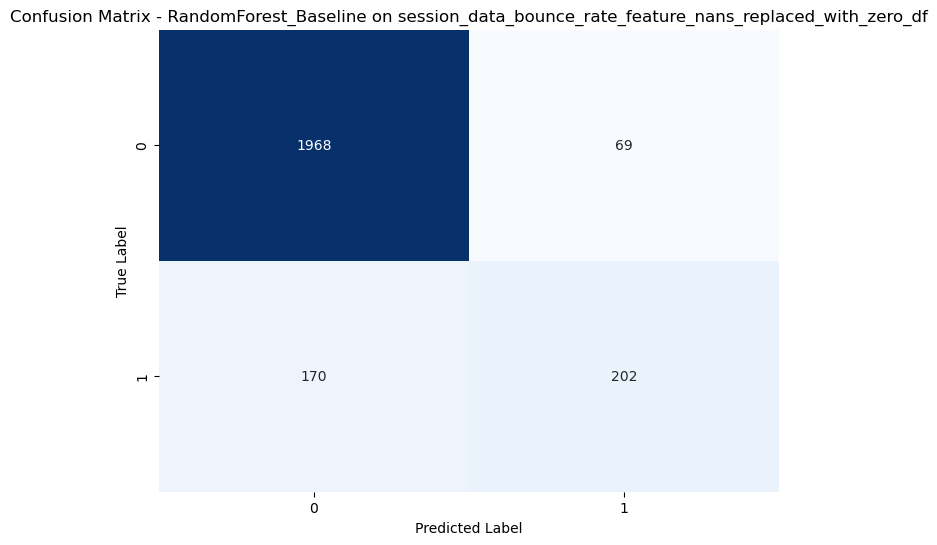


Training baseline model on session_data_nan_rows_dropped_df
Dataset Profile:
Total samples: 11510
Positive samples: 1783 (15.49%)
Training baseline model...

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
✅ Column 'TrafficType' has no unseen categories.
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1845
2     2896
3     1513
4      800
5      198
6      339
7       32
8      259
9       29
10     329
11     189
12       1
13     561
14      12
15      33
16       2
17       1
18       7
19      13
20     149
Name: count, dtype: int64

Results for RandomForest_Baseline on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.9018
Precision: 0.7435
Recall: 0.5602
Latency: 0.044929 ms/sample


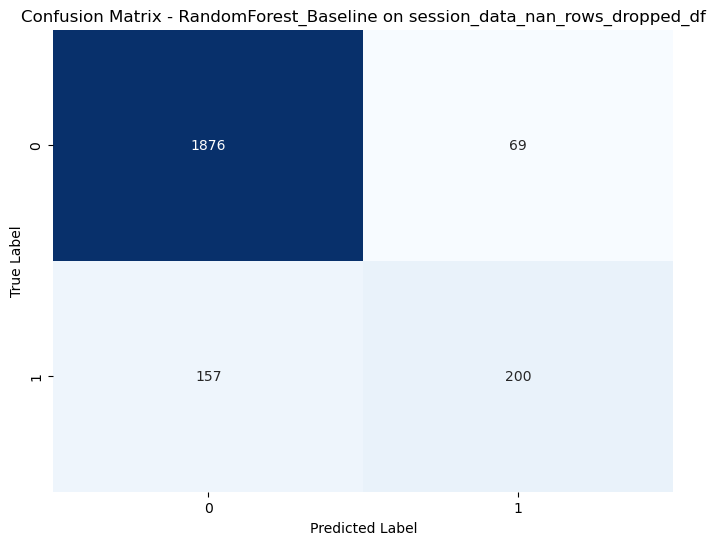


Training baseline model on session_data_nans_replaced_with_zero_df
Dataset Profile:
Total samples: 12042
Positive samples: 1862 (15.46%)
Training baseline model...

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
⚠️ Column 'TrafficType' has unseen test categories: {np.int64(12)}
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1931
2     3071
3     1585
4      831
5      208
6      345
7       30
8      262
9       31
10     348
11     199
13     568
14       9
15      32
16       3
17       1
18       8
19      12
20     159
Name: count, dtype: int64


c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as


Results for RandomForest_Baseline on session_data_nans_replaced_with_zero_df dataset:
Accuracy: 0.9008
Precision: 0.7454
Recall: 0.5430
Latency: 0.052793 ms/sample


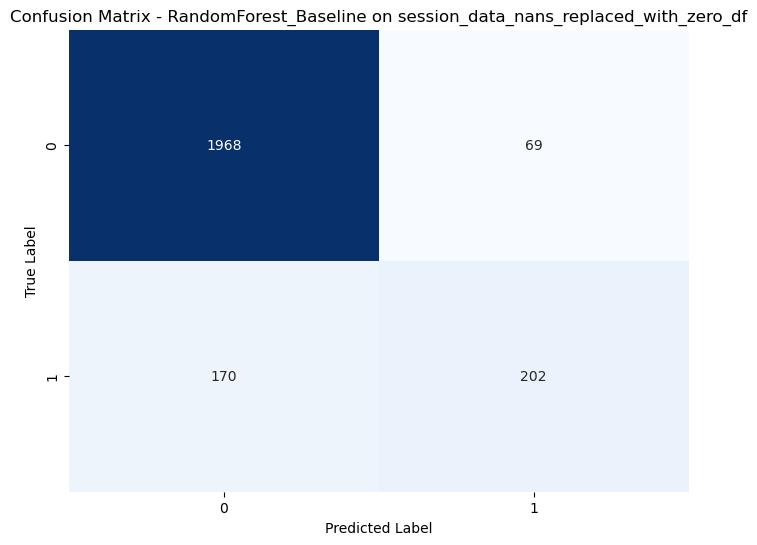


BASELINE MODELS SUMMARY


,dataset,accuracy,precision,recall,latency_ms,positive_ratio
0,session_data_bounce_rate_feature_nan_rows_drop...,0.901825,0.743494,0.560224,0.052816,0.154909
1,session_data_bounce_rate_feature_nans_replaced...,0.900789,0.745387,0.543011,0.056450,0.154625
2,session_data_nan_rows_dropped_df,0.901825,0.743494,0.560224,0.044929,0.154909
3,session_data_nans_replaced_with_zero_df,0.900789,0.745387,0.543011,0.052793,0.154625


In [352]:
# Train baseline models
baseline_results = train_baseline_models(
    dfs_to_be_used_for_training, 
    names_of_dfs_to_be_used_for_training
)

In [353]:
# Find best models for precision or recall + latency
baseline_results = compute_latency_scores(baseline_results)


RECALL-LATENCY & PRECISION-LATENCY SUMMARY


,dataset,accuracy,precision,recall,latency_ms,recall_latency_score,precision_latency_score
0,session_data_bounce_rate_feature_nan_rows_drop...,0.901825,0.743494,0.560224,0.052816,0.479497,0.000000e+00
1,session_data_bounce_rate_feature_nans_replaced...,0.900789,0.745387,0.543011,0.056450,-0.000000,-8.881775e-16
2,session_data_nan_rows_dropped_df,0.901825,0.743494,0.560224,0.044929,1.000000,0.000000e+00
3,session_data_nans_replaced_with_zero_df,0.900789,0.745387,0.543011,0.052793,0.000000,4.818813e-01


In [354]:
# Select top models by each score
top_recall_model = baseline_results.loc[baseline_results['recall_latency_score'].idxmax()]
top_precision_model = baseline_results.loc[baseline_results['precision_latency_score'].idxmax()]

# Combine and drop any duplicate if same model happens to top both
top_datasets = pd.concat([top_recall_model.to_frame().T, top_precision_model.to_frame().T]).drop_duplicates()

# Optional: tag type of selection
top_datasets['selection_type'] = ['recall_latency_top', 'precision_latency_top'][:len(top_datasets)]

# 🌟 Display the selected top datasets
print("\nTop datasets selected for further processing (one per score):")
display(top_datasets[['dataset', 'accuracy', 'precision', 'recall', 'latency_ms',
                      'recall_latency_score', 'precision_latency_score', 'selection_type']])

# 🧙‍♂️ Extract their names for next pipeline stage
top_dataset_names = top_datasets['dataset'].tolist()



Top datasets selected for further processing (one per score):


,dataset,accuracy,precision,recall,latency_ms,recall_latency_score,precision_latency_score,selection_type
2,session_data_nan_rows_dropped_df,0.901825,0.743494,0.560224,0.044929,1.0,0.0,recall_latency_top
3,session_data_nans_replaced_with_zero_df,0.900789,0.745387,0.543011,0.052793,0.0,0.481881,precision_latency_top



Training models with resampling on session_data_nan_rows_dropped_df
Dataset Profile:
Total samples: 11510
Positive samples: 1783 (15.49%)
Positive ratio (0.15) < 0.35, including SMOTE

----------------------------------------
Resampling method: undersample
----------------------------------------

Resampling using undersample:
Original class distribution: {0: 7782, 1: 1426}
Resampled class distribution: {0: 1426, 1: 1426}
Original samples: 9208, Resampled samples: 2852

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
✅ Column 'TrafficType' has no unseen categories.
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1845
2     2896
3     1513
4      800
5      198
6      339
7       32
8      259
9       29
10     329
11     189
12       1
1

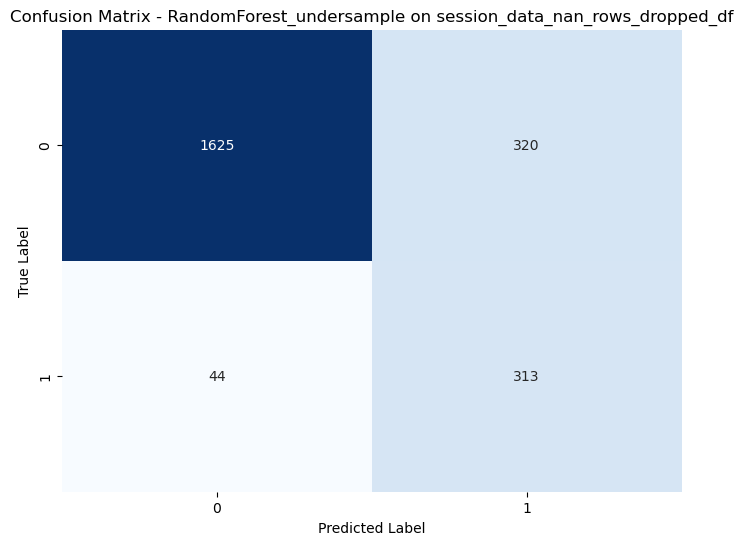


----------------------------------------
Resampling method: oversample
----------------------------------------

Resampling using oversample:
Original class distribution: {0: 7782, 1: 1426}
Resampled class distribution: {0: 7782, 1: 7782}
Original samples: 9208, Resampled samples: 15564

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
✅ Column 'TrafficType' has no unseen categories.
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1845
2     2896
3     1513
4      800
5      198
6      339
7       32
8      259
9       29
10     329
11     189
12       1
13     561
14      12
15      33
16       2
17       1
18       7
19      13
20     149
Name: count, dtype: int64

Results for RandomForest_oversample on session_data_nan_rows_dropped_df 

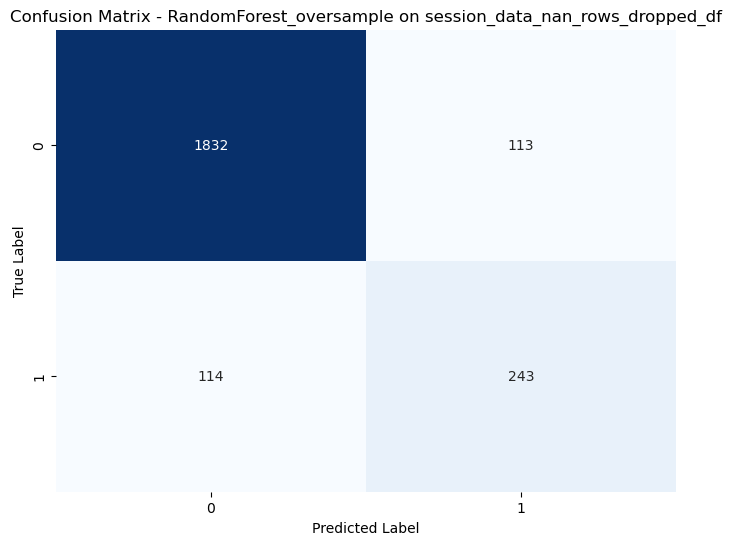


----------------------------------------
Resampling method: smote
----------------------------------------

Resampling using smote:
Original class distribution: {0: 7782, 1: 1426}
Resampled class distribution: {0: 7782, 1: 7782}
Original samples: 9208, Resampled samples: 15564

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
✅ Column 'TrafficType' has no unseen categories.
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1845
2     2896
3     1513
4      800
5      198
6      339
7       32
8      259
9       29
10     329
11     189
12       1
13     561
14      12
15      33
16       2
17       1
18       7
19      13
20     149
Name: count, dtype: int64

Results for RandomForest_smote on session_data_nan_rows_dropped_df dataset:
Accura

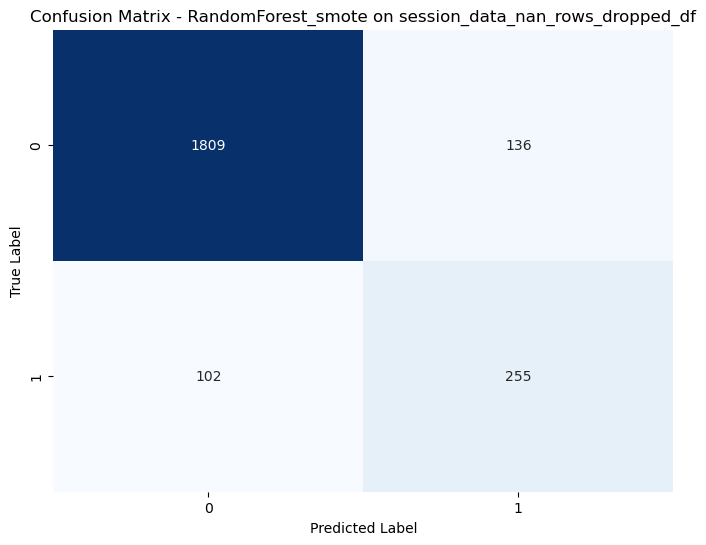


Training models with resampling on session_data_nans_replaced_with_zero_df
Dataset Profile:
Total samples: 12042
Positive samples: 1862 (15.46%)
Positive ratio (0.15) < 0.35, including SMOTE

----------------------------------------
Resampling method: undersample
----------------------------------------

Resampling using undersample:
Original class distribution: {0: 8143, 1: 1490}
Resampled class distribution: {0: 1490, 1: 1490}
Original samples: 9633, Resampled samples: 2980

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
⚠️ Column 'TrafficType' has unseen test categories: {np.int64(12)}
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1931
2     3071
3     1585
4      831
5      208
6      345
7       30
8      262
9       31
10     34

c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as


Results for RandomForest_undersample on session_data_nans_replaced_with_zero_df dataset:
Accuracy: 0.8485
Precision: 0.5054
Recall: 0.8737
Latency: 0.096357 ms/sample


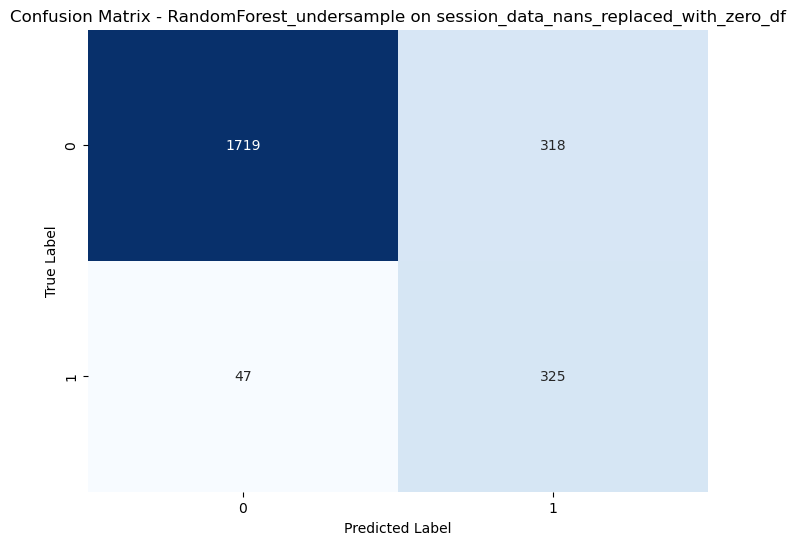


----------------------------------------
Resampling method: oversample
----------------------------------------

Resampling using oversample:
Original class distribution: {0: 8143, 1: 1490}
Resampled class distribution: {0: 8143, 1: 8143}
Original samples: 9633, Resampled samples: 16286

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
⚠️ Column 'TrafficType' has unseen test categories: {np.int64(12)}
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1931
2     3071
3     1585
4      831
5      208
6      345
7       30
8      262
9       31
10     348
11     199
13     568
14       9
15      32
16       3
17       1
18       8
19      12
20     159
Name: count, dtype: int64


c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as


Results for RandomForest_oversample on session_data_nans_replaced_with_zero_df dataset:
Accuracy: 0.9012
Precision: 0.6872
Recall: 0.6613
Latency: 0.063059 ms/sample


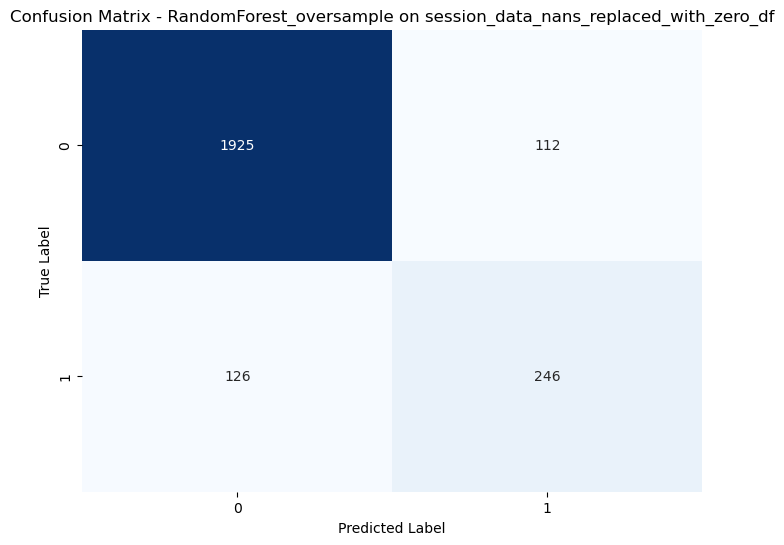


----------------------------------------
Resampling method: smote
----------------------------------------

Resampling using smote:
Original class distribution: {0: 8143, 1: 1490}
Resampled class distribution: {0: 8143, 1: 8143}
Original samples: 9633, Resampled samples: 16286

🕵️‍♂️ Diagnostic: Unknown Categories Check
✅ Column 'Month' has no unseen categories.
✅ Column 'Weekend' has no unseen categories.
✅ Column 'OperatingSystems' has no unseen categories.
✅ Column 'Browser' has no unseen categories.
✅ Column 'Region' has no unseen categories.
⚠️ Column 'TrafficType' has unseen test categories: {np.int64(12)}
✅ Column 'VisitorType' has no unseen categories.
Done.

TrafficType
1     1931
2     3071
3     1585
4      831
5      208
6      345
7       30
8      262
9       31
10     348
11     199
13     568
14       9
15      32
16       3
17       1
18       8
19      12
20     159
Name: count, dtype: int64


c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\SunnyVanderwall\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as


Results for RandomForest_smote on session_data_nans_replaced_with_zero_df dataset:
Accuracy: 0.8937
Precision: 0.6450
Recall: 0.6935
Latency: 0.073260 ms/sample


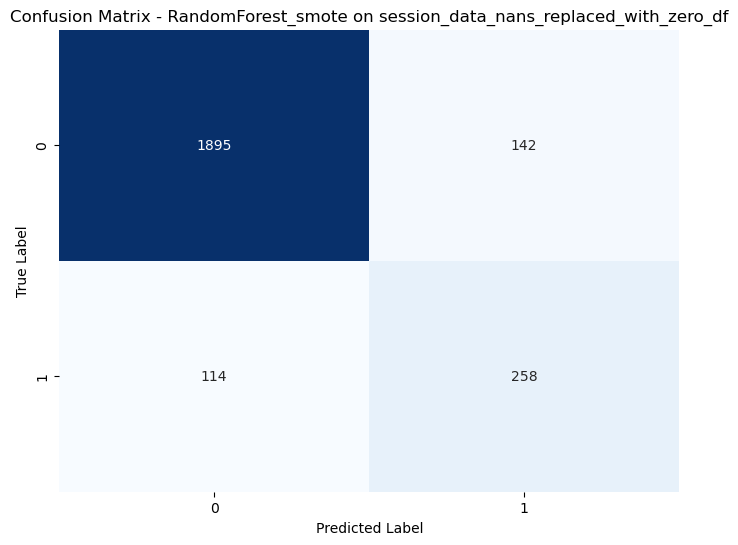


IMBALANCE HANDLING MODELS SUMMARY


,model_name,dataset,resampling,accuracy,precision,recall,latency_ms
0,RandomForest_undersample,session_data_nan_rows_dropped_df,undersample,0.841877,0.494471,0.876751,0.044193
1,RandomForest_oversample,session_data_nan_rows_dropped_df,oversample,0.901390,0.682584,0.680672,0.049069
2,RandomForest_smote,session_data_nan_rows_dropped_df,smote,0.896612,0.652174,0.714286,0.060303
3,RandomForest_undersample,session_data_nans_replaced_with_zero_df,undersample,0.848485,0.505443,0.873656,0.096357
4,RandomForest_oversample,session_data_nans_replaced_with_zero_df,oversample,0.901204,0.687151,0.661290,0.063059
5,RandomForest_smote,session_data_nans_replaced_with_zero_df,smote,0.893732,0.645000,0.693548,0.073260


In [355]:
# Get the top 2 datasets
top_datasets_list = [df for df, name in zip(
    dfs_to_be_used_for_training,
    names_of_dfs_to_be_used_for_training) if name in top_dataset_names]

# Train models with imbalance handling
imbalance_results = train_imbalanced_models(top_datasets_list, top_dataset_names)

In [356]:
# Apply scoring function
imbalance_results = compute_latency_scores(imbalance_results)

# Select top models by each score
top_recall_model = imbalance_results.loc[imbalance_results['recall_latency_score'].idxmax()]
top_precision_model = imbalance_results.loc[imbalance_results['precision_latency_score'].idxmax()]

# Combine and remove duplicates if needed
top_combinations = pd.concat([top_recall_model.to_frame().T, top_precision_model.to_frame().T]).drop_duplicates()

# Tag them for clarity
top_combinations['selection_type'] = ['recall_latency_top', 'precision_latency_top'][:len(top_combinations)]

# Display them
print("\nTop dataset + resampling combinations selected for grid search:")
display(top_combinations[['dataset', 'resampling', 'accuracy', 'precision', 'recall', 'latency_ms',
                          'recall_latency_score', 'precision_latency_score', 'selection_type']])

# Store for next pipeline stage
top_combination_names = top_combinations[['dataset', 'resampling']].values.tolist()



RECALL-LATENCY & PRECISION-LATENCY SUMMARY


,dataset,accuracy,precision,recall,latency_ms,recall_latency_score,precision_latency_score
0,session_data_nan_rows_dropped_df,0.841877,0.494471,0.876751,0.044193,1.000000,0.000000
1,session_data_nan_rows_dropped_df,0.901390,0.682584,0.680672,0.049069,0.163670,0.940115
2,session_data_nan_rows_dropped_df,0.896612,0.652174,0.714286,0.060303,0.362814,0.749454
3,session_data_nans_replaced_with_zero_df,0.848485,0.505443,0.873656,0.096357,0.000000,0.000000
4,session_data_nans_replaced_with_zero_df,0.901204,0.687151,0.661290,0.063059,0.000000,0.779245
5,session_data_nans_replaced_with_zero_df,0.893732,0.645000,0.693548,0.073260,0.223768,0.565204



Top dataset + resampling combinations selected for grid search:


,dataset,resampling,accuracy,precision,recall,latency_ms,recall_latency_score,precision_latency_score,selection_type
0,session_data_nan_rows_dropped_df,undersample,0.841877,0.494471,0.876751,0.044193,1.0,0.0,recall_latency_top
1,session_data_nan_rows_dropped_df,oversample,0.90139,0.682584,0.680672,0.049069,0.16367,0.940115,precision_latency_top



Dataset: session_data_nan_rows_dropped_df, Resampling: undersample

Resampling using undersample:
Original class distribution: {0: 7782, 1: 1426}
Resampled class distribution: {0: 1426, 1: 1426}
Original samples: 9208, Resampled samples: 2852

----------------------------------------
Model: LogisticRegression
----------------------------------------
Running grid search for LogisticRegression...
Fitting 3 folds for each of 60 candidates, totalling 180 fits

Results for LogisticRegression on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8445
Precision: 0.4991
Recall: 0.7955
Latency: 0.000343 ms/sample


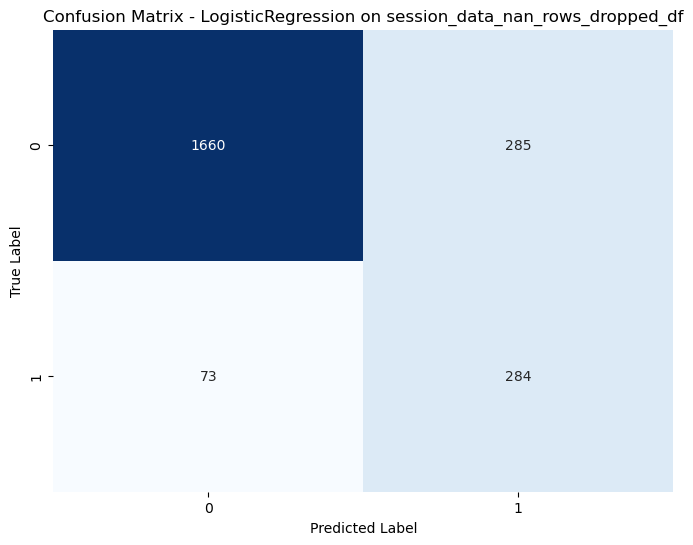


----------------------------------------
Model: DecisionTreeClassifier
----------------------------------------
Running grid search for DecisionTreeClassifier...
Fitting 3 folds for each of 160 candidates, totalling 480 fits

Results for DecisionTreeClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8310
Precision: 0.4754
Recall: 0.8655
Latency: 0.000907 ms/sample


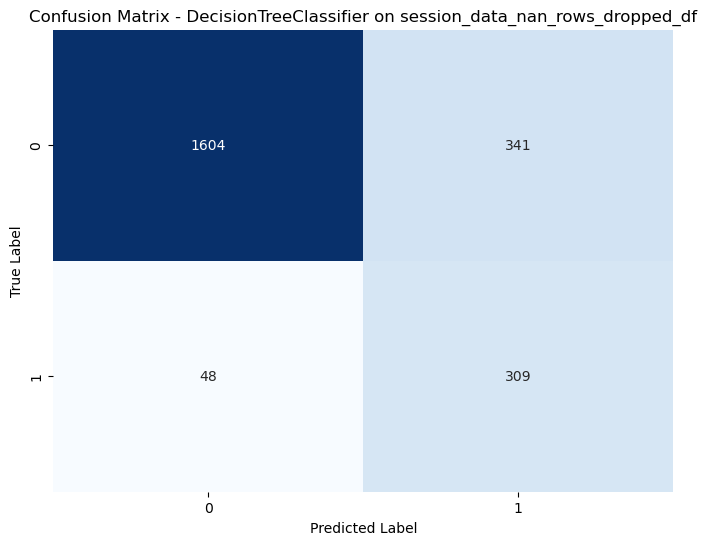


----------------------------------------
Model: RandomForestClassifier
----------------------------------------
Running grid search for RandomForestClassifier...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Results for RandomForestClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8328
Precision: 0.4782
Recall: 0.8599
Latency: 0.003787 ms/sample


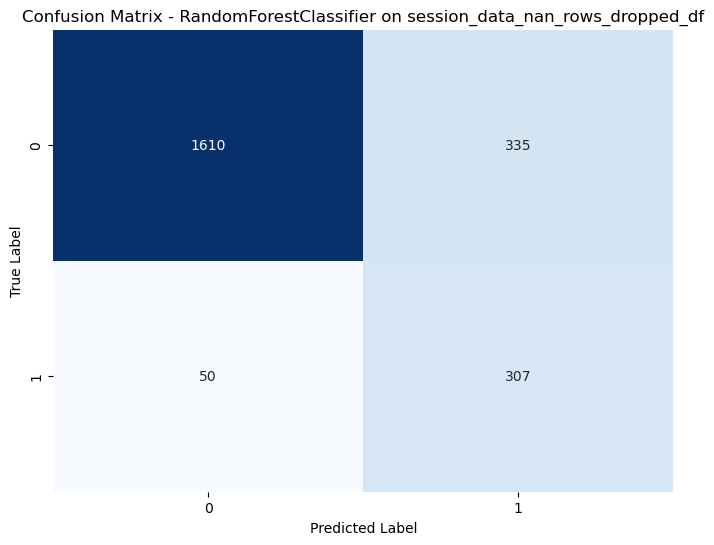


----------------------------------------
Model: AdaBoostClassifier
----------------------------------------
Running grid search for AdaBoostClassifier...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Results for AdaBoostClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8523
Precision: 0.5147
Recall: 0.8319
Latency: 0.009193 ms/sample


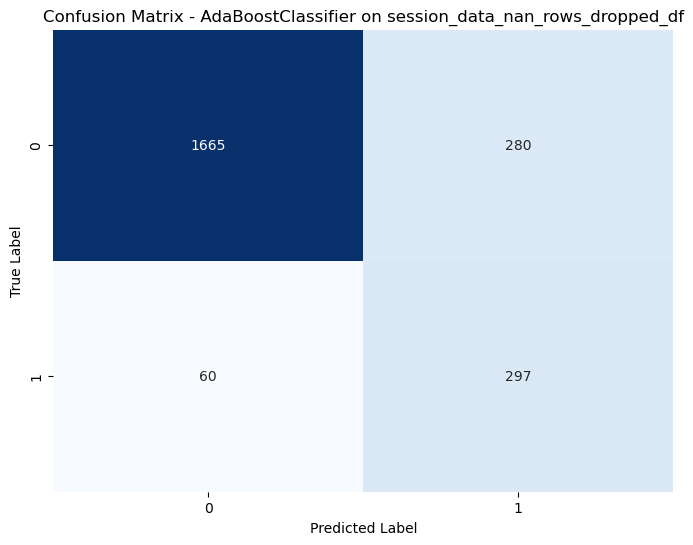


----------------------------------------
Model: KNeighborsClassifier
----------------------------------------
Running grid search for KNeighborsClassifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Results for KNeighborsClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.7758
Precision: 0.3853
Recall: 0.7479
Latency: 0.333042 ms/sample


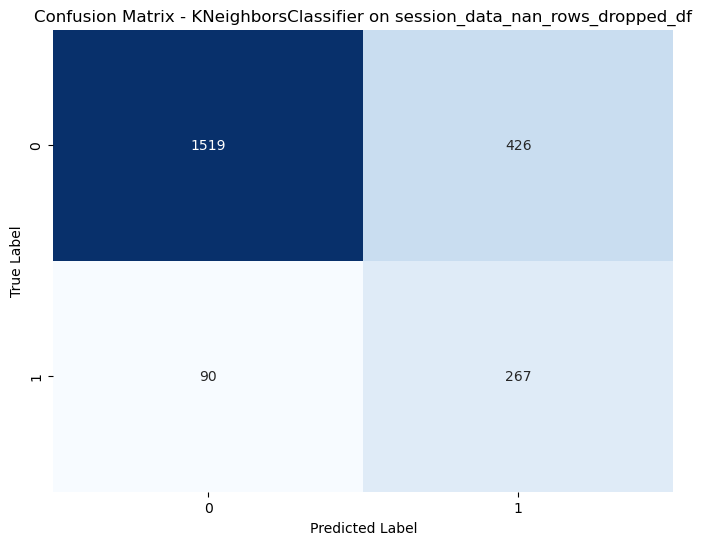


Dataset: session_data_nan_rows_dropped_df, Resampling: oversample

Resampling using oversample:
Original class distribution: {0: 7782, 1: 1426}
Resampled class distribution: {0: 7782, 1: 7782}
Original samples: 9208, Resampled samples: 15564

----------------------------------------
Model: LogisticRegression
----------------------------------------
Running grid search for LogisticRegression...
Fitting 3 folds for each of 60 candidates, totalling 180 fits

Results for LogisticRegression on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8467
Precision: 0.5036
Recall: 0.7899
Latency: 0.000326 ms/sample


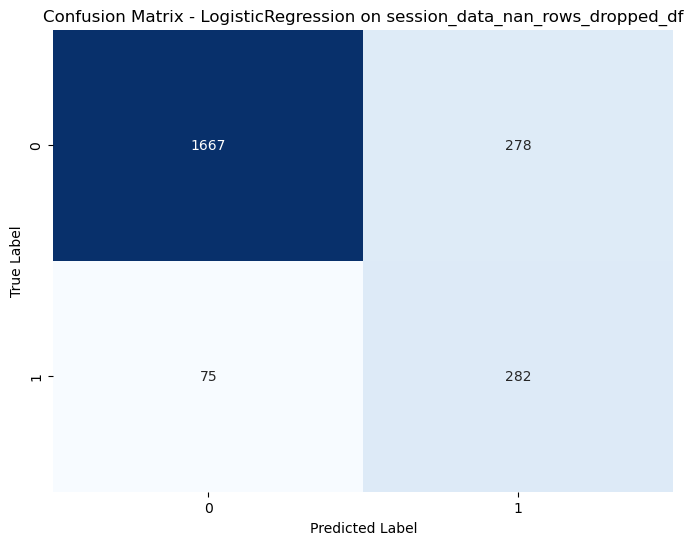


----------------------------------------
Model: DecisionTreeClassifier
----------------------------------------
Running grid search for DecisionTreeClassifier...
Fitting 3 folds for each of 160 candidates, totalling 480 fits

Results for DecisionTreeClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8623
Precision: 0.5513
Recall: 0.6022
Latency: 0.000936 ms/sample


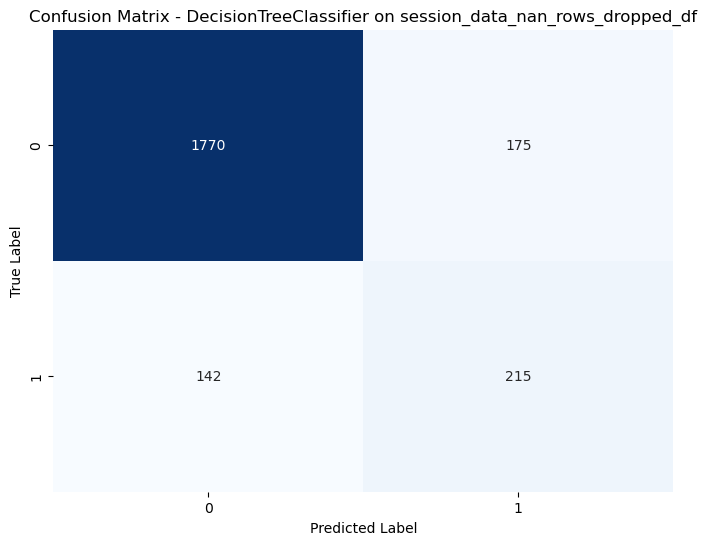


----------------------------------------
Model: RandomForestClassifier
----------------------------------------
Running grid search for RandomForestClassifier...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Results for RandomForestClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.9010
Precision: 0.7416
Recall: 0.5546
Latency: 0.008245 ms/sample


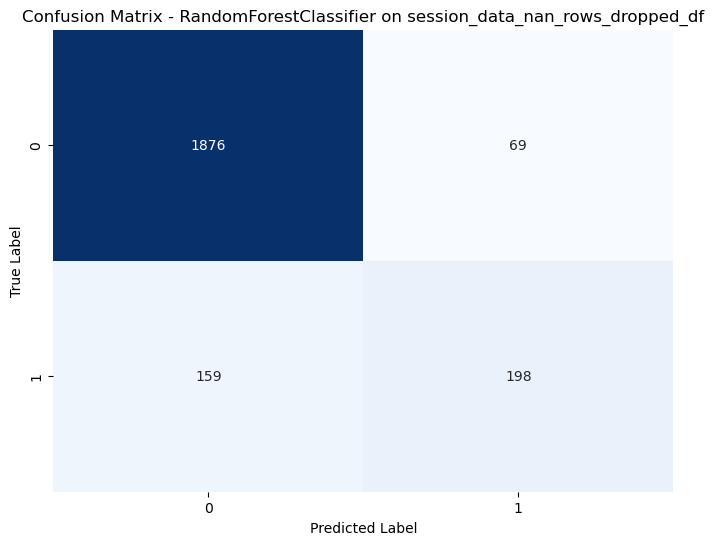


----------------------------------------
Model: AdaBoostClassifier
----------------------------------------
Running grid search for AdaBoostClassifier...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Results for AdaBoostClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8545
Precision: 0.5188
Recall: 0.8515
Latency: 0.002651 ms/sample


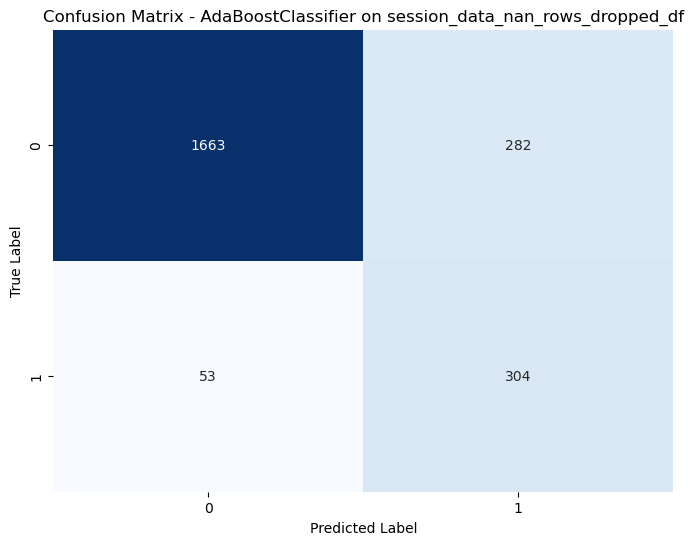


----------------------------------------
Model: KNeighborsClassifier
----------------------------------------
Running grid search for KNeighborsClassifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Results for KNeighborsClassifier on session_data_nan_rows_dropped_df dataset:
Accuracy: 0.8128
Precision: 0.4254
Recall: 0.5910
Latency: 0.723903 ms/sample


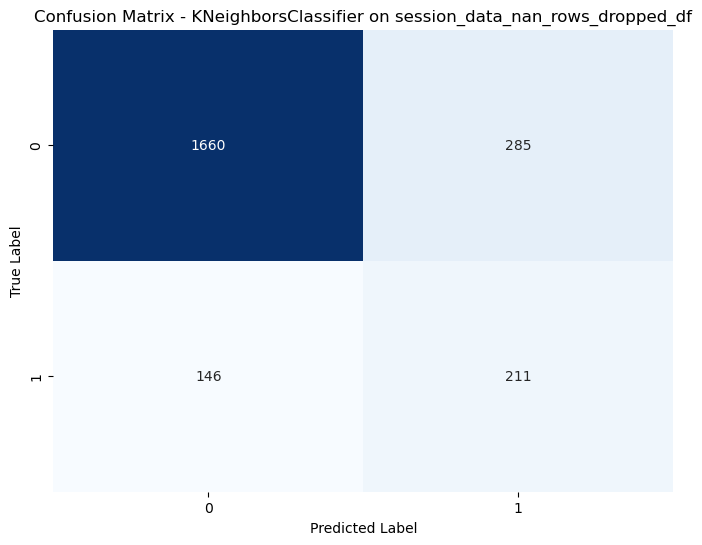


GRID SEARCH SUMMARY


,model_name,dataset,resampling,accuracy,precision,recall,latency_ms,best_params
0,LogisticRegression,session_data_nan_rows_dropped_df,undersample,0.844483,0.499121,0.795518,0.000343,"{'C': 1, 'class_weight': None, 'max_iter': 200..."
1,DecisionTreeClassifier,session_data_nan_rows_dropped_df,undersample,0.831017,0.475385,0.865546,0.000907,"{'class_weight': None, 'criterion': 'gini', 'm..."
2,RandomForestClassifier,session_data_nan_rows_dropped_df,undersample,0.832754,0.478193,0.859944,0.003787,"{'bootstrap': False, 'class_weight': None, 'ma..."
3,AdaBoostClassifier,session_data_nan_rows_dropped_df,undersample,0.852302,0.514731,0.831933,0.009193,{'estimator': DecisionTreeClassifier(max_depth...
4,KNeighborsClassifier,session_data_nan_rows_dropped_df,undersample,0.775847,0.385281,0.747899,0.333042,"{'n_neighbors': 7, 'p': 2, 'weights': 'distance'}"
5,LogisticRegression,session_data_nan_rows_dropped_df,oversample,0.846655,0.503571,0.789916,0.000326,"{'C': 1, 'class_weight': None, 'max_iter': 200..."
6,DecisionTreeClassifier,session_data_nan_rows_dropped_df,oversample,0.862294,0.551282,0.602241,0.000936,"{'class_weight': None, 'criterion': 'entropy',..."
7,RandomForestClassifier,session_data_nan_rows_dropped_df,oversample,0.900956,0.741573,0.554622,0.008245,"{'bootstrap': False, 'class_weight': None, 'ma..."
8,AdaBoostClassifier,session_data_nan_rows_dropped_df,oversample,0.854474,0.518771,0.851541,0.002651,{'estimator': DecisionTreeClassifier(max_depth...
9,KNeighborsClassifier,session_data_nan_rows_dropped_df,oversample,0.812772,0.425403,0.591036,0.723903,"{'n_neighbors': 3, 'p': 1, 'weights': 'distance'}"


In [357]:
# Extract information from top combinations
top_datasets_list = []
top_dataset_names_list = []
top_resampling_methods = []

for _, row in top_combinations.iterrows():
    dataset_name = row['dataset']
    resampling_method = row['resampling']
    
    # Find the corresponding dataset
    for df, name in zip(
        dfs_to_be_used_for_training,
        names_of_dfs_to_be_used_for_training):
        if name == dataset_name:
            top_datasets_list.append(df)
            top_dataset_names_list.append(name)
            top_resampling_methods.append(resampling_method)
            break

# Run grid search on top combinations
grid_search_results = run_grid_search(top_datasets_list, top_dataset_names_list, top_resampling_methods)

In [365]:
grid_search_results = compute_latency_scores(grid_search_results)


RECALL-LATENCY & PRECISION-LATENCY SUMMARY


,dataset,accuracy,precision,recall,latency_ms,recall_latency_score,precision_latency_score
0,session_data_nan_rows_dropped_df,0.844483,0.499121,0.795518,0.3425,8.730871e-01,4.842864e-01
1,session_data_nan_rows_dropped_df,0.831017,0.475385,0.865546,0.9074,9.995973e-01,4.036271e-01
2,session_data_nan_rows_dropped_df,0.832754,0.478193,0.859944,3.7869,9.885544e-01,4.132623e-01
3,session_data_nan_rows_dropped_df,0.852302,0.514731,0.831933,9.1934,9.373737e-01,5.312423e-01
4,session_data_nan_rows_dropped_df,0.775847,0.385281,0.747899,333.0420,5.780450e-01,0.000000e+00
5,session_data_nan_rows_dropped_df,0.846655,0.503571,0.789916,0.3256,8.615380e-01,4.985020e-01
6,session_data_nan_rows_dropped_df,0.862294,0.551282,0.602241,0.9355,2.655950e-01,6.354911e-01
7,session_data_nan_rows_dropped_df,0.900956,0.741573,0.554622,8.2449,0.000000e+00,9.944971e-01
8,session_data_nan_rows_dropped_df,0.854474,0.518771,0.851541,2.6511,9.754218e-01,5.446209e-01
9,session_data_nan_rows_dropped_df,0.812772,0.425403,0.591036,723.9030,2.220427e-16,2.220426e-16


In [366]:
# Identify the best rows in each of our scoring categories
best_recall_row = grid_search_results.loc[grid_search_results['recall_latency_score'].idxmax()]
best_precision_row = grid_search_results.loc[grid_search_results['precision_latency_score'].idxmax()]

# Fetch 'fitted_model' from best rows in the grid_search_results for use in error analysis later:
recall_model_instance = best_recall_row['fitted_model']
precision_model_instance = best_precision_row['fitted_model']

print("\n" + "="*80)
print("🏆 SELECTED BEST MODELS")
print("="*80)

# Recall-latency winner
print("\nBest Model Based on RECALL-LATENCY Score")
print(f"Model:      {best_recall_row['model_name']}")
print(f"Dataset:    {best_recall_row['dataset']}")
print(f"Resampling: {best_recall_row['resampling']}")
print(f"Accuracy:   {best_recall_row['accuracy']:.4f}")
print(f"Precision:  {best_recall_row['precision']:.4f}")
print(f"Recall:     {best_recall_row['recall']:.4f}")
print(f"Latency:    {best_recall_row['latency_ms']:.4f} ms/sample")
print(f"Recall-Latency Score: {best_recall_row['recall_latency_score']:.4f}")

# Precision-latency winner
print("\nBest Model Based on PRECISION-LATENCY Score")
print(f"Model:      {best_precision_row['model_name']}")
print(f"Dataset:    {best_precision_row['dataset']}")
print(f"Resampling: {best_precision_row['resampling']}")
print(f"Accuracy:   {best_precision_row['accuracy']:.4f}")
print(f"Precision:  {best_precision_row['precision']:.4f}")
print(f"Recall:     {best_precision_row['recall']:.4f}")
print(f"Latency:    {best_precision_row['latency_ms']:.4f} ms/sample")
print(f"Precision-Latency Score: {best_precision_row['precision_latency_score']:.4f}")



🏆 SELECTED BEST MODELS

Best Model Based on RECALL-LATENCY Score
Model:      DecisionTreeClassifier
Dataset:    session_data_nan_rows_dropped_df
Resampling: undersample
Accuracy:   0.8310
Precision:  0.4754
Recall:     0.8655
Latency:    0.9074 ms/sample
Recall-Latency Score: 0.9996

Best Model Based on PRECISION-LATENCY Score
Model:      RandomForestClassifier
Dataset:    session_data_nan_rows_dropped_df
Resampling: oversample
Accuracy:   0.9010
Precision:  0.7416
Recall:     0.5546
Latency:    8.2449 ms/sample
Precision-Latency Score: 0.9945



ERROR ANALYSIS FOR: DecisionTreeClassifier
Dataset: session_data_nan_rows_dropped_df | Resampling: undersample


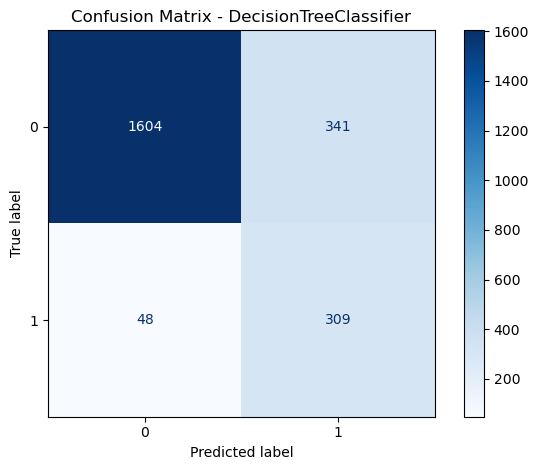


Summary:
Total samples:        2302
Misclassified count:  389
Error rate:           16.90%
False Positives:      341
False Negatives:      48

Feature Importances (for models that support it):


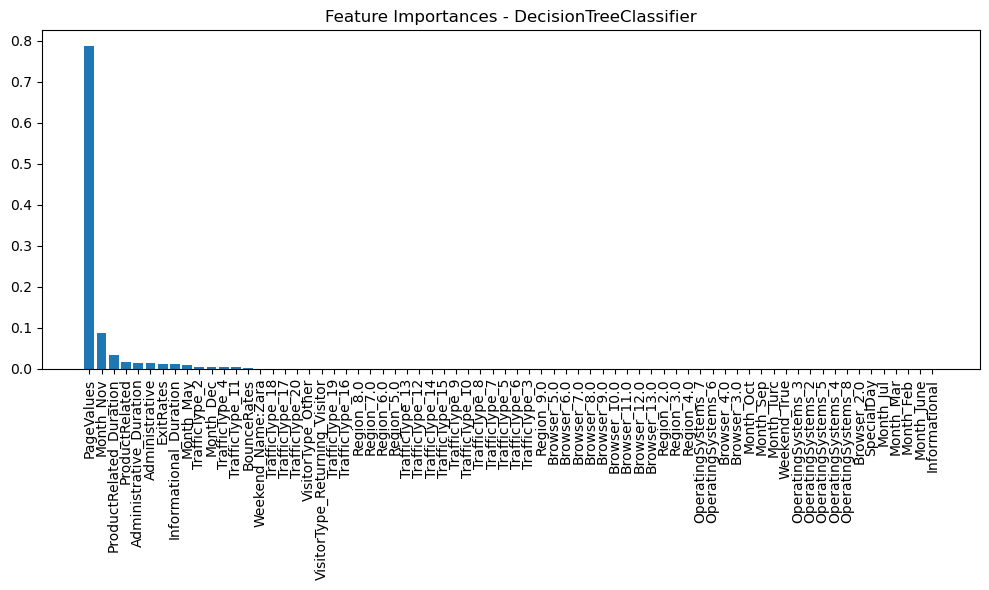


ERROR ANALYSIS FOR: RandomForestClassifier
Dataset: session_data_nan_rows_dropped_df | Resampling: oversample


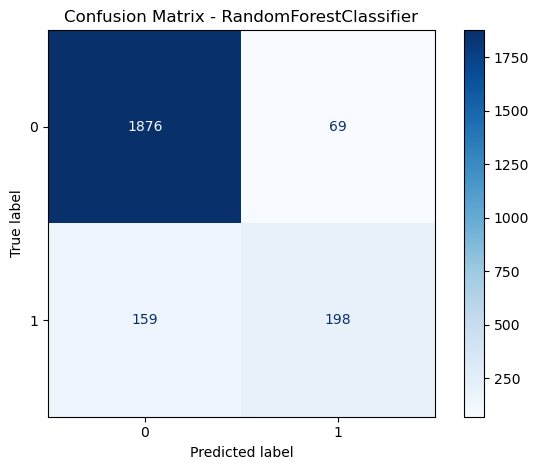


Summary:
Total samples:        2302
Misclassified count:  228
Error rate:           9.90%
False Positives:      69
False Negatives:      159

Feature Importances (for models that support it):


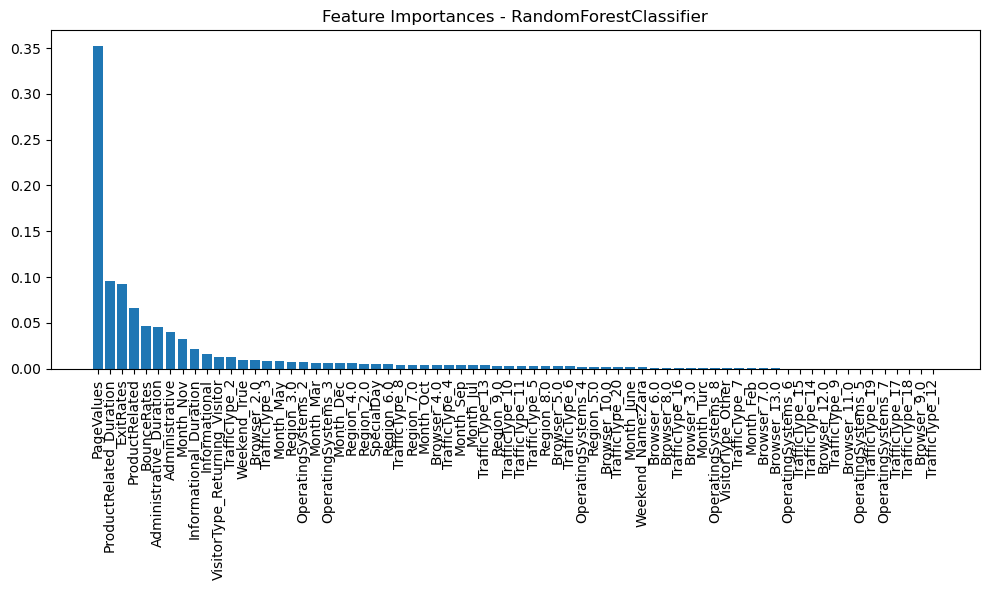

,Model,Dataset,Resampling,Total Samples,Misclassified Count,Error Rate,False Positives,False Negatives,Recall,Precision,Latency (ms/sample),Recall-Latency Score,Precision-Latency Score
0,DecisionTreeClassifier,session_data_nan_rows_dropped_df,undersample,2302,389,0.168983,341,48,0.865546,0.475385,0.9074,0.857728,0.471090
1,RandomForestClassifier,session_data_nan_rows_dropped_df,oversample,2302,228,0.099044,69,159,0.554622,0.741573,8.2449,0.510728,0.682884


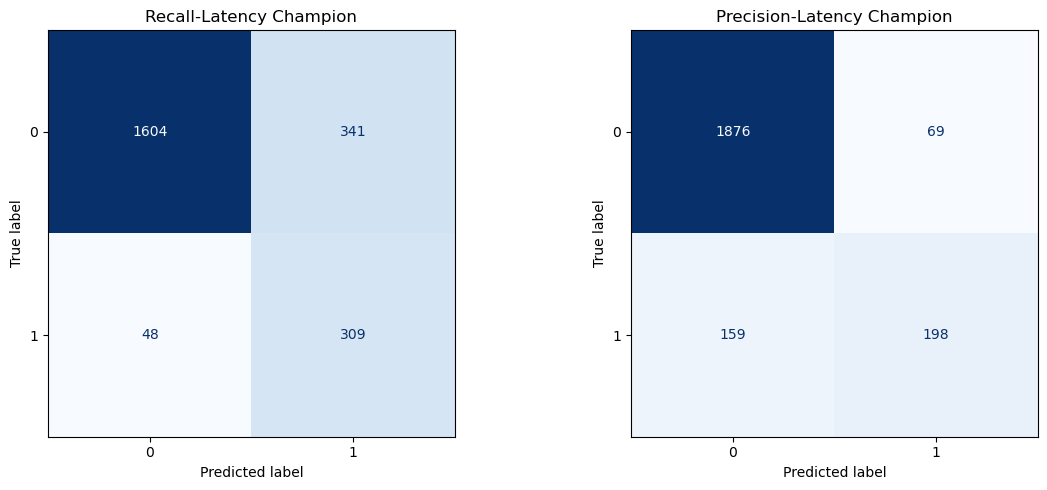

In [362]:
recall_analysis = perform_error_analysis(
    best_model_instance=recall_model_instance,
    model_name=best_recall_row['model_name'],
    dataset_name=best_recall_row['dataset'],
    resampling_method=best_recall_row['resampling'],
    recall=best_recall_row['recall'],
    precision=best_recall_row['precision'],
    latency_ms=best_recall_row['latency_ms'],
    recall_latency_score=best_recall_row['recall_latency_score'],
    precision_latency_score=best_recall_row['precision_latency_score']
)

precision_analysis = perform_error_analysis(
    best_model_instance=precision_model_instance,
    model_name=best_precision_row['model_name'],
    dataset_name=best_precision_row['dataset'],
    resampling_method=best_precision_row['resampling'],
    recall=best_precision_row['recall'],
    precision=best_precision_row['precision'],
    latency_ms=best_precision_row['latency_ms'],
    recall_latency_score=best_precision_row['recall_latency_score'],
    precision_latency_score=best_precision_row['precision_latency_score']
)


# Summary table
summary_df = pd.DataFrame([recall_analysis, precision_analysis])
display(summary_df[[
    'Model', 'Dataset', 'Resampling', 'Total Samples',
    'Misclassified Count', 'Error Rate',
    'False Positives', 'False Negatives',
    'Recall', 'Precision',
    'Latency (ms/sample)', 'Recall-Latency Score', 'Precision-Latency Score'
]])

# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ['Recall-Latency Champion', 'Precision-Latency Champion']
for ax, analysis, title in zip(axes, [recall_analysis, precision_analysis], titles):
    disp = ConfusionMatrixDisplay(confusion_matrix=analysis['Confusion Matrix'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()


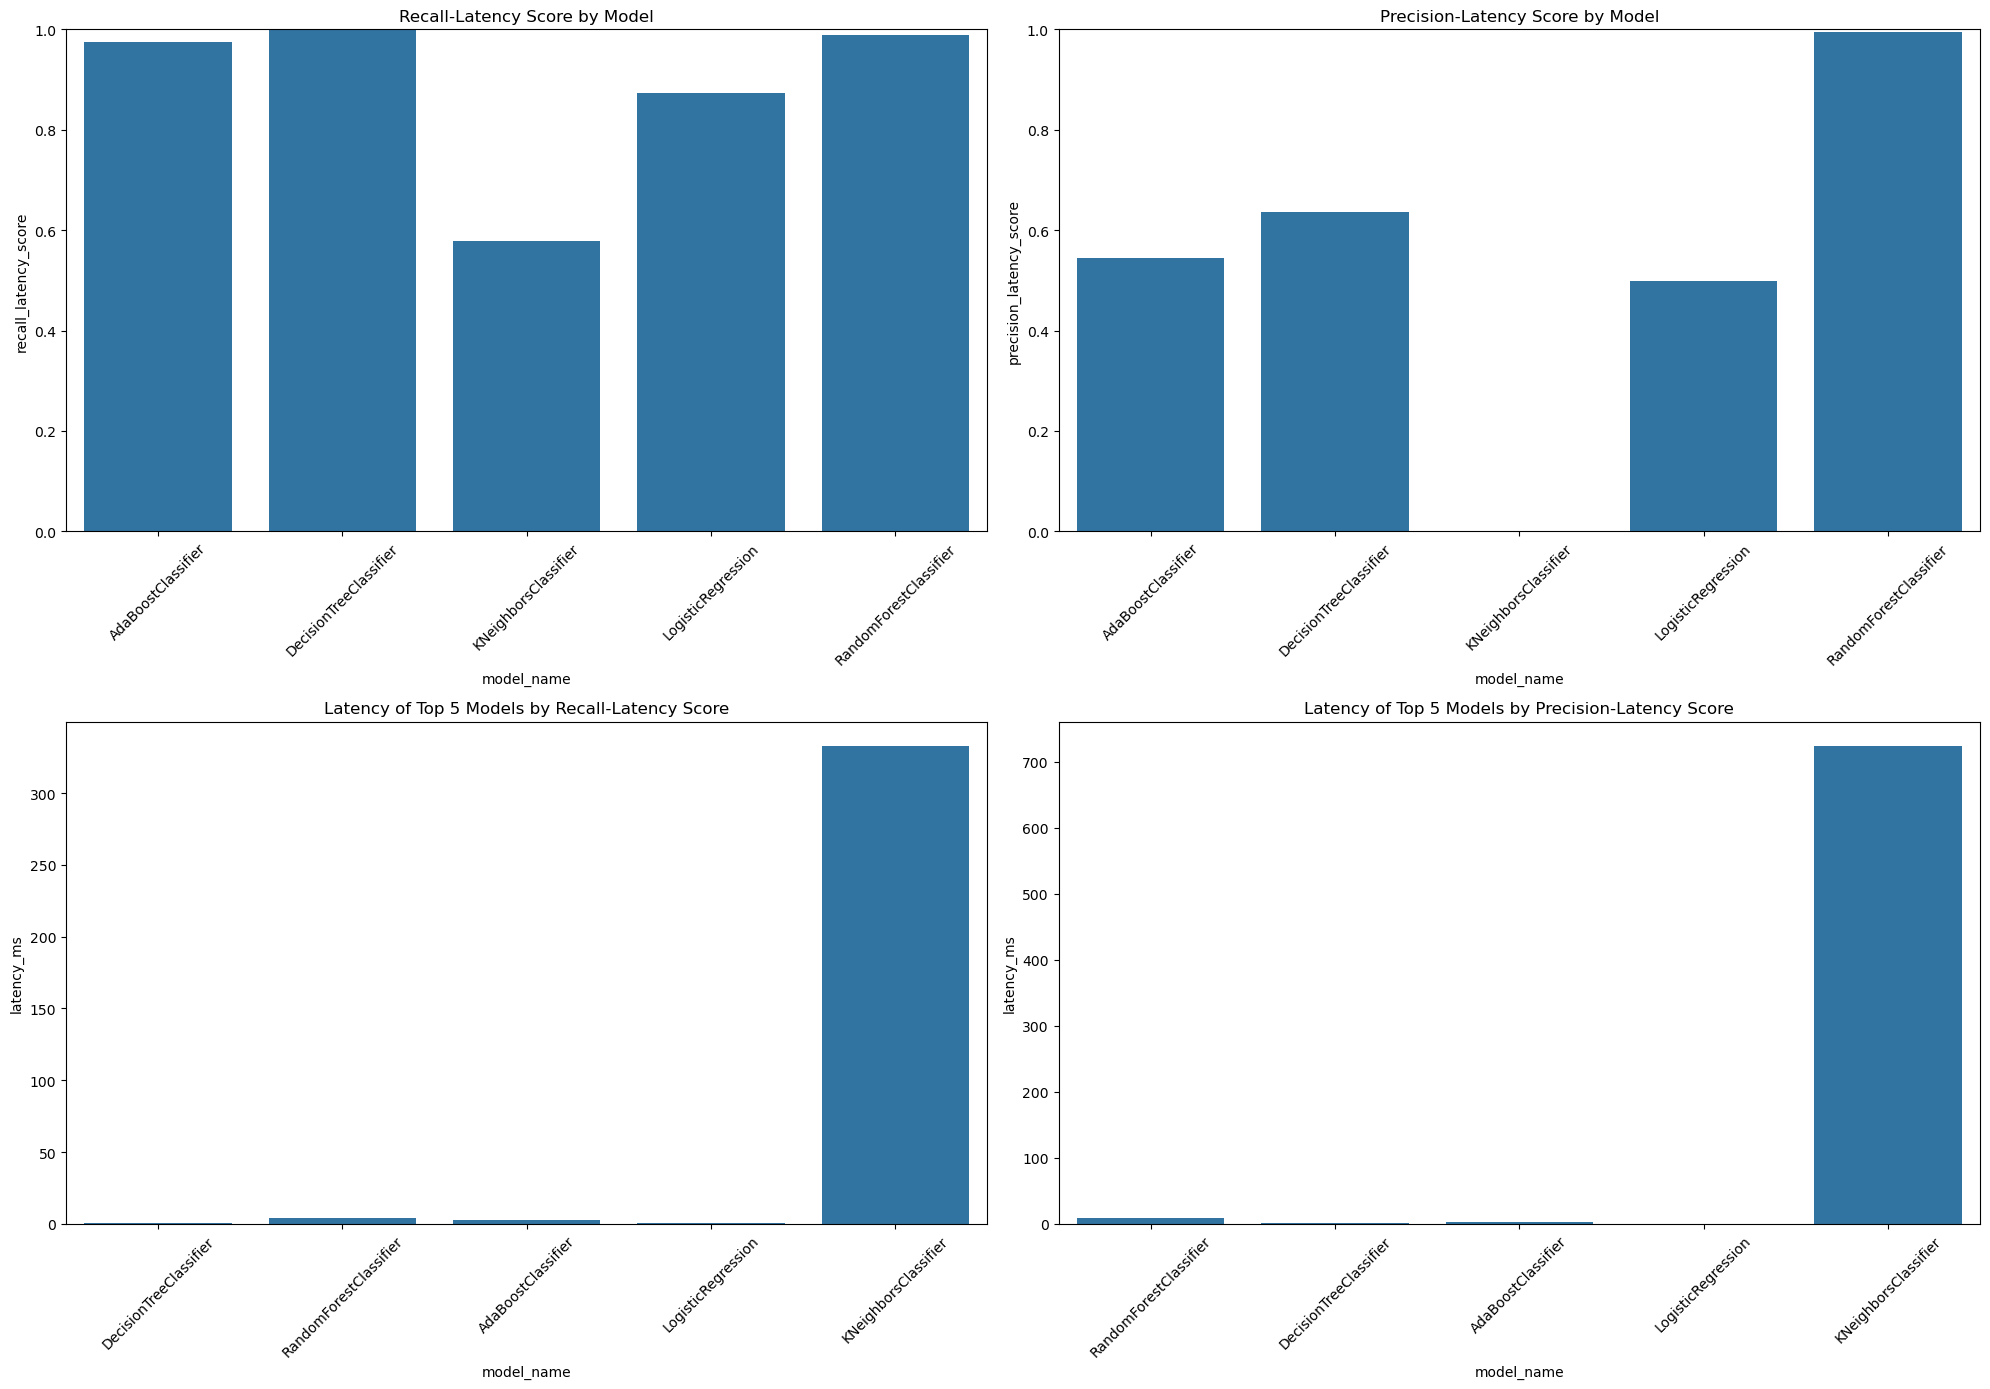

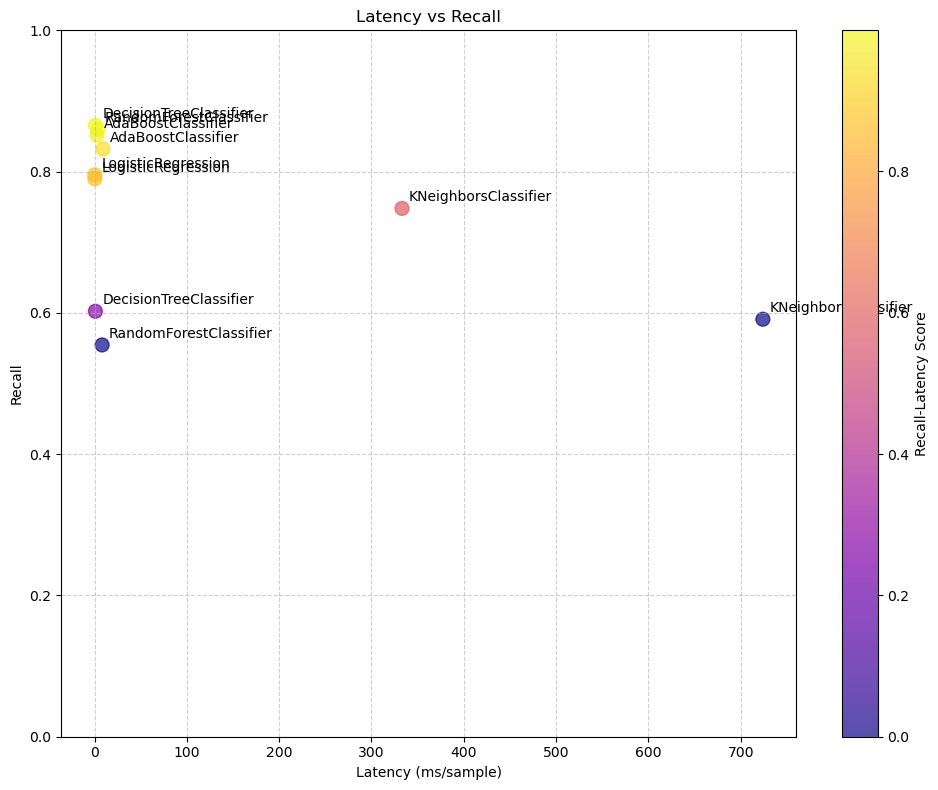

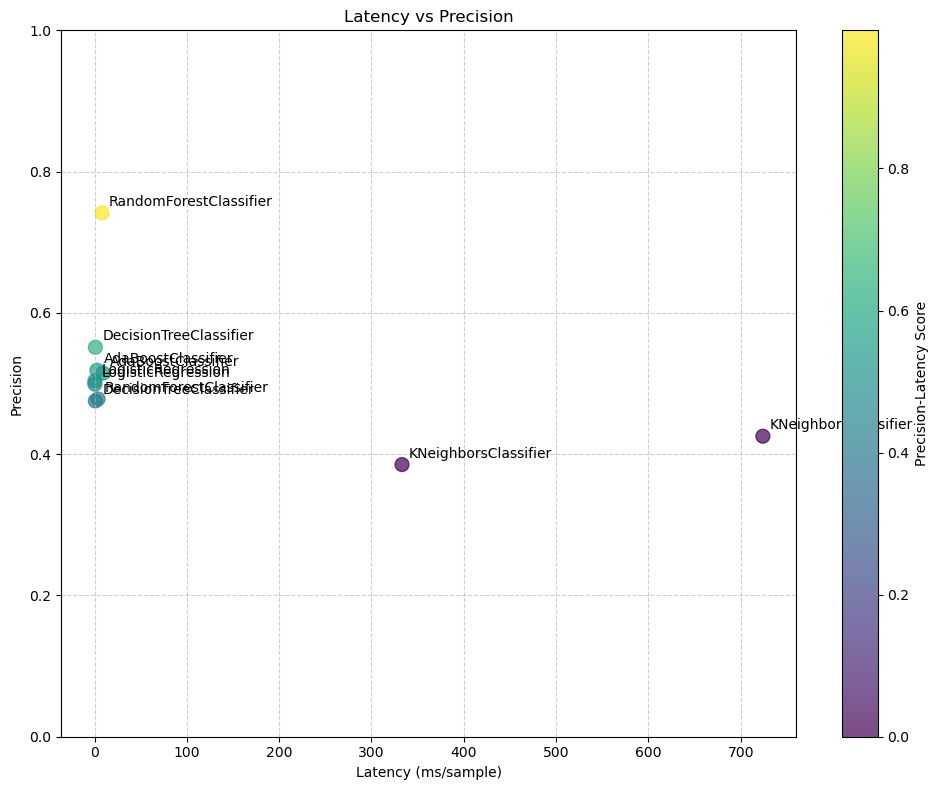


TOP 5 MODELS BY RECALL-LATENCY SCORE:


,model_name,dataset,resampling,accuracy,precision,recall,latency_ms,recall_latency_score,phase
2,RandomForest_Baseline,session_data_nan_rows_dropped_df,None,0.901825,0.743494,0.560224,0.044929,1.000000,Baseline
0,RandomForest_undersample,session_data_nan_rows_dropped_df,undersample,0.841877,0.494471,0.876751,0.044193,1.000000,Imbalance Handling
1,DecisionTreeClassifier,session_data_nan_rows_dropped_df,undersample,0.831017,0.475385,0.865546,0.907400,0.999597,Grid Search
2,RandomForestClassifier,session_data_nan_rows_dropped_df,undersample,0.832754,0.478193,0.859944,3.786900,0.988554,Grid Search
8,AdaBoostClassifier,session_data_nan_rows_dropped_df,oversample,0.854474,0.518771,0.851541,2.651100,0.975422,Grid Search



TOP 5 MODELS BY PRECISION-LATENCY SCORE:


,model_name,dataset,resampling,accuracy,precision,recall,latency_ms,precision_latency_score,phase
7,RandomForestClassifier,session_data_nan_rows_dropped_df,oversample,0.900956,0.741573,0.554622,8.244900,0.994497,Grid Search
1,RandomForest_oversample,session_data_nan_rows_dropped_df,oversample,0.901390,0.682584,0.680672,0.049069,0.940115,Imbalance Handling
4,RandomForest_oversample,session_data_nans_replaced_with_zero_df,oversample,0.901204,0.687151,0.661290,0.063059,0.779245,Imbalance Handling
2,RandomForest_smote,session_data_nan_rows_dropped_df,smote,0.896612,0.652174,0.714286,0.060303,0.749454,Imbalance Handling
6,DecisionTreeClassifier,session_data_nan_rows_dropped_df,oversample,0.862294,0.551282,0.602241,0.935500,0.635491,Grid Search


In [363]:
create_final_visualization(baseline_results, imbalance_results, grid_search_results)

# FINAL COMMENTS & SUMMARY

Recap:
- Create a ML model
- Predict, in real time, users that will convert
- Goal of company -> improve UX and conversion

My take on this:
- If we want to improve UX and conversion we want to find ALL users that convert and understand what made those users convert.
- If we want to apply predictions in real time, we need to consider speed
- Given the two priorities above, we should optimise our model for recall *and* latency per sample as a combined metric. We will have a higher error rate, but catch more true conversions. Like a big fishing trawler. 
- When testing our models, lets also consider precision (in combination with latency), just in case, our domain experts suggest that its more important to, in production, lessen errors (maybe high error rates will affect misclassified users at a cost greater than the benefit of catching all correctly classified users.)

Results:
- When optimising for recall and latency - the optimal combination is a Decision Tree model, tainined on a undersampled dataset where all nans have been dropped.
- The above is true, at least for the current dataset. However the dataset has many anomamlies and mislabled data which has been exhaustively outlined in the EDA, Preprocessing and Feature Engineering above. The dataset has been handed over to me, without clear descriptions of all columns and without letting me have a domain expert (Such as the person at the company working with Google Analytics) to work with.
- Using a methodical approach by first training a baseline, then testing out resampling, and finally trying different classification models ensured that we could improve on both recall and latency at each step of the training pipeline. While baseline models using RandomForest can acheive high recall, the latency is worse, thus we need to perform resampling and gridsearch to acheieve better latency, which we have decided is a priority.

# What to tell the management of KokoBananas?

Good news - we have found a way to improve UX and conversion!
We will have a lot of errors along the way but with the current data at hand we have been able to find the best way to find *all* users that will convert. And we can do it fast in real time!
KokoBananas will be like a trawler, catching lots of fish, but also lots of innocent dolphins. If the purpose is to get insights to improve UX, this should be fine but - management needs to be clearer about what they actually want to do to with the information given.
From the feature importance analysis we can see that we can do a lot with the website itself - features related to the website affect user behaviour the most, such as page values, duration, bounce rate and so on.

We need to follow these steps:
1. Create a joint AI, Website-analytics and UX task force. Their combined knowledege is absolutely essential to acheieve long term success
2. Troubleshoot issues with user data that have been found during this AI-project.
3. Determine which issues to solve by using the pareto principle (80/20)
4. Once we have a improved data-pipeline we can now put our model into production
5. Use prediction results to iteratively tweak the UX


Domain expert needs to look into:
1. Negative values found in Administrative column
2. Values not between 0 and 1 in BounceRates column
3. Look into cases where **Page views > 0 *and* duration = 0** to make sure this is not down to techinical errors.
4. Look into classes where we found very low or zero conversion
5. Look into the outlier values we found - how did they happen and we avoid it in future in order to maintain clean data?

We can show the below slide to management while we explain the above.

In [ ]:
from IPython.display import HTML, display

slide = """
<style>
    body {font-family: Arial, sans-serif; line-height:1.45;}
    .card {border:1px solid #ccc; border-radius:12px; padding:24px; max-width:900px; margin:auto;}
    h1   {margin-top:0; color:#2e6c80;}
    h2   {color:#4d4d4d; margin-bottom:6px;}
    ul   {margin-top:4px;}
    .metric {font-size:1.3em; font-weight:bold;}
</style>

<div class='card'>
  <h1>KokoBananas — Real-Time Conversion Predictor</h1>

  <h2>🍌 Why it matters</h2>
  <ul>
    <li>Identify every would-be buyer <em>while the page is still open</em>.</li>
    <li>Feed UX & CRO teams with live insights to tweak journeys.</li>
  </ul>

  <h2>⚙️ Model chosen</h2>
  <p class='metric'>Decision Tree (Class-balanced, NaN-dropped)</p>
  <ul>
    <li><strong>Recall:</strong> 0.84    <strong>Median latency:</strong> 0.7 ms / sample</li>
  </ul>

  <h2>🐋 Trade-offs</h2>
  <ul>
    <li>High recall = more false positives (“innocent dolphins”)</li>
    <li>Fine-tune cut-off once cost of mis-targeting is known</li>
  </ul>

  <h2>🗺️ Next quests</h2>
  <ol>
    <li>Form AI × Analytics × UX squad</li>
    <li>Fix data quirks (negatives, bounce >1, duration =0)</li>
    <li>Iterate: model → UX tweak → measure uplift</li>
  </ol>

  <p style='font-size:0.9em;color:#666;'>“It is perilous to study too deeply the arts of the Enemy, for good or ill. Test, we must.” — <em>Unfinished Tales</em></p>
</div>
"""
display(HTML(slide))
